# Misc

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import subprocess
from prettytable import PrettyTable
from collections import Counter

notebook_dir = os.getcwd()  # Gets test folder path
project_dir = os.path.dirname(notebook_dir)
os.chdir(project_dir)
os.getcwd()

'd:\\Jacky\\MATLAB\\Battery_ROI'

In [3]:
def obj_proc(obj_df, position_df, df=True, types=1):
    obj = obj_df.to_numpy()
    position = position_df.to_numpy()
    if obj[0,0] < 0:
        obj[:,0] = -obj[:,0] 
    
    # Create mask for filtering
    mask = obj[:,0] != 0
    # print(position[1])

    # Apply same filter to both arrays
    obj = obj[mask]
    position = position[mask]
    # print(position[1])
    
    # Create DataFrame with filtered data
    if df:
        obj_df = pd.DataFrame(obj, columns=['TNB revenue from CES (RM)', 'Aging Cost', 'Average Cost of Prosumer (RM)'])
        if types == 1:
            cols = ['Charge Cost ($/kWh)', 'Discharge Price ($/kWh)', 'P2P Charge Cost Change', 'P2P Discharge Cost Change', 'Close Charge Cost Change', 'Close Discharge Cost Change']
        else:
            desired_caps = 32
            cols = ['Subscription Price (RM)'] + [f'Capacity {i+1} (kWh)' for i in range(desired_caps)]
        position_df = pd.DataFrame(position, columns=cols)
        return obj_df, position_df
    else:
        return obj, position

# Usage basis unlimited

In [ ]:
result_loc = "momsa_full_log (usage unrank unlimit) 1"
non_dom_result_loc = "MOMSA unrank unlimit 1"

position_df = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="all_X", header=None)
position_df_non_dom = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{non_dom_result_loc}.xlsx", sheet_name="Sheet1", header=None)

## (-TNB_revenue_CESs, EFCs, costP)
obj_df = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="all_F", header=None)   
obj_df_non_dom = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{non_dom_result_loc}.xlsx", sheet_name="Sheet2", header=None)

In [5]:
obj, position = obj_proc(obj_df, position_df)
obj_non_dom, position_non_dom = obj_proc(obj_df_non_dom, position_df_non_dom)

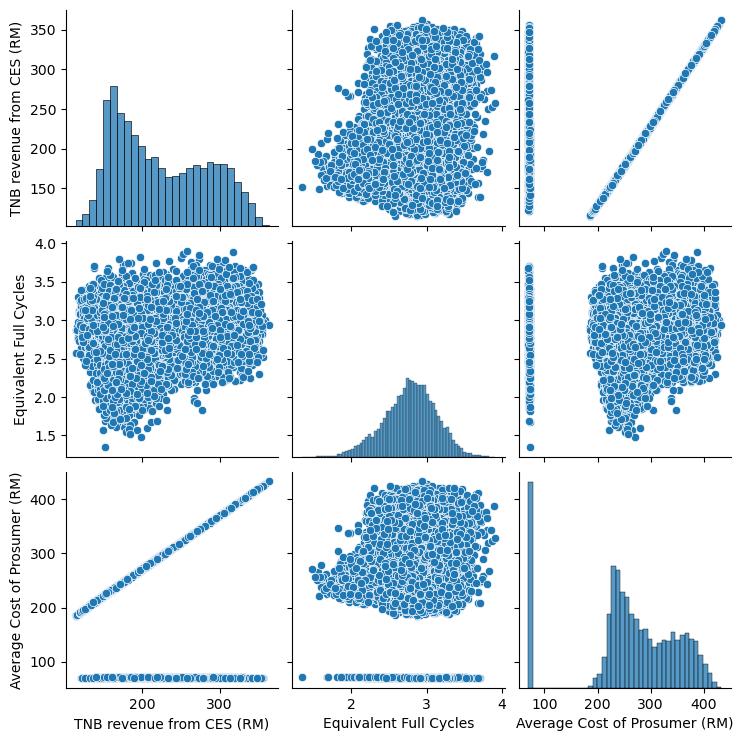

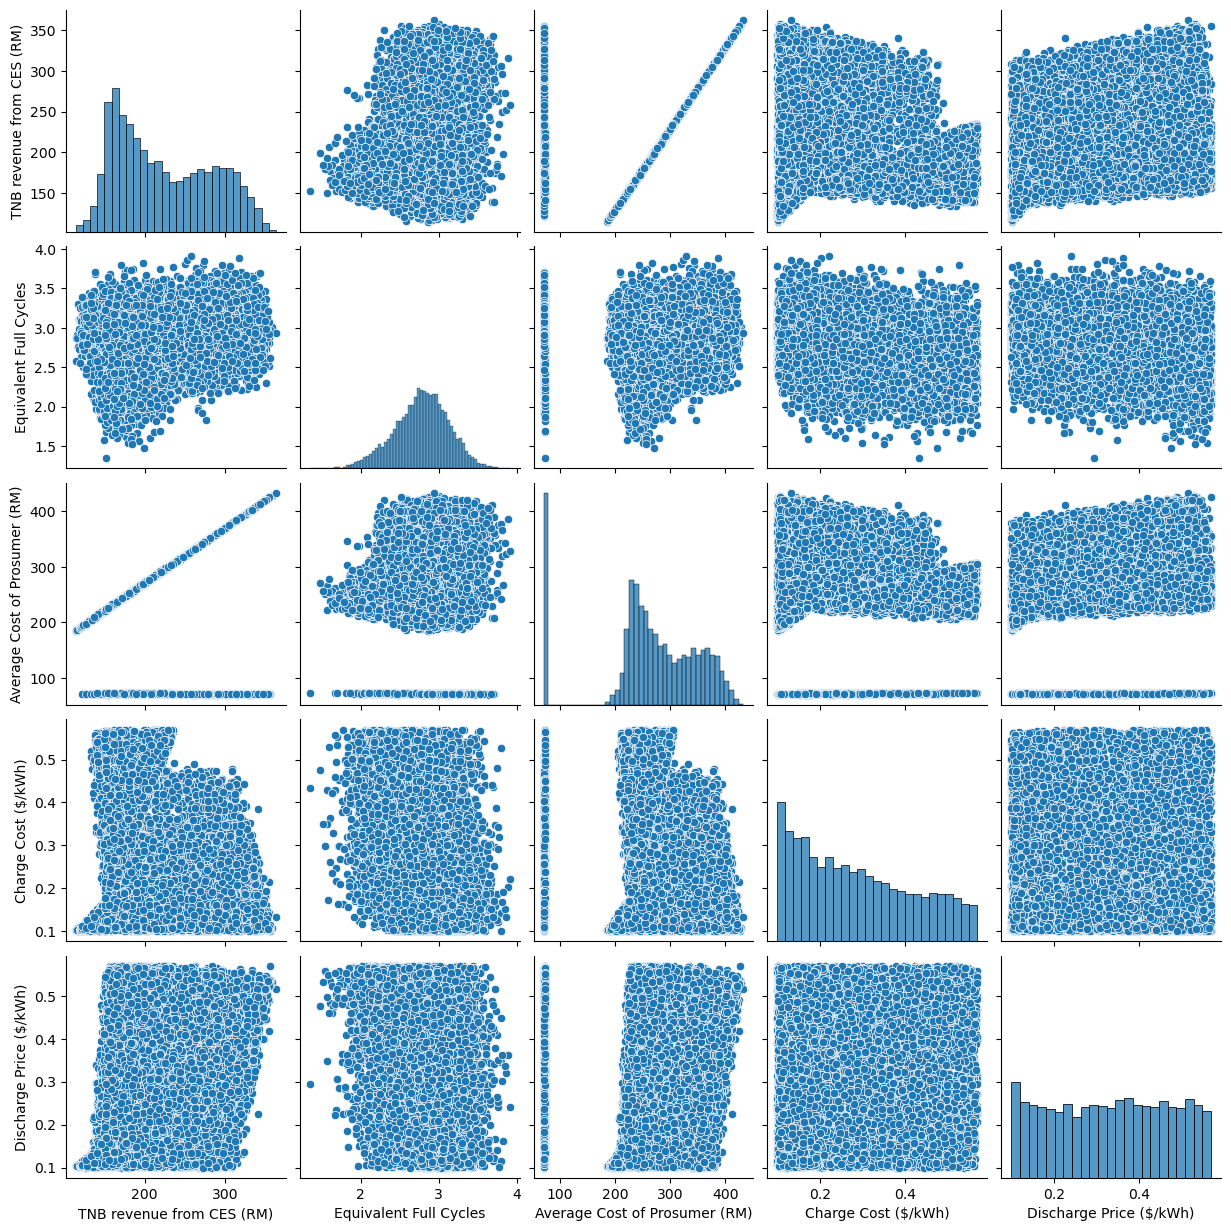

In [6]:
import seaborn as sns

sns.pairplot(obj)
# sns.pairplot(obj_non_dom)
combined_df = pd.concat([obj, position], axis=1)
sns.pairplot(combined_df)


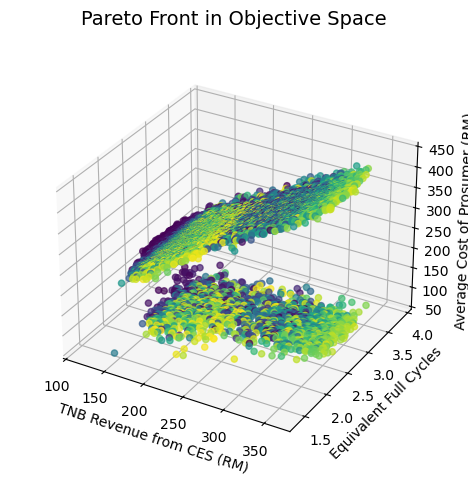

In [ ]:
obj_array, position_array = obj_proc(obj_df, position_df, df=False)

from mpl_toolkits.mplot3d import Axes3D
fontttt = 10
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(obj_array, obj_array[:,1], obj_array[:,2], c=position_array[:,1], cmap='viridis', alpha=0.7)
ax.set_xlabel('TNB Revenue from CES (RM)', fontsize=fontttt)
ax.set_ylabel('Equivalent Full Cycles', fontsize=fontttt)
ax.set_zlabel('Average Cost of Prosumer (RM)', fontsize=fontttt)
ax.set_title('Pareto Front in Objective Space', fontsize=14)
ax.set_box_aspect(aspect=None, zoom=0.9)
plt.savefig(f"test.png", format = "png", bbox_inches='tight', dpi = 300)
plt.show()



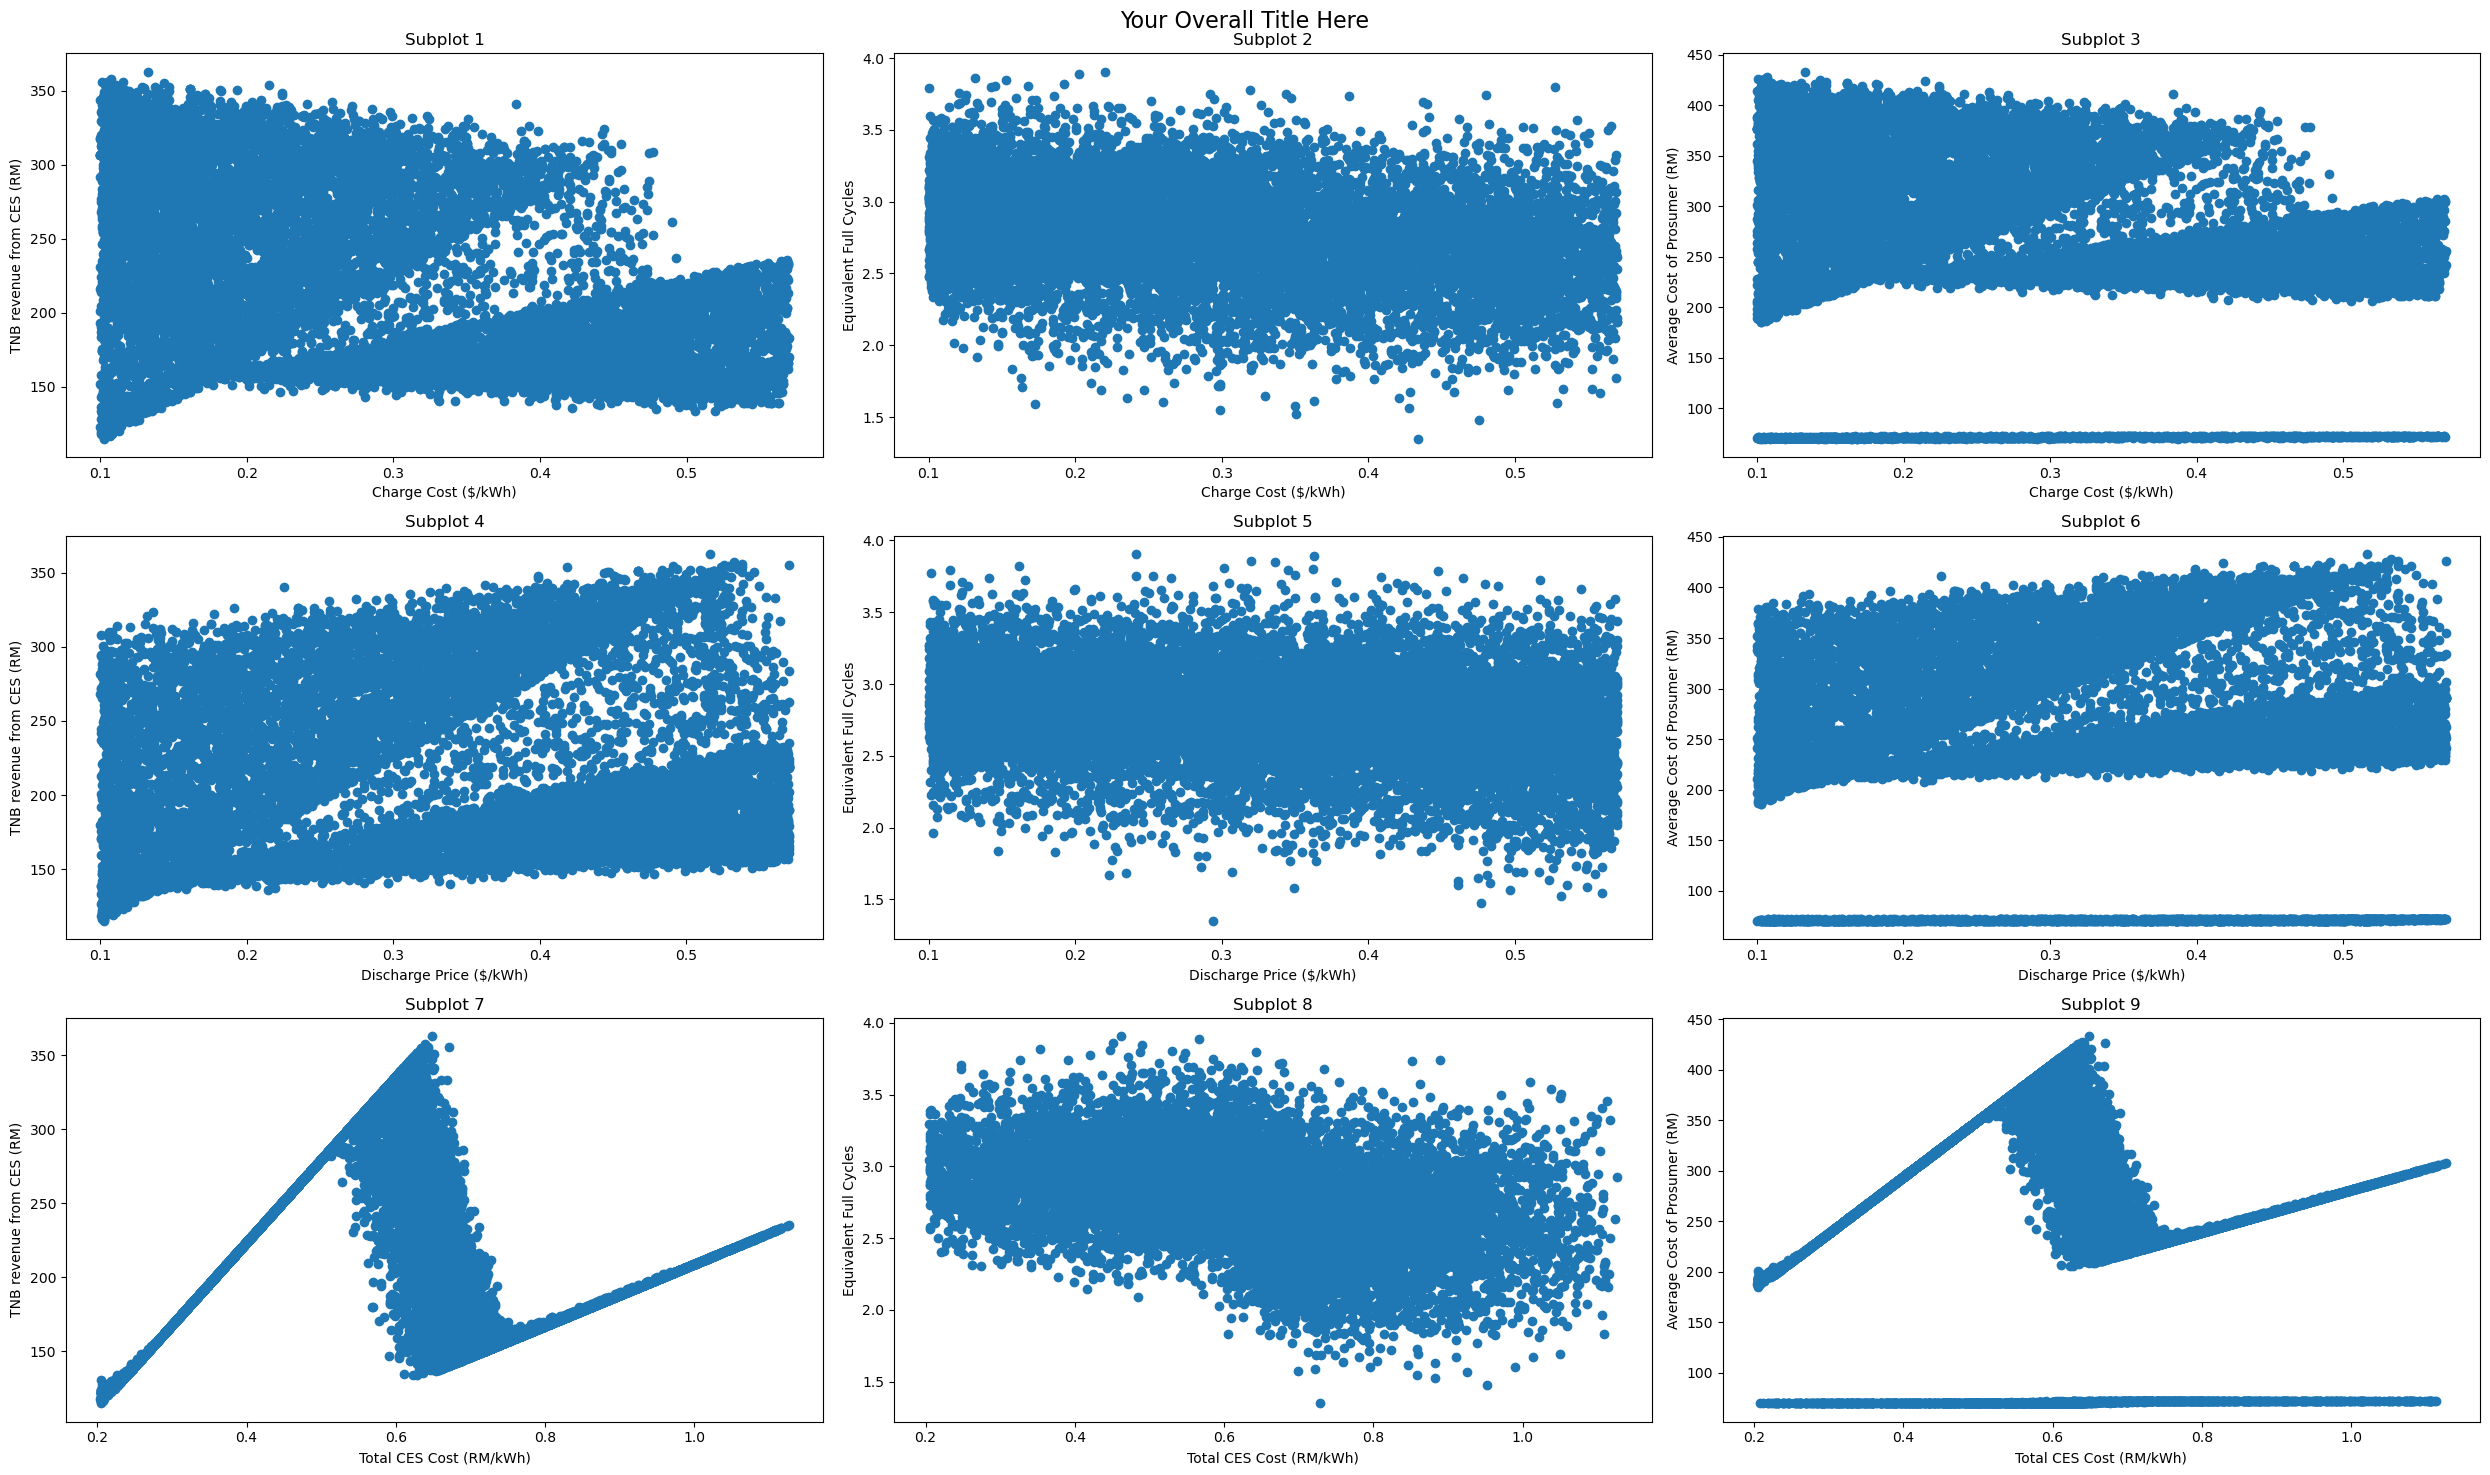

In [8]:
obj_non_dom_array, position_non_dom_array = obj_proc(obj_df, position_df, df=False)

# Create figure and subplots
fig, axs = plt.subplots(3, 3, figsize=(25, 15))
fig.suptitle('Your Overall Title Here', fontsize=16)

# Flatten axs array for easier iteration if needed
axs = axs.flatten()

# Example for each subplot
for i in range(9):
    if i < 6:
        # Here you can customize each subplot
        axs[i].set_xlabel(position_non_dom.columns[0 if i < 3 else 1])
        axs[i].set_ylabel(obj_non_dom.columns[i % 3])
        axs[i].set_title(f'Subplot {i+1}')
        
        # Add your plotting commands here for each subplot
        # Example: axs[i].plot(x, y)
        # Example: axs[i].scatter(x, y)
        axs[i].plot(position_non_dom_array[:, 0 if i < 3 else 1], obj_non_dom_array[:, i % 3], 'o')
    else:
        axs[i].set_xlabel('Total CES Cost (RM/kWh)')
        axs[i].set_ylabel(obj_non_dom.columns[(i - 6) % 3])
        axs[i].set_title(f'Subplot {i+1}')

        total_ces_cost = position_non_dom_array[:, 0] + position_non_dom_array[:, 1]
        axs[i].plot(total_ces_cost, obj_non_dom_array[:, (i - 6) % 3], 'o')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

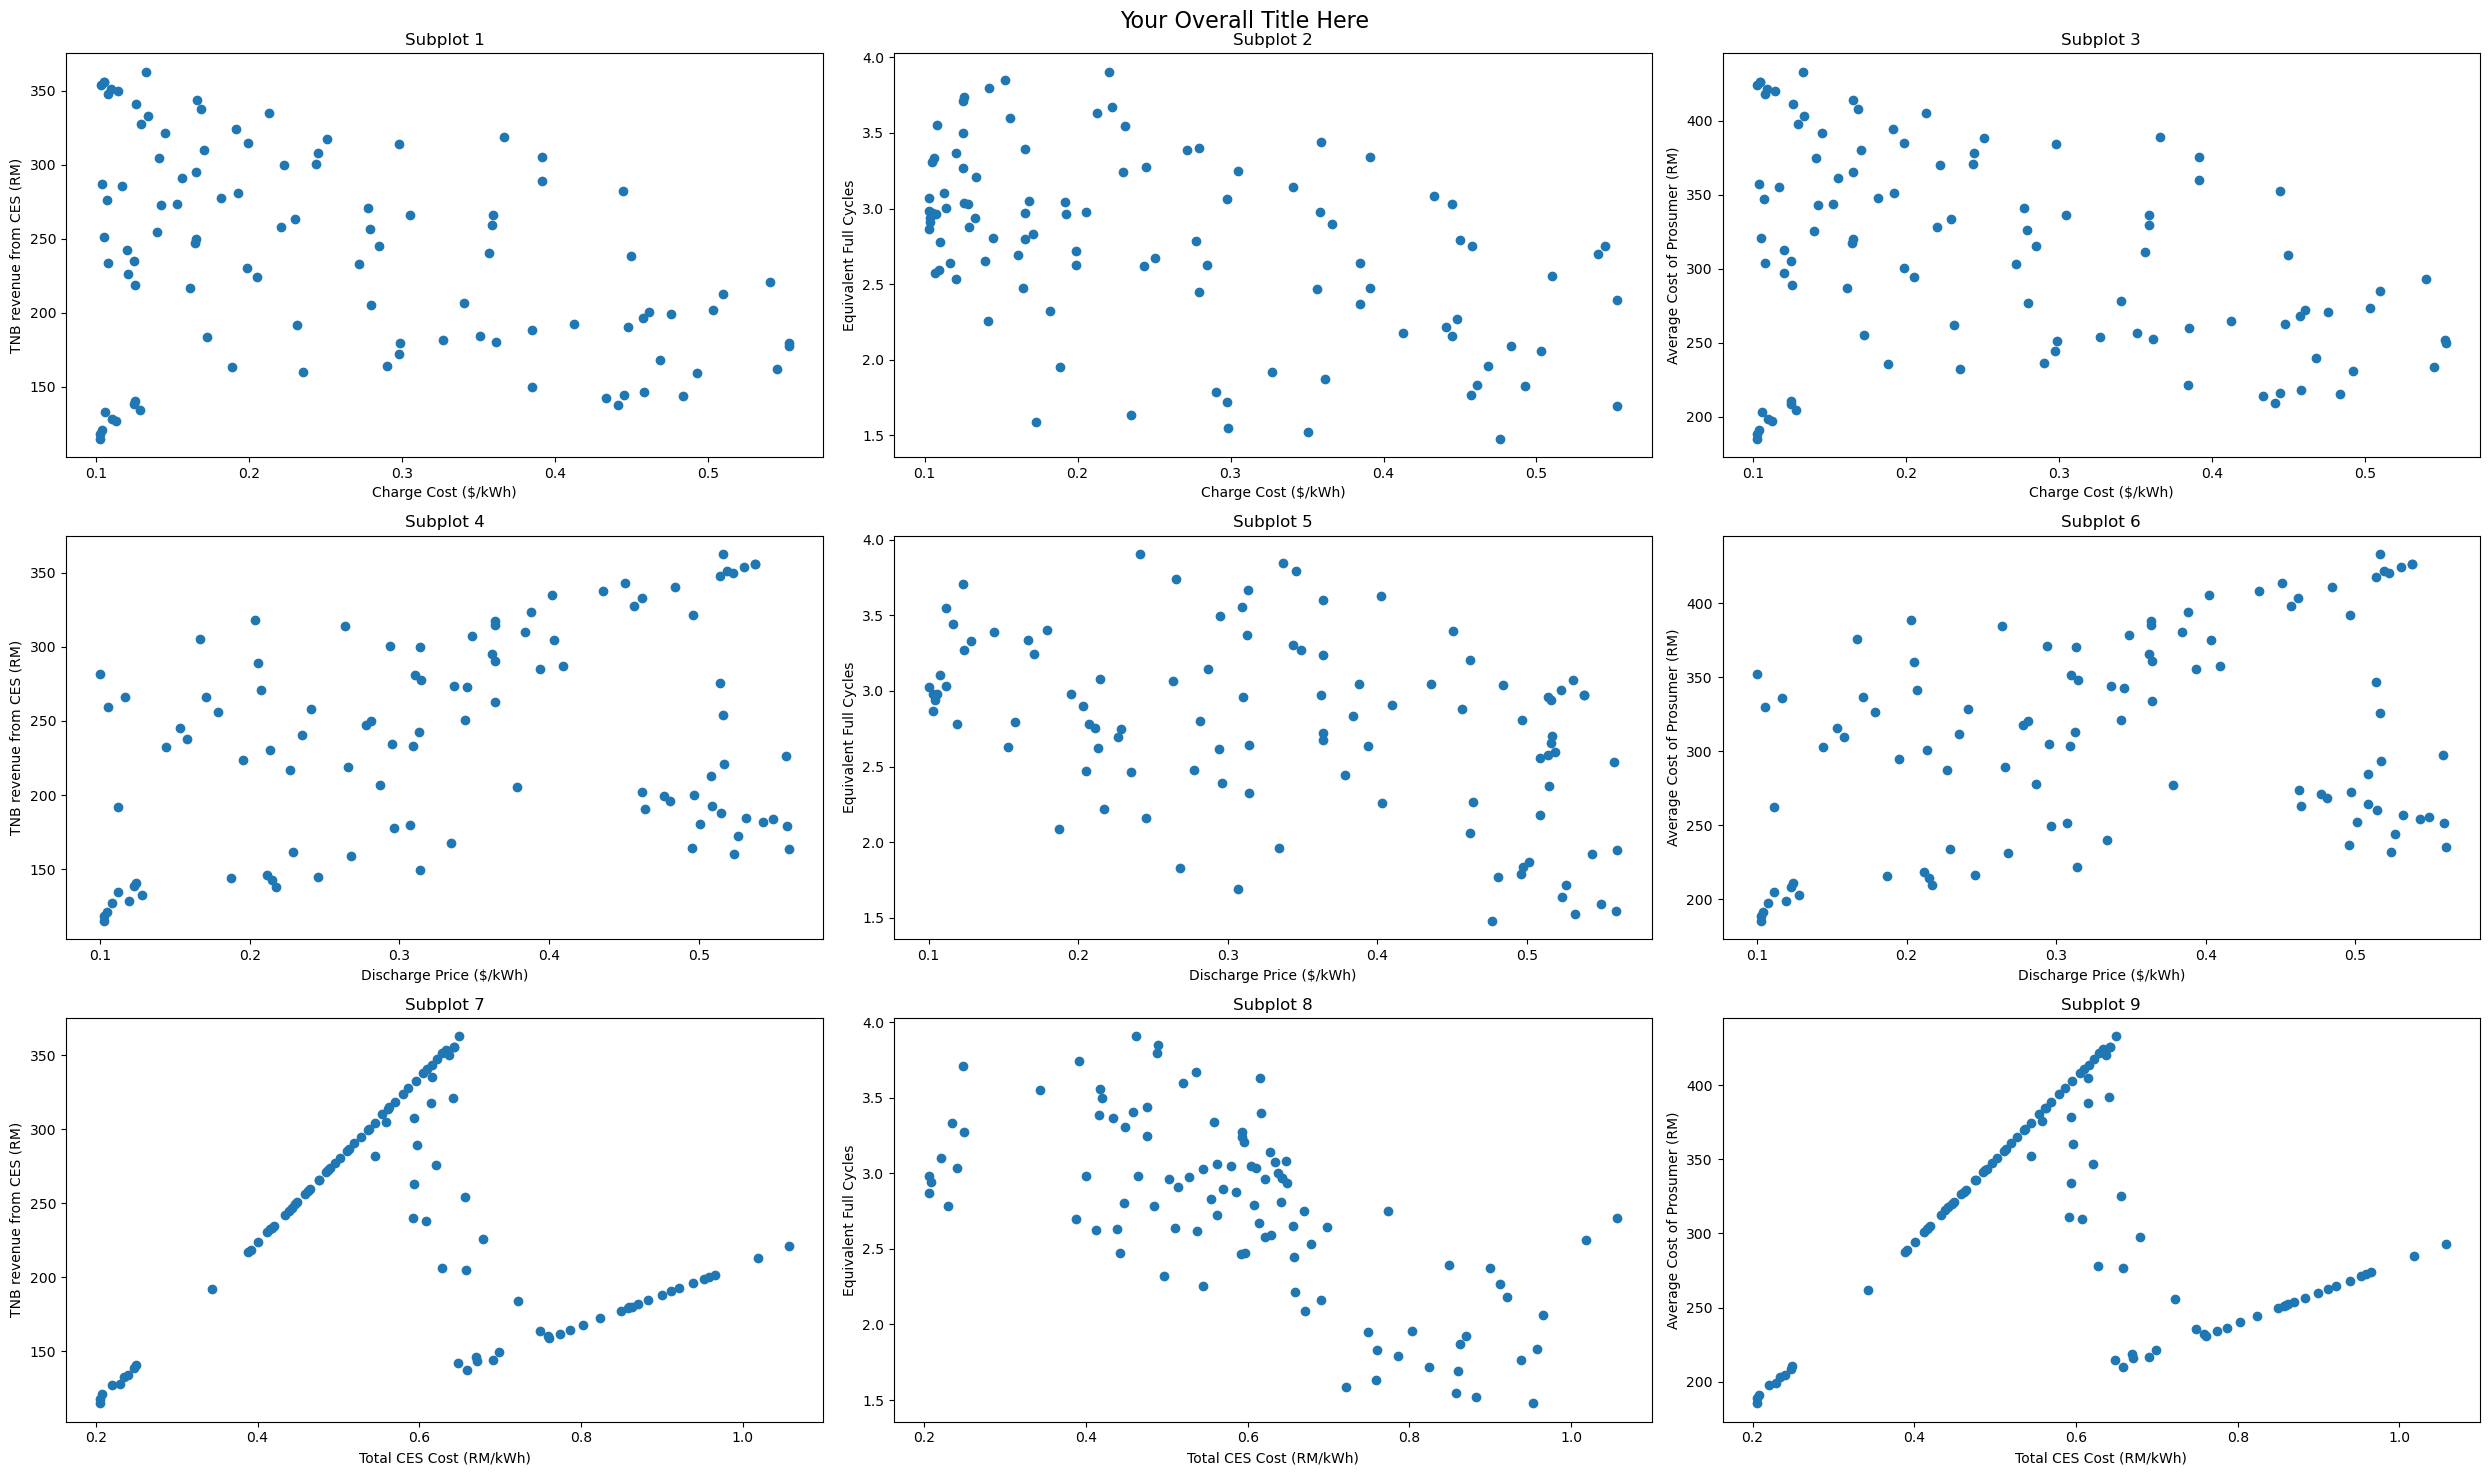

In [9]:
obj_non_dom_array, position_non_dom_array = obj_proc(obj_df_non_dom, position_df_non_dom, df=False)

# Create figure and subplots
fig, axs = plt.subplots(3, 3, figsize=(25, 15))
fig.suptitle('Your Overall Title Here', fontsize=16)

# Flatten axs array for easier iteration if needed
axs = axs.flatten()

# Example for each subplot
for i in range(9):
    if i < 6:
        # Here you can customize each subplot
        axs[i].set_xlabel(position_non_dom.columns[0 if i < 3 else 1])
        axs[i].set_ylabel(obj_non_dom.columns[i % 3])
        axs[i].set_title(f'Subplot {i+1}')
        
        # Add your plotting commands here for each subplot
        # Example: axs[i].plot(x, y)
        # Example: axs[i].scatter(x, y)
        axs[i].plot(position_non_dom_array[:, 0 if i < 3 else 1], obj_non_dom_array[:, i % 3], 'o')
    else:
        axs[i].set_xlabel('Total CES Cost (RM/kWh)')
        axs[i].set_ylabel(obj_non_dom.columns[(i - 6) % 3])
        axs[i].set_title(f'Subplot {i+1}')

        total_ces_cost = position_non_dom_array[:, 0] + position_non_dom_array[:, 1]
        axs[i].plot(total_ces_cost, obj_non_dom_array[:, (i - 6) % 3], 'o')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

# Usage basis limited

In [3]:
result_loc = "momsa_full_log (usage unrank limit)1"
non_dom_result_loc = "MOMSA unrank limit 1"

position_df = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="all_X", header=None)
position_df_non_dom = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{non_dom_result_loc}.xlsx", sheet_name="Sheet1", header=None)

## (-TNB_revenue_CESs, EFCs, costP)
obj_df = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="all_F", header=None)   
obj_df_non_dom = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{non_dom_result_loc}.xlsx", sheet_name="Sheet2", header=None)

In [4]:
obj, position = obj_proc(obj_df, position_df)
obj_non_dom, position_non_dom = obj_proc(obj_df_non_dom, position_df_non_dom)

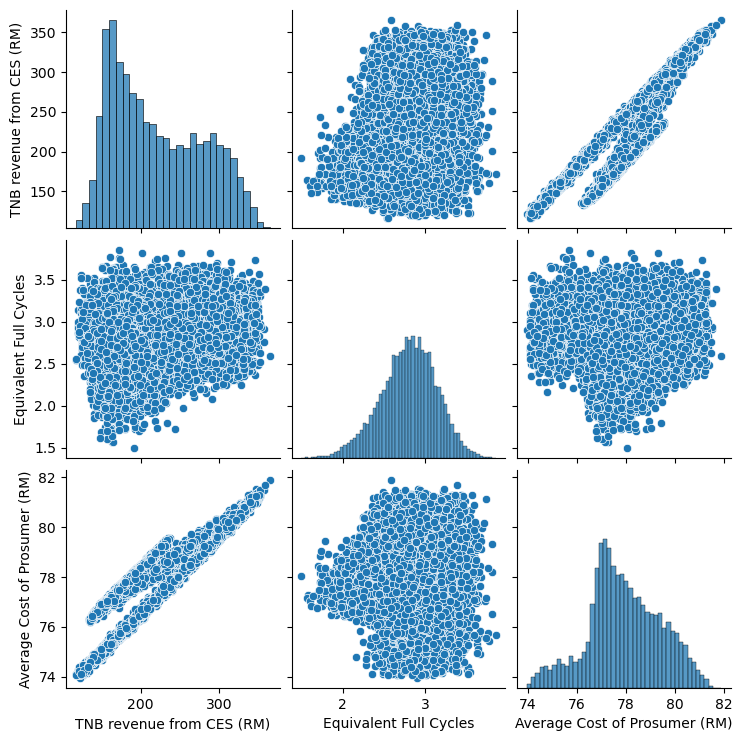

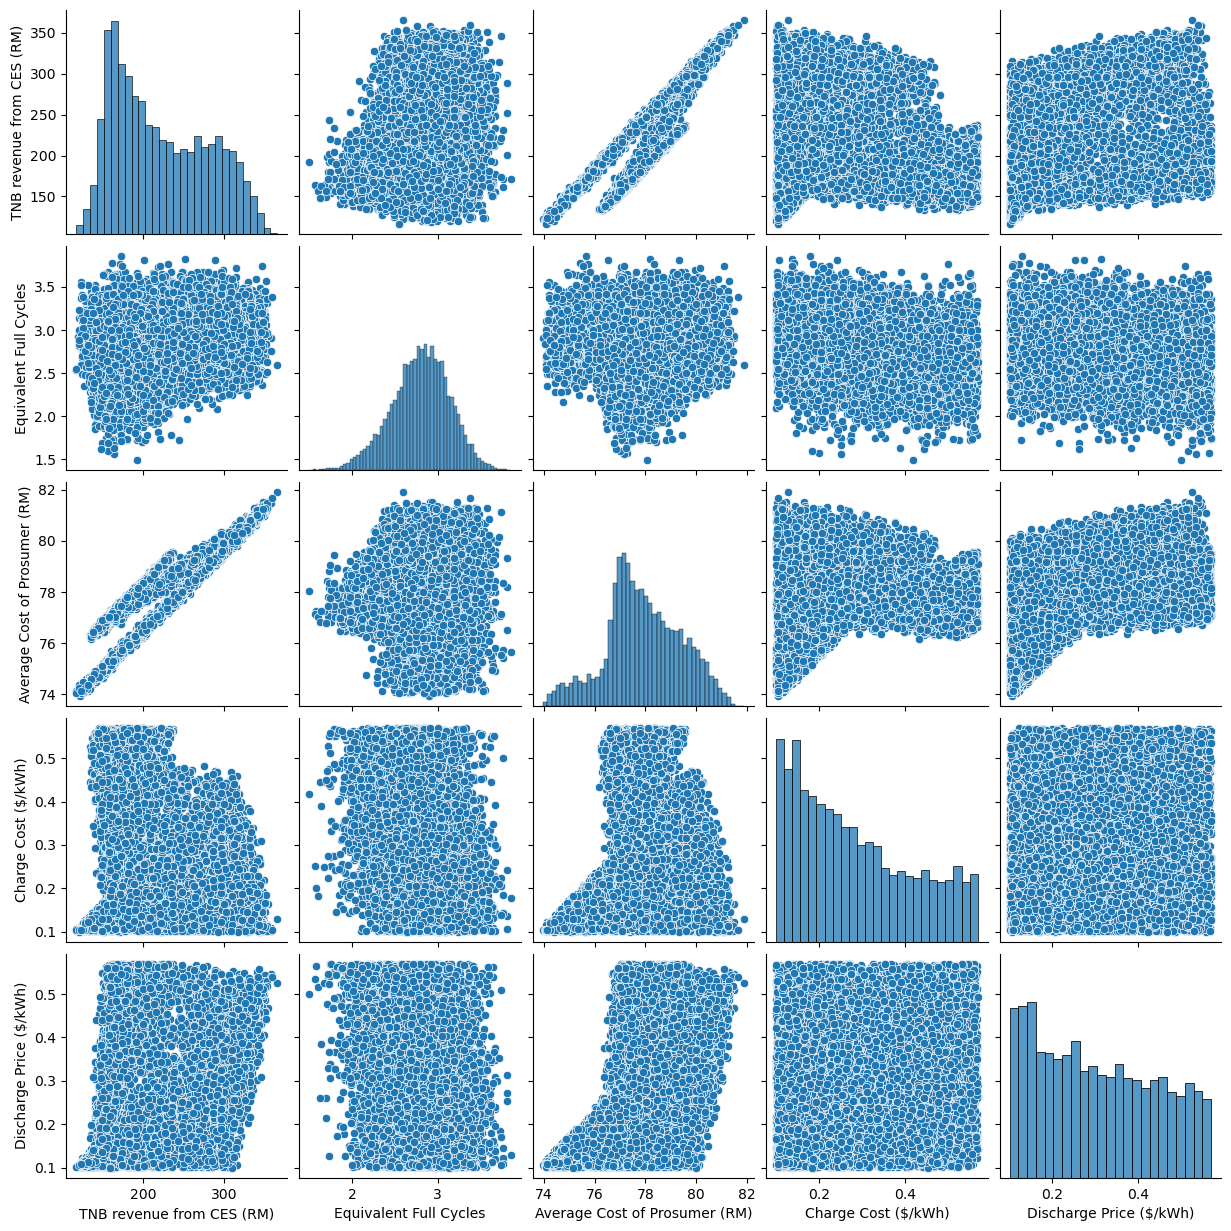

In [5]:
import seaborn as sns

sns.pairplot(obj)
# sns.pairplot(obj_non_dom)
combined_df = pd.concat([obj, position], axis=1)
sns.pairplot(combined_df)


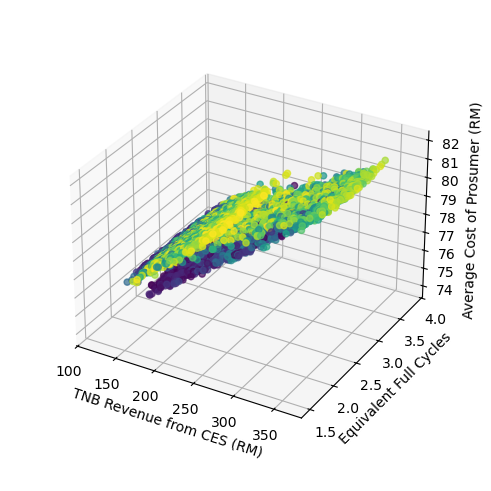

In [6]:
obj_array, position_array = obj_proc(obj_df, position_df, df=False)

from mpl_toolkits.mplot3d import Axes3D
fontttt = 10
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(obj_array[:,0], obj_array[:,1], obj_array[:,2], c=position_array[:,1], cmap='viridis', alpha=0.7)
ax.set_xlabel('TNB Revenue from CES (RM)', fontsize=fontttt)
ax.set_ylabel('Equivalent Full Cycles', fontsize=fontttt)
ax.set_zlabel('Average Cost of Prosumer (RM)', fontsize=fontttt)
# ax.set_title('Pareto Front in Objective Space', fontsize=14)
ax.set_box_aspect(aspect=None, zoom=0.85)
plt.savefig(f"test.png", format = "png", bbox_inches='tight', dpi = 300)
plt.show()



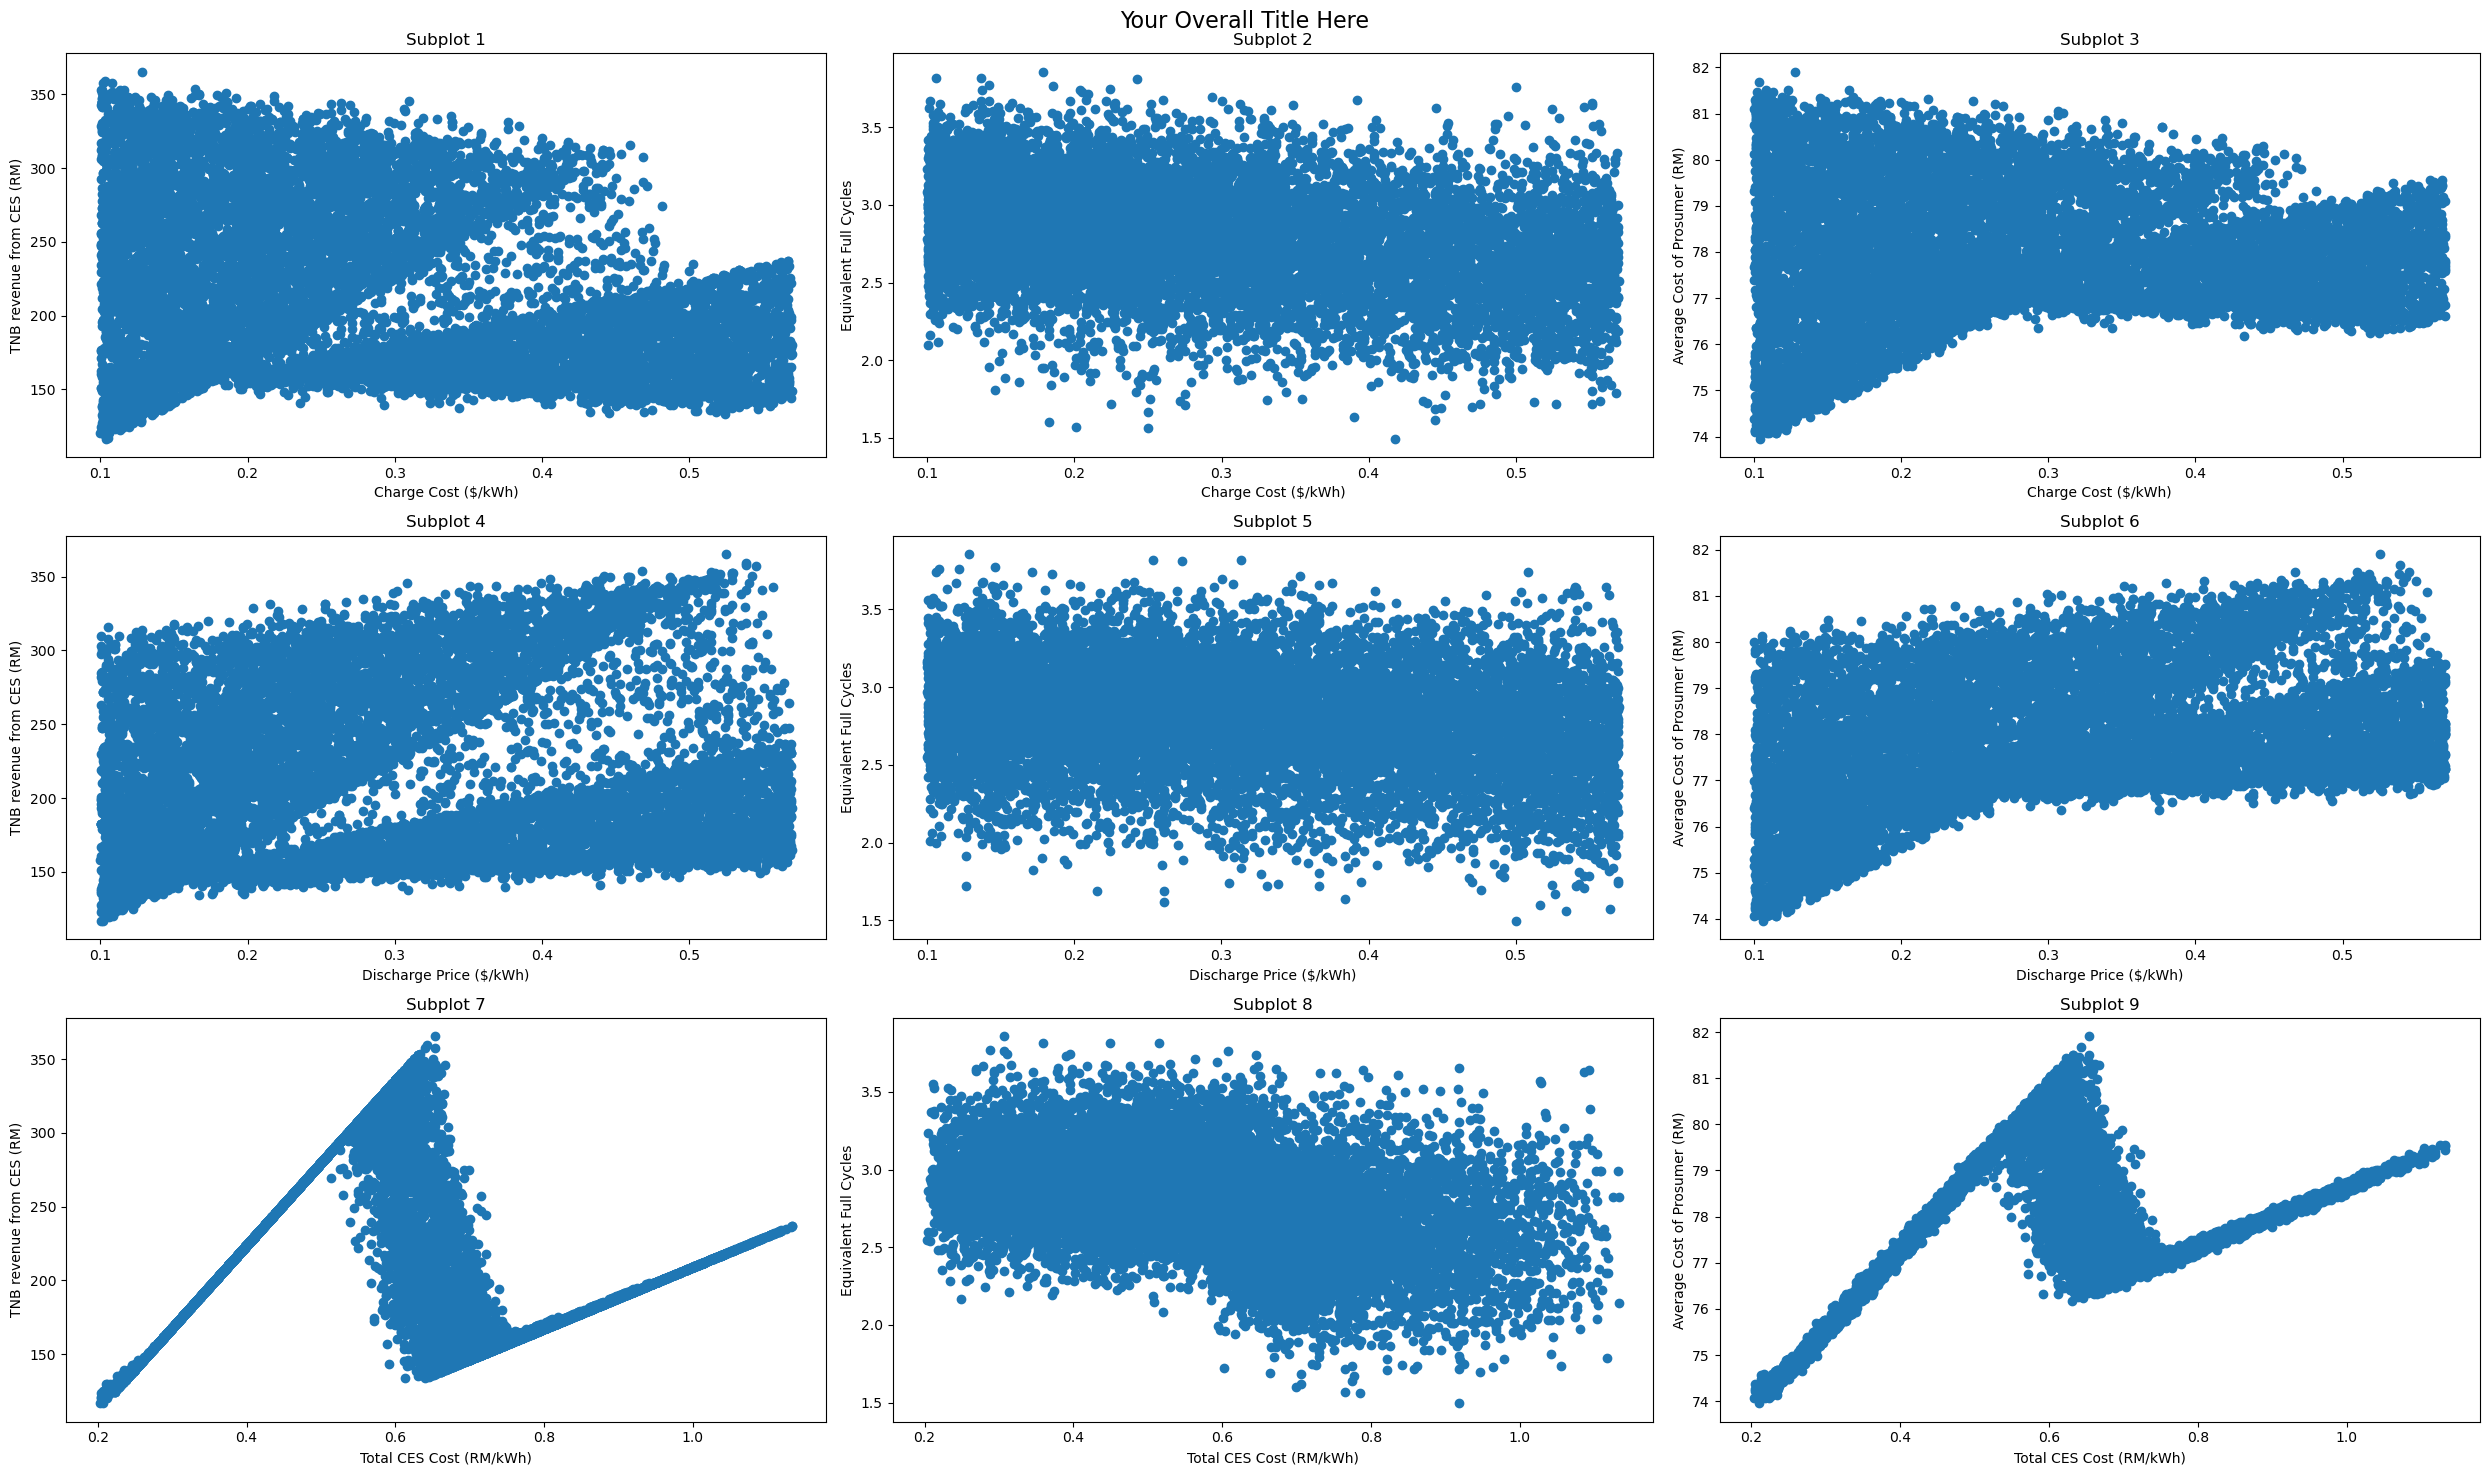

In [7]:
obj_non_dom_array, position_non_dom_array = obj_proc(obj_df, position_df, df=False)

# Create figure and subplots
fig, axs = plt.subplots(3, 3, figsize=(25, 15))
fig.suptitle('Your Overall Title Here', fontsize=16)

# Flatten axs array for easier iteration if needed
axs = axs.flatten()

# Example for each subplot
for i in range(9):
    if i < 6:
        # Here you can customize each subplot
        axs[i].set_xlabel(position_non_dom.columns[0 if i < 3 else 1])
        axs[i].set_ylabel(obj_non_dom.columns[i % 3])
        axs[i].set_title(f'Subplot {i+1}')
        
        # Add your plotting commands here for each subplot
        # Example: axs[i].plot(x, y)
        # Example: axs[i].scatter(x, y)
        axs[i].plot(position_non_dom_array[:, 0 if i < 3 else 1], obj_non_dom_array[:, i % 3], 'o')
    else:
        axs[i].set_xlabel('Total CES Cost (RM/kWh)')
        axs[i].set_ylabel(obj_non_dom.columns[(i - 6) % 3])
        axs[i].set_title(f'Subplot {i+1}')

        total_ces_cost = position_non_dom_array[:, 0] + position_non_dom_array[:, 1]
        axs[i].plot(total_ces_cost, obj_non_dom_array[:, (i - 6) % 3], 'o')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

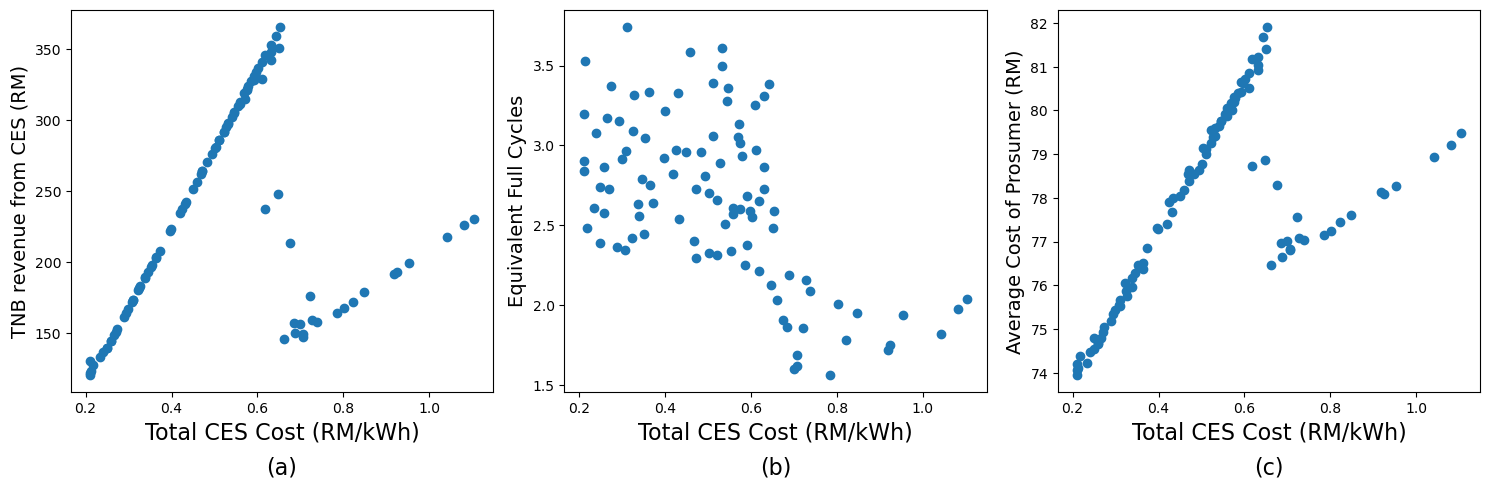

In [8]:
obj_non_dom_array, position_non_dom_array = obj_proc(obj_df_non_dom, position_df_non_dom, df=False)

# Create figure and subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
# fig.suptitle('Your Overall Title Here', fontsize=16)

# Flatten axs array for easier iteration if needed
axs = axs.flatten()
plot_title = ['(a)', '(b)', '(c)']

# Example for each subplot
for i in range(3):
    k = i
    # if i < 6:
    #     # Here you can customize each subplot
    #     axs[i].set_xlabel(position_non_dom.columns[0 if i < 3 else 1])
    #     axs[i].set_ylabel(obj_non_dom.columns[i % 3])
    #     axs[i].set_title(f'Subplot {i+1}')
        
    #     # Add your plotting commands here for each subplot
    #     # Example: axs[i].plot(x, y)
    #     # Example: axs[i].scatter(x, y)
    #     axs[i].plot(position_non_dom_array[:, 0 if i < 3 else 1], obj_non_dom_array[:, i % 3], 'o')
    # else:
        # k = i - 6
    axs[i].set_xlabel('Total CES Cost (RM/kWh)', fontsize =16)
    axs[i].set_ylabel(obj_non_dom.columns[(k) % 3], fontsize=14)
    axs[i].set_title(plot_title[i], y=-0.25, pad=10, fontsize=16)

    total_ces_cost = position_non_dom_array[:, 0] + position_non_dom_array[:, 1]
    axs[i].plot(total_ces_cost, obj_non_dom_array[:, (k) % 3], 'o')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.savefig(f"ROI_dec_vs_obj.png", format = "png", bbox_inches='tight', dpi = 300)
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_65240\2920503783.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([position_non_dom_array[:,0], position_non_dom_array[:,1]], labels=['Charge', 'Discharge'])


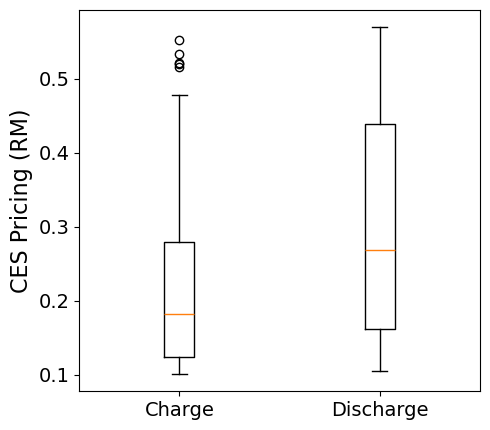

In [9]:
# Create the box plot
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# Execution Time box plot
ax.boxplot([position_non_dom_array[:,0], position_non_dom_array[:,1]], labels=['Charge', 'Discharge'])
# ax.set_xlabel('CES Pricing (RM)', fontsize=16)
ax.set_ylabel('CES Pricing (RM)', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)

# Add overall title and display the plot
# fig.suptitle('Comparison of Performance Metrics for w/o AI vs w/ AI')
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust the title space
plt.savefig('ROI_price_box.png')  # Save the figure as a PNG
plt.show()

# Usage basis limited v2

In [4]:
result_loc = "momsa_full_log (usage v2 unrank limit)1"
non_dom_result_loc = "MOMSA unrank limit usage v2 1"

position_df = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="all_X", header=None)
position_df_non_dom = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{non_dom_result_loc}.xlsx", sheet_name="Sheet1", header=None)

## (-TNB_revenue_CESs, EFCs, costP)
obj_df = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="all_F", header=None)   
obj_df_non_dom = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{non_dom_result_loc}.xlsx", sheet_name="Sheet2", header=None)

In [5]:
obj, position = obj_proc(obj_df, position_df)
obj_non_dom, position_non_dom = obj_proc(obj_df_non_dom, position_df_non_dom)

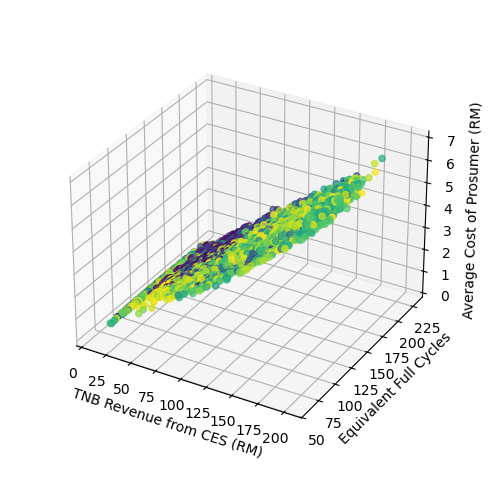

In [6]:
obj_array, position_array = obj_proc(obj_df, position_df, df=False)

from mpl_toolkits.mplot3d import Axes3D
fontttt = 10
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(obj_array[:,0], obj_array[:,1], obj_array[:,2], c=position_array[:,1], cmap='viridis', alpha=0.7)
ax.set_xlabel('TNB Revenue from CES (RM)', fontsize=fontttt)
ax.set_ylabel('Equivalent Full Cycles', fontsize=fontttt)
ax.set_zlabel('Average Cost of Prosumer (RM)', fontsize=fontttt)
# ax.set_title('Pareto Front in Objective Space', fontsize=14)
ax.set_box_aspect(aspect=None, zoom=0.85)
plt.savefig(f"test.png", format = "png", bbox_inches='tight', dpi = 300)
plt.show()



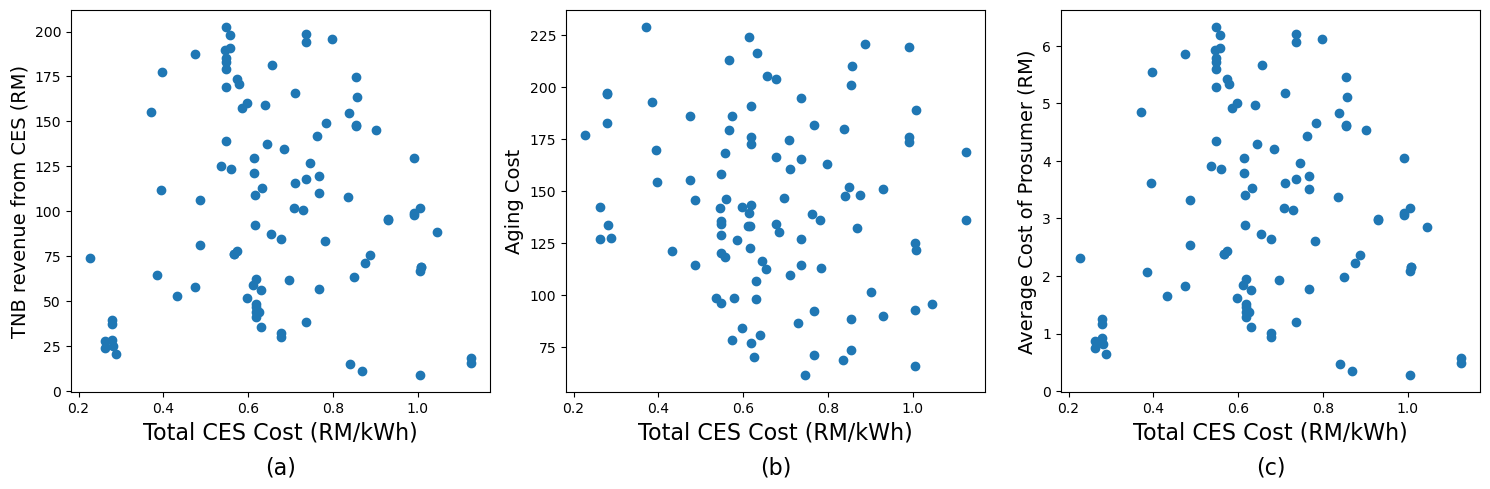

In [7]:
obj_non_dom_array, position_non_dom_array = obj_proc(obj_df_non_dom, position_df_non_dom, df=False)

# Create figure and subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
# fig.suptitle('Your Overall Title Here', fontsize=16)

# Flatten axs array for easier iteration if needed
axs = axs.flatten()
plot_title = ['(a)', '(b)', '(c)']

# Example for each subplot
for i in range(3):
    k = i
    # if i < 6:
    #     # Here you can customize each subplot
    #     axs[i].set_xlabel(position_non_dom.columns[0 if i < 3 else 1])
    #     axs[i].set_ylabel(obj_non_dom.columns[i % 3])
    #     axs[i].set_title(f'Subplot {i+1}')
        
    #     # Add your plotting commands here for each subplot
    #     # Example: axs[i].plot(x, y)
    #     # Example: axs[i].scatter(x, y)
    #     axs[i].plot(position_non_dom_array[:, 0 if i < 3 else 1], obj_non_dom_array[:, i % 3], 'o')
    # else:
        # k = i - 6
    axs[i].set_xlabel('Total CES Cost (RM/kWh)', fontsize =16)
    axs[i].set_ylabel(obj_non_dom.columns[(k) % 3], fontsize=14)
    axs[i].set_title(plot_title[i], y=-0.25, pad=10, fontsize=16)

    total_ces_cost = position_non_dom_array[:, 0] + position_non_dom_array[:, 1]
    axs[i].plot(total_ces_cost, obj_non_dom_array[:, (k) % 3], 'o')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.savefig(f"ROI_dec_vs_obj.png", format = "png", bbox_inches='tight', dpi = 300)
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_56596\2058304118.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([position_non_dom_array[:,0], position_non_dom_array[:,1]], labels=['Charge', 'Discharge'])
C:\Users\PC\AppData\Local\Temp\ipykernel_56596\2058304118.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([position_non_dom_array[:,2], position_non_dom_array[:,3]], labels=['P2P Charge', 'P2P Discharge'])
C:\Users\PC\AppData\Local\Temp\ipykernel_56596\2058304118.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[2].boxplot([position_non_dom_array[:,4], position_non_dom_array[:,5]], 

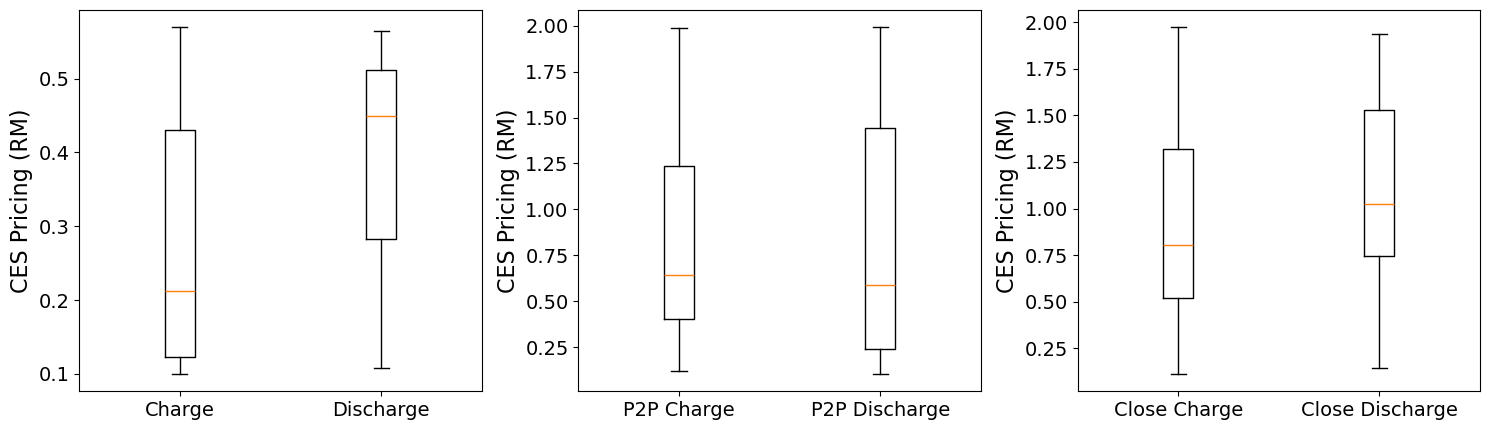

In [8]:
# Create the box plot
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Execution Time box plot
ax[0].boxplot([position_non_dom_array[:,0], position_non_dom_array[:,1]], labels=['Charge', 'Discharge'])
ax[0].set_ylabel('CES Pricing (RM)', fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=14)

ax[1].boxplot([position_non_dom_array[:,2], position_non_dom_array[:,3]], labels=['P2P Charge', 'P2P Discharge'])
ax[1].set_ylabel('CES Pricing (RM)', fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=14)

ax[2].boxplot([position_non_dom_array[:,4], position_non_dom_array[:,5]], labels=['Close Charge', 'Close Discharge'])
ax[2].set_ylabel('CES Pricing (RM)', fontsize=16)
ax[2].tick_params(axis='both', which='major', labelsize=14)
# Add overall title and display the plot
# fig.suptitle('Comparison of Performance Metrics for w/o AI vs w/ AI')
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust the title space
plt.savefig('ROI_price_box.png')  # Save the figure as a PNG
plt.show()

# Cost/Profit Processing

### Usage v1

Old version - consider prosumer have limited capacity and need to maintain battery level in code wise

In [ ]:
#### Optimal Price Obtained ####
charge_cost     = 0.12796992
discharge_cost  = 0.52551031

CESq_loc = r"D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\p2p_CES\limit\Charge_Discharge.csv"
CESq = pd.read_csv(CESq_loc, header=None).to_numpy()[:,:-1] 
pros_CES_cost = np.zeros(32)

for u in range(32):
    for t in range(48):
        pros_CES_cost[u] += np.abs(CESq[t,u]) * (charge_cost if CESq[t,u]>0 else discharge_cost)

TNB_revenue_CES = np.sum(pros_CES_cost)

In [ ]:
# Prosumer Cost Comparison
costN_loc = r"MOMSA_code\Benchmark\p2p_noCES\ProsumerCost_normal tariff.csv"
costP2P_loc = r"MOMSA_code\Benchmark\p2p_noCES\ProsumerCost.csv"
costP2PCES_loc = r"MOMSA_code\Benchmark\p2p_CES\limit\ProsumerCost.csv"

costN = pd.read_csv(costN_loc, header=None).to_numpy()
costP2P = pd.read_csv(costP2P_loc, header=None).to_numpy()
costP2PwoCES = pd.read_csv(costP2PCES_loc, header=None).to_numpy() 
costP2PCES = costP2PwoCES + pros_CES_cost

CSP2P = costN - costP2P
CSP2P_CES = costN - costP2PCES

np.mean(costN), np.mean(costP2P), np.mean(costP2PCES)

(np.float64(90.2378125), np.float64(74.40875), np.float64(80.14409823105001))

In [ ]:
# TNB revenue
TNBP2P_loc = r"MOMSA_code\Benchmark\p2p_noCES\TNBProfit.csv"
TNBP2PCES_loc = r"MOMSA_code\Benchmark\p2p_CES\limit\TNBProfit.csv"

TNB_normal = np.sum(costN) * 0.15
TNB_P2P = pd.read_csv(TNBP2P_loc, header=None).to_numpy()
TNB_P2PwoCES = pd.read_csv(TNBP2PCES_loc, header=None).to_numpy()
TNB_P2PCES = TNB_P2PwoCES + TNB_revenue_CES

TNB_normal, TNB_P2P, TNB_P2PwoCES, TNB_P2PCES


(np.float64(433.1415),
 array([[1138.35]]),
 array([[1043.01]]),
 array([[1343.62114339]]))

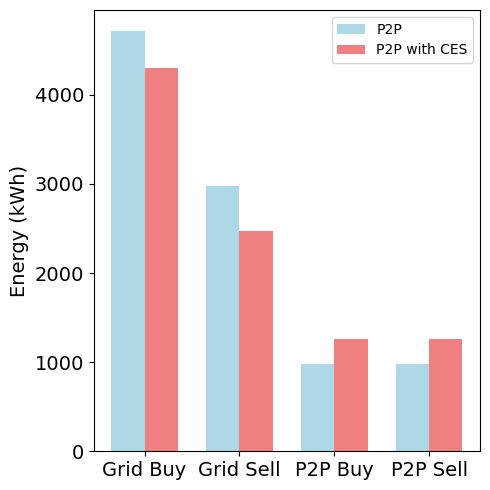

In [ ]:
# P2P trading amount breakdown
gbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\Grid_buy.csv"
gbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\limit\Grid_buy.csv"
gsell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\Grid_sell.csv"
gsell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\limit\Grid_sell.csv"
pbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\P2P_buy.csv"
pbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\limit\P2P_buy.csv"
psell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\P2P_sell.csv"
psell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\limit\P2P_sell.csv"

gbuy_p2p        = pd.read_csv(gbuy_loc, header=None).to_numpy()[:,:-1]
gbuy_p2p_CES    = pd.read_csv(gbuy_CES_loc, header=None).to_numpy()[:,:-1]
gsell_p2p       = pd.read_csv(gsell_loc, header=None).to_numpy()[:,:-1]
gsell_p2p_CES   = pd.read_csv(gsell_CES_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p        = pd.read_csv(pbuy_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p_CES    = pd.read_csv(pbuy_CES_loc, header=None).to_numpy()[:,:-1]
psell_p2p       = pd.read_csv(psell_loc, header=None).to_numpy()[:,:-1]
psell_p2p_CES   = pd.read_csv(psell_CES_loc, header=None).to_numpy()[:,:-1]

# Calculate total amounts for each category
gbuy_total = np.sum(gbuy_p2p), np.sum(gbuy_p2p_CES)
gsell_total = np.sum(gsell_p2p), np.sum(gsell_p2p_CES)
pbuy_total = np.sum(pbuy_p2p), np.sum(pbuy_p2p_CES)
psell_total = np.sum(psell_p2p), np.sum(psell_p2p_CES)

# Set up the bar chart
fig, ax = plt.subplots(figsize=(5, 5))

# Set position of bar on X axis
x = np.arange(4)
width = 0.35

# Create bars
rects1 = ax.bar(x - width/2, [gbuy_total[0], gsell_total[0], pbuy_total[0], psell_total[0]], 
                width, label='P2P', color='lightblue')
rects2 = ax.bar(x + width/2, [gbuy_total[1], gsell_total[1], pbuy_total[1], psell_total[1]], 
                width, label='P2P with CES', color='lightcoral')

# Customize the plot
ax.set_ylabel('Energy (kWh)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Grid Buy', 'Grid Sell', 'P2P Buy', 'P2P Sell'], fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('p2p_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

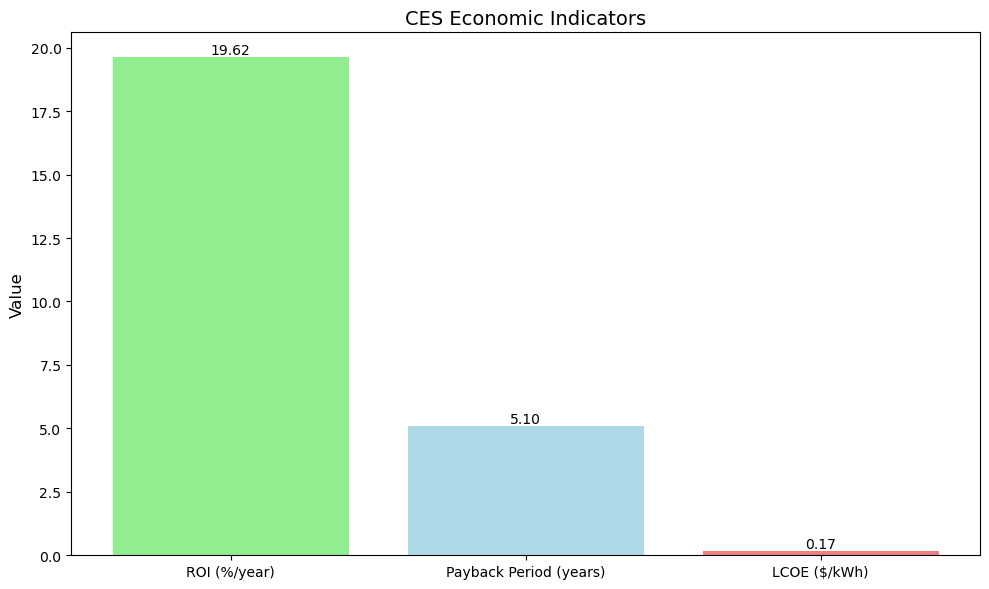


Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $109,723.07
ROI: 19.62%
ROI (Lifetime): 392.46%
Payback Period: 5.10 years
LCOE: $0.1665/kWh


In [ ]:
# Economic Indicators
CES_capacity = 500  # kWh
CES_cost_per_kWh = 400  # $/kWh
CES_initial_cost = 559160.47

# Calculate annual values (assuming 48 half-hour periods = 1 day)
days_per_year = 365
annual_revenue = TNB_revenue_CES * days_per_year

# Calculate economic indicators
ROI = (annual_revenue / CES_initial_cost) * 100  # %
ROI_lifetime = (annual_revenue * 20 / CES_initial_cost) * 100  # %
payback_period = CES_initial_cost / annual_revenue  # years
LCOE = CES_initial_cost / (np.abs(np.sum(CESq[CESq < 0])) * days_per_year * 20)  # $ per kWh over 20 years

# Create figure for economic indicators
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['ROI (%/year)', 'Payback Period (years)', 'LCOE ($/kWh)']
values = [ROI, payback_period, LCOE]
colors = ['lightgreen', 'lightblue', 'lightcoral']

bars = ax.bar(metrics, values, color=colors)
ax.set_ylabel('Value', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_title('CES Economic Indicators', fontsize=14)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom')

plt.tight_layout()
plt.savefig('economic_indicators.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed results
print("\nEconomic Indicators:")
print(f"Initial Investment: ${CES_initial_cost:,.2f}")
print(f"Annual Revenue: ${annual_revenue:,.2f}")
print(f"ROI: {ROI:.2f}%")
print(f"ROI (Lifetime): {ROI_lifetime:.2f}%")
print(f"Payback Period: {payback_period:.2f} years")
print(f"LCOE: ${LCOE:.4f}/kWh")

### Usage v2

In [44]:
#### Optimal Price Obtained ####
result_loc = 'MOMSA ranked limit usage v2 1'
result = np.array(pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\For paper\{result_loc}.xlsx", sheet_name="Sheet1", header=None))
sol = 0

exe_path = r'"C:\Users\PC\source\repos\p2p_optimal placement\x64\Release\p2p_optimal placement.exe"'

opt_sol = result[sol,:]
L = opt_sol.copy()
L[2] = L[0] * L[2]
L[3] = L[1] * L[3]
L[4] = L[0] * L[4]
L[5] = L[1] * L[5]
input_cpp = L / 0.57

# Convert inputs to space-separated string
input_string = " ".join(map(str, input_cpp))

# Final CMD command
cmd = f"& {exe_path} {input_string}"

# Print so you can copy-paste into terminal
print(cmd)

& "C:\Users\PC\source\repos\p2p_optimal placement\x64\Release\p2p_optimal placement.exe" 0.18471818695612222 0.7749569653306067 0.08625710816447031 1.119394366611218 0.09645980207261448 0.7856874092704104


In [46]:
## Compute the revenue obtained from CES operation with the optimal price obtained
inputs = opt_sol.copy()
p2p_discount = inputs[2] * 100, inputs[3] * 100
close_discount = inputs[4] * 100, inputs[5] * 100
inputs[2] = inputs[0] * inputs[2]  # P2P charge price
inputs[3] = inputs[1] * inputs[3]  # P2P discharge price
inputs[4] = inputs[0] * inputs[4]  # Close charge price
inputs[5] = inputs[1] * inputs[5]  # Close discharge price
CESq_loc = r"D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\p2p_CES\usage v2\Charge_Discharge.csv"
CESq = pd.read_csv(CESq_loc, header=None).to_numpy()[:,:-1] 

cost_c, cost_d, cost_c_p2p, cost_d_p2p, cost_c_close, cost_d_close = inputs

cost_c_t = np.empty(48, dtype=float)
cost_d_t = np.empty(48, dtype=float)

cost_c_t[:16]   = cost_c
cost_d_t[:16]   = cost_d
cost_c_t[16:37] = cost_c_p2p   # MATLAB 17:37 -> Python 16:37
cost_d_t[16:37] = cost_d_p2p
cost_c_t[37:] = cost_c_close # MATLAB 38:48 -> Python 37:48
cost_d_t[37:] = cost_d_close

# Use broadcasting: (48,1) * (48,32) -> (48,32)
charge_component = cost_c_t[:, None] * CESq            # applied to positive q values
discharge_component = cost_d_t[:, None] * (-CESq)      # applied to negative q values (use -q)

# Build cost_matrix: positive q -> charge_component, negative q -> discharge_component, else 0
cost_matrix = np.where(CESq > 0, charge_component,
                       np.where(CESq < 0, discharge_component, 0.0))

# Aggregates
TNB_revenue_CES = cost_matrix.sum()
pros_CES_cost = cost_matrix.sum(axis=0)   # shape (32,)

print('(charge, discharge)')
print(f'Base/Start period price         : (${cost_c:.2f}, ${cost_d:.2f})')
print(f'P2P period price                : (${cost_c_p2p:.2f}, ${cost_d_p2p:.2f}), ({p2p_discount[0]:.2f}%, {p2p_discount[1]:.2f}%)')
print(f'Close period price              : (${cost_c_close:.2f}, ${cost_d_close:.2f}), ({close_discount[0]:.2f}%, {close_discount[1]:.2f}%)')
print(f'TNB revenue from CES            : ${TNB_revenue_CES:.2f}')
print(f'CES cost for prosumer (Avg)     : ${np.mean(pros_CES_cost):.2f}')

(charge, discharge)
Base/Start period price         : ($0.11, $0.44)
P2P period price                : ($0.05, $0.64), (46.70%, 144.45%)
Close period price              : ($0.05, $0.45), (52.22%, 101.38%)
TNB revenue from CES            : $188.47
CES cost for prosumer (Avg)     : $5.89


In [ ]:
# Prosumer Cost Comparison
costN_loc = r"MOMSA_code\Benchmark\p2p_noCES\ProsumerCost_normal tariff.csv"
costP2P_loc = r"MOMSA_code\Benchmark\p2p_noCES\ProsumerCost.csv"
costP2PCES_loc = r"MOMSA_code\Benchmark\p2p_CES\limit\ProsumerCost.csv"

costN = pd.read_csv(costN_loc, header=None).to_numpy()
costP2P = pd.read_csv(costP2P_loc, header=None).to_numpy()
costP2PwoCES = pd.read_csv(costP2PCES_loc, header=None).to_numpy() 
costP2PCES = costP2PwoCES + pros_CES_cost

CSP2P = costN - costP2P
CSP2P_CES = costN - costP2PCES

np.mean(costN), np.mean(costP2P), np.mean(costP2PwoCES), np.mean(costP2PCES)

(np.float64(90.2378125),
 np.float64(74.40875),
 np.float64(70.75),
 np.float64(76.63975850101298))

In [48]:
# TNB revenue
TNBP2P_loc = r"MOMSA_code\Benchmark\p2p_noCES\TNBProfit.csv"
TNBP2PCES_loc = r"MOMSA_code\Benchmark\p2p_CES\limit\TNBProfit.csv"

TNB_normal = np.sum(costN) * 0.15
TNB_P2P = pd.read_csv(TNBP2P_loc, header=None).to_numpy()
TNB_P2PwoCES = pd.read_csv(TNBP2PCES_loc, header=None).to_numpy()
TNB_P2PCES = TNB_P2PwoCES + TNB_revenue_CES

TNB_normal, TNB_P2P, TNB_P2PwoCES, TNB_P2PCES


(np.float64(433.1415),
 array([[1138.35]]),
 array([[1043.01]]),
 array([[1231.48227203]]))

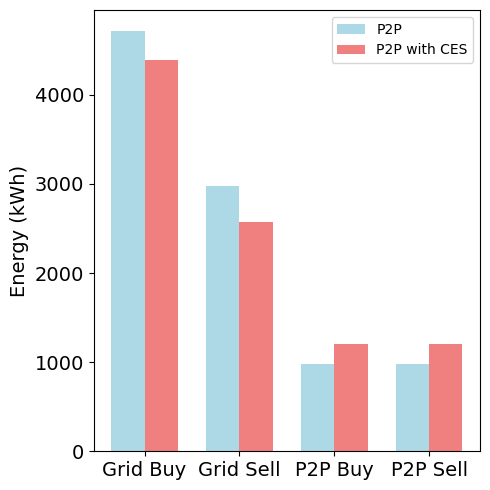

In [ ]:
# P2P trading amount breakdown
gbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\Grid_buy.csv"
gbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\usage v2\Grid_buy.csv"
gsell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\Grid_sell.csv"
gsell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\usage v2\Grid_sell.csv"
pbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\P2P_buy.csv"
pbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\usage v2\P2P_buy.csv"
psell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\P2P_sell.csv"
psell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\usage v2\P2P_sell.csv"

gbuy_p2p        = pd.read_csv(gbuy_loc, header=None).to_numpy()[:,:-1]
gbuy_p2p_CES    = pd.read_csv(gbuy_CES_loc, header=None).to_numpy()[:,:-1]
gsell_p2p       = pd.read_csv(gsell_loc, header=None).to_numpy()[:,:-1]
gsell_p2p_CES   = pd.read_csv(gsell_CES_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p        = pd.read_csv(pbuy_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p_CES    = pd.read_csv(pbuy_CES_loc, header=None).to_numpy()[:,:-1]
psell_p2p       = pd.read_csv(psell_loc, header=None).to_numpy()[:,:-1]
psell_p2p_CES   = pd.read_csv(psell_CES_loc, header=None).to_numpy()[:,:-1]

# Calculate total amounts for each category
gbuy_total = np.sum(gbuy_p2p), np.sum(gbuy_p2p_CES)
gsell_total = np.sum(gsell_p2p), np.sum(gsell_p2p_CES)
pbuy_total = np.sum(pbuy_p2p), np.sum(pbuy_p2p_CES)
psell_total = np.sum(psell_p2p), np.sum(psell_p2p_CES)

# Set up the bar chart
fig, ax = plt.subplots(figsize=(5, 5))

# Set position of bar on X axis
x = np.arange(4)
width = 0.35

# Create bars
rects1 = ax.bar(x - width/2, [gbuy_total[0], gsell_total[0], pbuy_total[0], psell_total[0]], 
                width, label='P2P', color='lightblue')
rects2 = ax.bar(x + width/2, [gbuy_total[1], gsell_total[1], pbuy_total[1], psell_total[1]], 
                width, label='P2P with CES', color='lightcoral')

# Customize the plot
ax.set_ylabel('Energy (kWh)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Grid Buy', 'Grid Sell', 'P2P Buy', 'P2P Sell'], fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('p2p_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

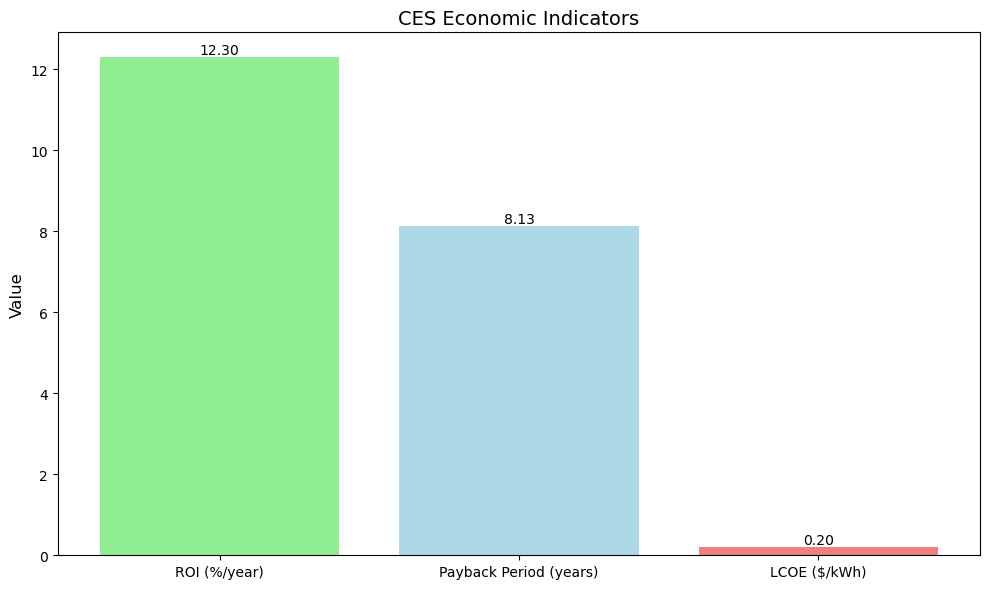


Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $68,792.38
ROI: 12.30%
ROI (Lifetime): 246.06%
Payback Period: 8.13 years
LCOE: $0.2002/kWh


In [ ]:
# Economic Indicators
CES_capacity = 500  # kWh
CES_cost_per_kWh = 400  # $/kWh
CES_initial_cost = 559160.47

# Calculate annual values (assuming 48 half-hour periods = 1 day)
days_per_year = 365
annual_revenue = TNB_revenue_CES * days_per_year

# Calculate economic indicators
ROI = (annual_revenue / CES_initial_cost) * 100  # %
ROI_lifetime = (annual_revenue * 20 / CES_initial_cost) * 100  # %
payback_period = CES_initial_cost / annual_revenue  # years
LCOE = CES_initial_cost / (np.abs(np.sum(CESq[CESq < 0])) * days_per_year * 20)  # $ per kWh over 20 years

# Create figure for economic indicators
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['ROI (%/year)', 'Payback Period (years)', 'LCOE ($/kWh)']
values = [ROI, payback_period, LCOE]
colors = ['lightgreen', 'lightblue', 'lightcoral']

bars = ax.bar(metrics, values, color=colors)
ax.set_ylabel('Value', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_title('CES Economic Indicators', fontsize=14)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom')

plt.tight_layout()
plt.savefig('economic_indicators.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed results
print("Economic Indicators:")
print(f"Initial Investment: ${CES_initial_cost:,.2f}")
print(f"Annual Revenue: ${annual_revenue:,.2f}")
print(f"ROI: {ROI:.2f}%")
print(f"ROI (Lifetime): {ROI_lifetime:.2f}%")
print(f"Payback Period: {payback_period:.2f} years")
print(f"LCOS: ${LCOE:.4f}/kWh")

### Subscription v1

In [3]:
#### Optimal Price Obtained ####
result_loc = 'MOMSA ranked limit subsc4'
result = np.array(pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="Sheet1", header=None))
sol = 0
subs_price = result[sol,0]
capacity_subs = result[sol,1:]

CESq_loc = r"D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\p2p_CES\subs\Charge_Discharge.csv"
CESq = pd.read_csv(CESq_loc, header=None).to_numpy()[:,:-1] 

## DAILY Subscription Cost
pros_CES_cost = subs_price / 30 * capacity_subs
TNB_revenue_CES = np.sum(pros_CES_cost)

subs_price, sum(capacity_subs), TNB_revenue_CES


(np.float64(3.8673869952572875),
 np.float64(557.1064812965174),
 np.float64(71.81821202465665))

In [4]:
result[:5,0]

array([3.867387  , 0.28208699, 0.68047187, 3.89817089, 3.89817089])

In [5]:
# Prosumer Cost Comparison
costN_loc = r"MOMSA_code\Benchmark\p2p_noCES\ProsumerCost_normal tariff.csv"
costP2P_loc = r"MOMSA_code\Benchmark\p2p_noCES\ProsumerCost.csv"
costP2PCES_loc = r"MOMSA_code\Benchmark\p2p_CES\limit\ProsumerCost.csv"

costN = pd.read_csv(costN_loc, header=None).to_numpy()
costP2P = pd.read_csv(costP2P_loc, header=None).to_numpy()
costP2PwoCES = pd.read_csv(costP2PCES_loc, header=None).to_numpy() 
costP2PCES = costP2PwoCES + pros_CES_cost

CSP2P = costN - costP2P
CSP2P_CES = costN - costP2PCES

np.mean(costN), np.mean(costP2P), np.mean(costP2PwoCES), np.mean(costP2PCES)

(np.float64(90.2378125),
 np.float64(74.40875),
 np.float64(70.75),
 np.float64(72.99431912577052))

In [6]:
# TNB revenue
TNBP2P_loc = r"MOMSA_code\Benchmark\p2p_noCES\TNBProfit.csv"
TNBP2PCES_loc = r"MOMSA_code\Benchmark\p2p_CES\subs\TNBProfit.csv"

TNB_normal = np.sum(costN) * 0.15
TNB_P2P = pd.read_csv(TNBP2P_loc, header=None).to_numpy()
TNB_P2PwoCES = pd.read_csv(TNBP2PCES_loc, header=None).to_numpy()
TNB_P2PCES = TNB_P2PwoCES + TNB_revenue_CES

TNB_normal, TNB_P2P, TNB_P2PwoCES, TNB_P2PCES


(np.float64(433.1415),
 array([[1138.35]]),
 array([[1123.53]]),
 array([[1195.34821202]]))

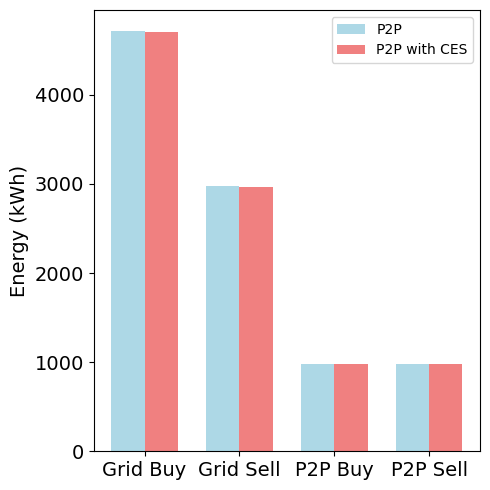

((4716.419999999994, 4708.669999999994),
 (2978.67, 2969.0200000000004),
 (977.0900000000004, 977.0899999999998),
 (977.0500000000005, 977.0499999999996))

In [22]:
# P2P trading amount breakdown
gbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\Grid_buy.csv"
gbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\subs\Grid_buy.csv"
gsell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\Grid_sell.csv"
gsell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\subs\Grid_sell.csv"
pbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\P2P_buy.csv"
pbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\subs\P2P_buy.csv"
psell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\P2P_sell.csv"
psell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\subs\P2P_sell.csv"

gbuy_p2p        = pd.read_csv(gbuy_loc, header=None).to_numpy()[:,:-1]
gbuy_p2p_CES    = pd.read_csv(gbuy_CES_loc, header=None).to_numpy()[:,:-1]
gsell_p2p       = pd.read_csv(gsell_loc, header=None).to_numpy()[:,:-1]
gsell_p2p_CES   = pd.read_csv(gsell_CES_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p        = pd.read_csv(pbuy_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p_CES    = pd.read_csv(pbuy_CES_loc, header=None).to_numpy()[:,:-1]
psell_p2p       = pd.read_csv(psell_loc, header=None).to_numpy()[:,:-1]
psell_p2p_CES   = pd.read_csv(psell_CES_loc, header=None).to_numpy()[:,:-1]

# Calculate total amounts for each category
gbuy_total = np.sum(gbuy_p2p), np.sum(gbuy_p2p_CES)
gsell_total = np.sum(gsell_p2p), np.sum(gsell_p2p_CES)
pbuy_total = np.sum(pbuy_p2p), np.sum(pbuy_p2p_CES)
psell_total = np.sum(psell_p2p), np.sum(psell_p2p_CES)

# Set up the bar chart
fig, ax = plt.subplots(figsize=(5, 5))

# Set position of bar on X axis
x = np.arange(4)
width = 0.35

# Create bars
rects1 = ax.bar(x - width/2, [gbuy_total[0], gsell_total[0], pbuy_total[0], psell_total[0]], 
                width, label='P2P', color='lightblue')
rects2 = ax.bar(x + width/2, [gbuy_total[1], gsell_total[1], pbuy_total[1], psell_total[1]], 
                width, label='P2P with CES', color='lightcoral')

# Customize the plot
ax.set_ylabel('Energy (kWh)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Grid Buy', 'Grid Sell', 'P2P Buy', 'P2P Sell'], fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('p2p_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

gbuy_total, gsell_total, pbuy_total, psell_total

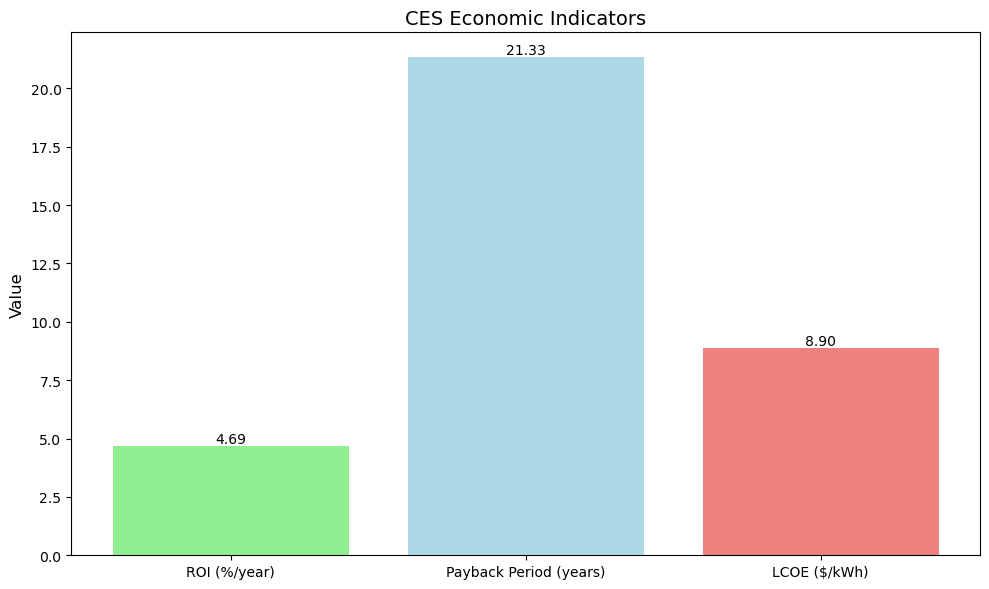


Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $26,213.65
ROI: 4.69%
ROI (Lifetime): 93.76%
Payback Period: 21.33 years
LCOE: $8.8963/kWh


In [8]:
# Economic Indicators
CES_capacity = 500  # kWh
CES_cost_per_kWh = 400  # $/kWh
CES_initial_cost = 559160.47

# Calculate annual values (assuming 48 half-hour periods = 1 day)
days_per_year = 365
annual_revenue = TNB_revenue_CES * days_per_year

# Calculate economic indicators
ROI = (annual_revenue / CES_initial_cost) * 100  # %
ROI_lifetime = (annual_revenue * 20 / CES_initial_cost) * 100  # %
payback_period = CES_initial_cost / annual_revenue  # years
LCOE = CES_initial_cost / (np.abs(np.sum(CESq[CESq < 0])) * days_per_year * 20)  # $ per kWh over 20 years

# Create figure for economic indicators
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['ROI (%/year)', 'Payback Period (years)', 'LCOE ($/kWh)']
values = [ROI, payback_period, LCOE]
colors = ['lightgreen', 'lightblue', 'lightcoral']

bars = ax.bar(metrics, values, color=colors)
ax.set_ylabel('Value', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_title('CES Economic Indicators', fontsize=14)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom')

plt.tight_layout()
plt.savefig('economic_indicators.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed results
print("\nEconomic Indicators:")
print(f"Initial Investment: ${CES_initial_cost:,.2f}")
print(f"Annual Revenue: ${annual_revenue:,.2f}")
print(f"ROI: {ROI:.2f}%")
print(f"ROI (Lifetime): {ROI_lifetime:.2f}%")
print(f"Payback Period: {payback_period:.2f} years")
print(f"LCOE: ${LCOE:.4f}/kWh")

### Subscription v2

In [9]:
#### Optimal Price Obtained ####
result_loc = 'MOMSA ranked limit subsc4 v2'
result = np.array(pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="Sheet1", header=None))
sol = 0
subs_price = result[sol,0]
capacity_subs = result[sol,1:]

CESq_loc = r"D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\p2p_CES\subs\Charge_Discharge.csv"
CESq = pd.read_csv(CESq_loc, header=None).to_numpy()[:,:-1] 

## DAILY Subscription Cost
pros_CES_cost = subs_price / 30 * capacity_subs
TNB_revenue_CES = np.sum(pros_CES_cost)

subs_price, sum(capacity_subs), TNB_revenue_CES


(np.float64(0.6804718738365383),
 np.float64(547.0288885072202),
 np.float64(12.407925760174232))

In [10]:
exe_path = r'"D:\Jacky\Julia-vscode\(Cpp)ADMM_P2P\x64\Release\p2p.exe"'

inputs = result[0,:]
# Convert inputs to space-separated string
input_string = " ".join(map(str, inputs))

# Final CMD command
cmd = f"& {exe_path} {input_string}"

# Print so you can copy-paste into terminal
print(cmd)

& "D:\Jacky\Julia-vscode\(Cpp)ADMM_P2P\x64\Release\p2p.exe" 0.6804718738365383 19.33801495736224 9.808326913007244 17.94271246310227 26.930352158159877 22.4072785105065 13.516374648295677 19.52763706281642 17.420289250990294 23.834674462059475 18.167866641079666 10.087899590538548 14.639351522337089 14.625849010269564 9.992820267126508 28.693501042930176 5.404820538317494 22.449172891801638 12.396368992827052 29.599084067262382 11.984221577888015 11.100259065938289 17.736084847822184 15.341881058195623 13.734351277192143 12.811913143672488 30.515929649781818 23.151713924636894 16.18394022909421 19.066541142556897 14.090680247768946 12.32353789632416 12.205439455558468


In [11]:
result[:5,0]

array([0.68047187, 3.867387  , 0.28208699, 0.8053533 , 0.78524224])

In [12]:
# Prosumer Cost Comparison
costN_loc = r"MOMSA_code\Benchmark\p2p_noCES\ProsumerCost_normal tariff.csv"
costP2P_loc = r"MOMSA_code\Benchmark\p2p_noCES\ProsumerCost.csv"
costP2PCES_loc = r"MOMSA_code\Benchmark\p2p_CES\limit\ProsumerCost.csv"

costN = pd.read_csv(costN_loc, header=None).to_numpy()
costP2P = pd.read_csv(costP2P_loc, header=None).to_numpy()
costP2PwoCES = pd.read_csv(costP2PCES_loc, header=None).to_numpy() 
costP2PCES = costP2PwoCES + pros_CES_cost

CSP2P = costN - costP2P
CSP2P_CES = costN - costP2PCES

np.mean(costN), np.mean(costP2P), np.mean(costP2PwoCES), np.mean(costP2PCES)

(np.float64(90.2378125),
 np.float64(74.40875),
 np.float64(70.75),
 np.float64(71.13774768000545))

In [13]:
# TNB revenue
TNBP2P_loc = r"MOMSA_code\Benchmark\p2p_noCES\TNBProfit.csv"
TNBP2PCES_loc = r"MOMSA_code\Benchmark\p2p_CES\subs\TNBProfit.csv"

TNB_normal = np.sum(costN) * 0.15
TNB_P2P = pd.read_csv(TNBP2P_loc, header=None).to_numpy()
TNB_P2PwoCES = pd.read_csv(TNBP2PCES_loc, header=None).to_numpy()
TNB_P2PCES = TNB_P2PwoCES + TNB_revenue_CES

TNB_normal, TNB_P2P, TNB_P2PwoCES, TNB_P2PCES


(np.float64(433.1415),
 array([[1138.35]]),
 array([[1123.53]]),
 array([[1135.93792576]]))

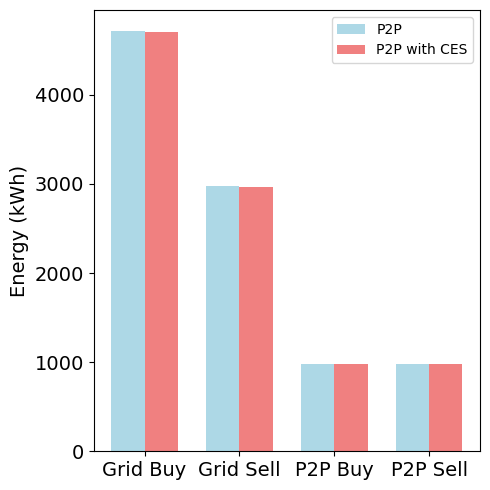

In [14]:
# P2P trading amount breakdown
gbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\Grid_buy.csv"
gbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\subs\Grid_buy.csv"
gsell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\Grid_sell.csv"
gsell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\subs\Grid_sell.csv"
pbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\P2P_buy.csv"
pbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\subs\P2P_buy.csv"
psell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\P2P_sell.csv"
psell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\subs\P2P_sell.csv"

gbuy_p2p        = pd.read_csv(gbuy_loc, header=None).to_numpy()[:,:-1]
gbuy_p2p_CES    = pd.read_csv(gbuy_CES_loc, header=None).to_numpy()[:,:-1]
gsell_p2p       = pd.read_csv(gsell_loc, header=None).to_numpy()[:,:-1]
gsell_p2p_CES   = pd.read_csv(gsell_CES_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p        = pd.read_csv(pbuy_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p_CES    = pd.read_csv(pbuy_CES_loc, header=None).to_numpy()[:,:-1]
psell_p2p       = pd.read_csv(psell_loc, header=None).to_numpy()[:,:-1]
psell_p2p_CES   = pd.read_csv(psell_CES_loc, header=None).to_numpy()[:,:-1]

# Calculate total amounts for each category
gbuy_total = np.sum(gbuy_p2p), np.sum(gbuy_p2p_CES)
gsell_total = np.sum(gsell_p2p), np.sum(gsell_p2p_CES)
pbuy_total = np.sum(pbuy_p2p), np.sum(pbuy_p2p_CES)
psell_total = np.sum(psell_p2p), np.sum(psell_p2p_CES)

# Set up the bar chart
fig, ax = plt.subplots(figsize=(5, 5))

# Set position of bar on X axis
x = np.arange(4)
width = 0.35

# Create bars
rects1 = ax.bar(x - width/2, [gbuy_total[0], gsell_total[0], pbuy_total[0], psell_total[0]], 
                width, label='P2P', color='lightblue')
rects2 = ax.bar(x + width/2, [gbuy_total[1], gsell_total[1], pbuy_total[1], psell_total[1]], 
                width, label='P2P with CES', color='lightcoral')

# Customize the plot
ax.set_ylabel('Energy (kWh)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Grid Buy', 'Grid Sell', 'P2P Buy', 'P2P Sell'], fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('p2p_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

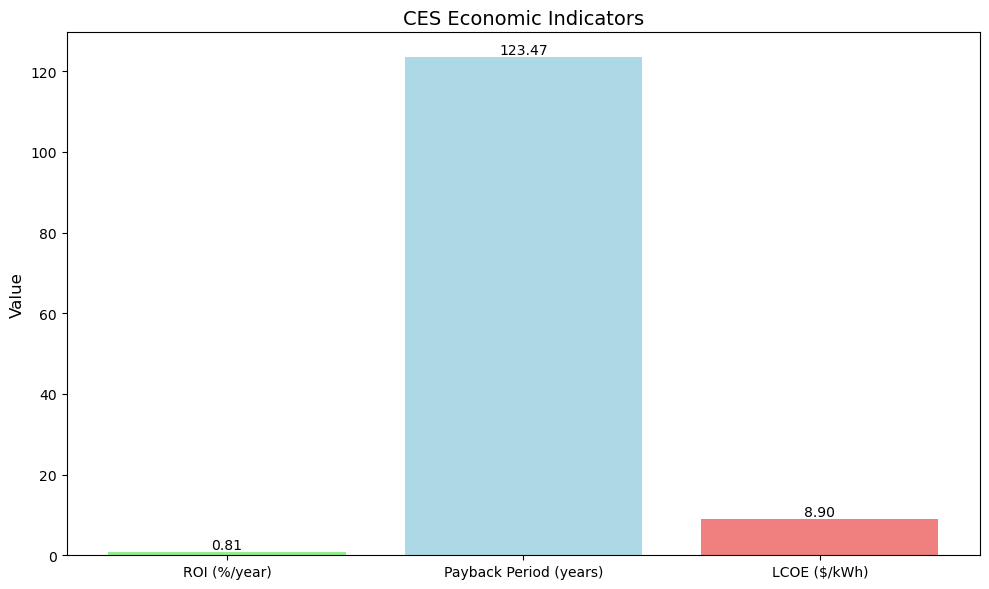


Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $4,528.89
ROI: 0.81%
ROI (Lifetime): 16.20%
Payback Period: 123.47 years
LCOE: $8.8963/kWh


In [15]:
# Economic Indicators
CES_capacity = 500  # kWh
CES_cost_per_kWh = 400  # $/kWh
CES_initial_cost = 559160.47

# Calculate annual values (assuming 48 half-hour periods = 1 day)
days_per_year = 365
annual_revenue = TNB_revenue_CES * days_per_year

# Calculate economic indicators
ROI = (annual_revenue / CES_initial_cost) * 100  # %
ROI_lifetime = (annual_revenue * 20 / CES_initial_cost) * 100  # %
payback_period = CES_initial_cost / annual_revenue  # years
LCOE = CES_initial_cost / (np.abs(np.sum(CESq[CESq < 0])) * days_per_year * 20)  # $ per kWh over 20 years

# Create figure for economic indicators
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['ROI (%/year)', 'Payback Period (years)', 'LCOE ($/kWh)']
values = [ROI, payback_period, LCOE]
colors = ['lightgreen', 'lightblue', 'lightcoral']

bars = ax.bar(metrics, values, color=colors)
ax.set_ylabel('Value', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_title('CES Economic Indicators', fontsize=14)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom')

plt.tight_layout()
plt.savefig('economic_indicators.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed results
print("\nEconomic Indicators:")
print(f"Initial Investment: ${CES_initial_cost:,.2f}")
print(f"Annual Revenue: ${annual_revenue:,.2f}")
print(f"ROI: {ROI:.2f}%")
print(f"ROI (Lifetime): {ROI_lifetime:.2f}%")
print(f"Payback Period: {payback_period:.2f} years")
print(f"LCOE: ${LCOE:.4f}/kWh")

### Subscription v3

In [3]:
#### Optimal Price Obtained ####
result_loc = 'MOMSA ranked unlimit subsc v3 1'
result = np.array(pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="Sheet1", header=None))
sol = 0
subs_price = result[sol,0]
capacity_subs = result[sol,1:]

CESq_loc = r"D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\p2p_CES\subs v3\Charge_Discharge.csv"
CESq = pd.read_csv(CESq_loc, header=None).to_numpy()[:,:-1] 

## DAILY Subscription Cost
pros_CES_cost = subs_price / 30 * capacity_subs
TNB_revenue_CES = np.sum(pros_CES_cost)

subs_price, sum(capacity_subs), TNB_revenue_CES


(np.float64(9.916959897313795),
 np.float64(558.696485072664),
 np.float64(184.68568790785952))

In [4]:
exe_path = r'"D:\Jacky\Julia-vscode\(Cpp)ADMM_P2P\x64\Release\p2p.exe"'

inputs = result[0,:]
inputs[0] = 1 - inputs[0] / 10
# Convert inputs to space-separated string
input_string = " ".join(map(str, inputs))

# Final CMD command
cmd = f"& {exe_path} {input_string}"

# Print so you can copy-paste into terminal
print(cmd)

& "D:\Jacky\Julia-vscode\(Cpp)ADMM_P2P\x64\Release\p2p.exe" 0.008304010268620488 25.331745349582533 28.074360183587935 23.139081772570986 16.04778672907373 7.1798425264950065 26.40449099609369 10.168537194527161 24.70952899915756 12.730069842194675 24.311886598429236 2.2548822733954332 26.976696622977283 2.5708796243145904 23.21243878576352 9.002770047275055 17.214139540814152 21.435318965319265 22.7308252505601 15.720988605930692 7.819139111119871 23.179684958401335 13.115989139992852 25.913987615628397 16.685532052238425 22.405758191667175 4.681224118541429 18.351190094961993 20.779175950776114 19.357421499801355 10.678144263864342 8.45496705315865 28.058001114449585


In [14]:
total_cap = 283.52 + 275.64

print('Subscription Price                        : $', format(subs_price, '.2f'))
print(f'Total Capacity, Subscribed Capacity       : {total_cap:.2f}, {sum(capacity_subs):.2f} kWh ({sum(capacity_subs) / total_cap * 100:.2f}% utilization)')
print('TNB Revenue from CES                      : $', format(TNB_revenue_CES, '.2f'))
print('CES cost for prosumer (Avg)               : $', format(np.mean(pros_CES_cost), '.2f'))

Subscription Price                        : $ 9.92
Total Capacity, Subscribed Capacity       : 559.16, 558.70 kWh (99.92% utilization)
TNB Revenue from CES                      : $ 184.69
CES cost for prosumer (Avg)               : $ 5.77


In [6]:
# Prosumer Cost Comparison
costN_loc = r"MOMSA_code\Benchmark\p2p_noCES\ProsumerCost_normal tariff.csv"
costP2P_loc = r"MOMSA_code\Benchmark\p2p_noCES\ProsumerCost.csv"
costP2PCES_loc = r"MOMSA_code\Benchmark\p2p_CES\limit\ProsumerCost.csv"

costN = pd.read_csv(costN_loc, header=None).to_numpy()
costP2P = pd.read_csv(costP2P_loc, header=None).to_numpy()
costP2PwoCES = pd.read_csv(costP2PCES_loc, header=None).to_numpy() # with CES but not costing user
costP2PCES = costP2PwoCES + pros_CES_cost

CSP2P = costN - costP2P
CSP2P_CES = costN - costP2PCES

np.mean(costN), np.mean(costP2P), np.mean(costP2PwoCES), np.mean(costP2PCES)

(np.float64(90.2378125),
 np.float64(74.40875),
 np.float64(70.75),
 np.float64(76.52142774712061))

In [7]:
# TNB revenue
TNBP2P_loc = r"MOMSA_code\Benchmark\p2p_noCES\TNBProfit.csv"
TNBP2PCES_loc = r"MOMSA_code\Benchmark\p2p_CES\subs\TNBProfit.csv"

TNB_normal = np.sum(costN) * 0.15
TNB_P2P = pd.read_csv(TNBP2P_loc, header=None).to_numpy()
TNB_P2PwoCES = pd.read_csv(TNBP2PCES_loc, header=None).to_numpy()
TNB_P2PCES = TNB_P2PwoCES + TNB_revenue_CES

TNB_normal, TNB_P2P, TNB_P2PwoCES, TNB_P2PCES


(np.float64(433.1415),
 array([[1138.35]]),
 array([[1123.53]]),
 array([[1308.21568791]]))

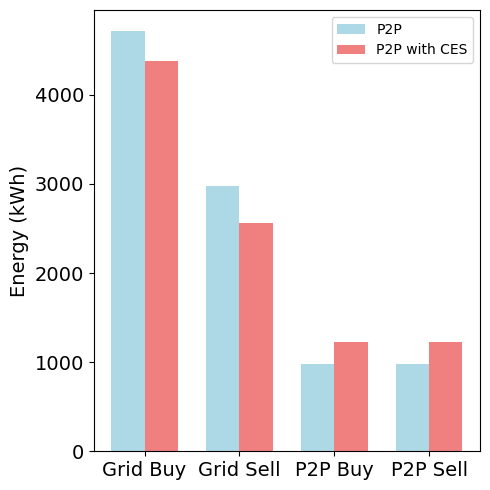

((4716.419999999994, 4385.3599999999915),
 (2978.67, 2560.300000000001),
 (977.0900000000004, 1230.7800000000002),
 (977.0500000000005, 1230.7900000000002))

In [8]:
# P2P trading amount breakdown
gbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\Grid_buy.csv"
gbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\subs v3\Grid_buy.csv"
gsell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\Grid_sell.csv"
gsell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\subs v3\Grid_sell.csv"
pbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\P2P_buy.csv"
pbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\subs v3\P2P_buy.csv"
psell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\P2P_sell.csv"
psell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\subs v3\P2P_sell.csv"
ces_lv_loc      = r"MOMSA_code\Benchmark\p2p_CES\subs v3\Battery_Level_CES.csv"

gbuy_p2p        = pd.read_csv(gbuy_loc, header=None).to_numpy()[:,:-1]
gbuy_p2p_CES    = pd.read_csv(gbuy_CES_loc, header=None).to_numpy()[:,:-1]
gsell_p2p       = pd.read_csv(gsell_loc, header=None).to_numpy()[:,:-1]
gsell_p2p_CES   = pd.read_csv(gsell_CES_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p        = pd.read_csv(pbuy_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p_CES    = pd.read_csv(pbuy_CES_loc, header=None).to_numpy()[:,:-1]
psell_p2p       = pd.read_csv(psell_loc, header=None).to_numpy()[:,:-1]
psell_p2p_CES   = pd.read_csv(psell_CES_loc, header=None).to_numpy()[:,:-1]
ces_lv_grid     = pd.read_csv(ces_lv_loc, header=None).to_numpy()[:,:-1]

# Calculate total amounts for each category
gbuy_total = np.sum(gbuy_p2p), np.sum(gbuy_p2p_CES)
gsell_total = np.sum(gsell_p2p), np.sum(gsell_p2p_CES)
pbuy_total = np.sum(pbuy_p2p), np.sum(pbuy_p2p_CES)
psell_total = np.sum(psell_p2p), np.sum(psell_p2p_CES)

# Set up the bar chart
fig, ax = plt.subplots(figsize=(5, 5))

# Set position of bar on X axis
x = np.arange(4)
width = 0.35

# Create bars
rects1 = ax.bar(x - width/2, [gbuy_total[0], gsell_total[0], pbuy_total[0], psell_total[0]], 
                width, label='P2P', color='lightblue')
rects2 = ax.bar(x + width/2, [gbuy_total[1], gsell_total[1], pbuy_total[1], psell_total[1]], 
                width, label='P2P with CES', color='lightcoral')

# Customize the plot
ax.set_ylabel('Energy (kWh)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Grid Buy', 'Grid Sell', 'P2P Buy', 'P2P Sell'], fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('p2p_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

gbuy_total, gsell_total, pbuy_total, psell_total

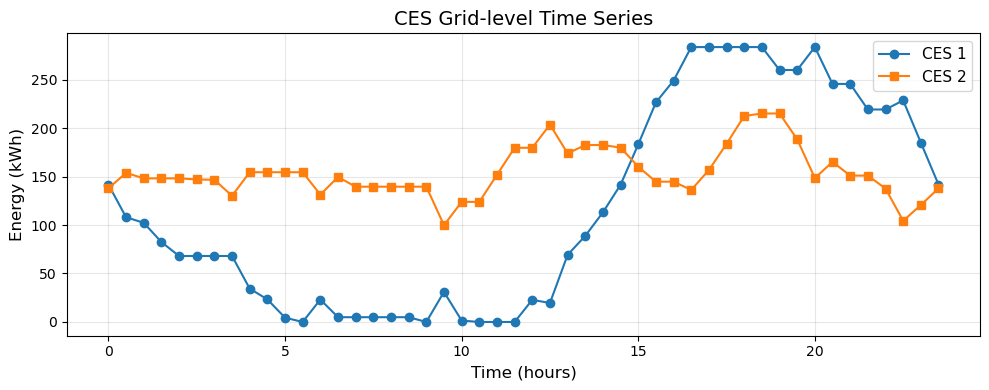

In [9]:
# Basic time axis (half-hour steps 0..47) or convert to hours with /2
t = np.arange(ces_lv_grid.shape[0])         # 0..47
t_hours = t / 2.0                           # optional: convert to hours

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_hours, ces_lv_grid[:, 0], marker='o', lw=1.5, label='CES 1', color='tab:blue')
ax.plot(t_hours, ces_lv_grid[:, 1], marker='s', lw=1.5, label='CES 2', color='tab:orange')

ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Energy (kWh)', fontsize=12)
ax.set_title('CES Grid-level Time Series', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ces_lv_grid_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

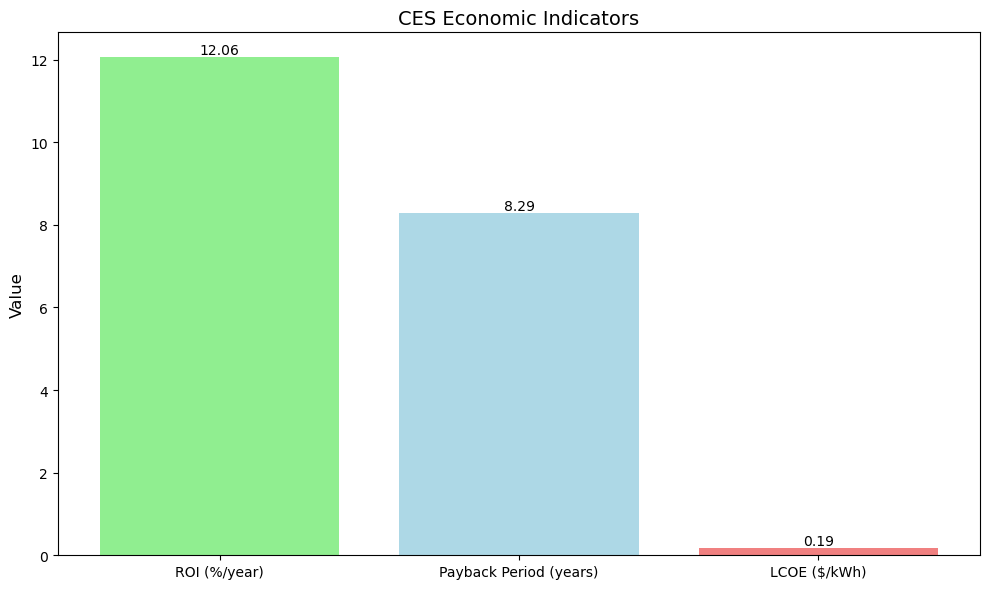


Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $67,410.28
ROI: 12.06%
ROI (Lifetime): 241.11%
Payback Period: 8.29 years
LCOE: $0.1863/kWh


In [10]:
# Economic Indicators
CES_capacity = 500  # kWh
CES_cost_per_kWh = 400  # $/kWh
CES_initial_cost = 559160.47

# Calculate annual values (assuming 48 half-hour periods = 1 day)
days_per_year = 365
annual_revenue = TNB_revenue_CES * days_per_year

# Calculate economic indicators
ROI = (annual_revenue / CES_initial_cost) * 100  # %
ROI_lifetime = (annual_revenue * 20 / CES_initial_cost) * 100  # %
payback_period = CES_initial_cost / annual_revenue  # years
LCOE = CES_initial_cost / (np.abs(np.sum(CESq[CESq < 0])) * days_per_year * 20)  # $ per kWh over 20 years

# Create figure for economic indicators
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['ROI (%/year)', 'Payback Period (years)', 'LCOE ($/kWh)']
values = [ROI, payback_period, LCOE]
colors = ['lightgreen', 'lightblue', 'lightcoral']

bars = ax.bar(metrics, values, color=colors)
ax.set_ylabel('Value', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_title('CES Economic Indicators', fontsize=14)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom')

plt.tight_layout()
plt.savefig('economic_indicators.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed results
print("\nEconomic Indicators:")
print(f"Initial Investment: ${CES_initial_cost:,.2f}")
print(f"Annual Revenue: ${annual_revenue:,.2f}")
print(f"ROI: {ROI:.2f}%")
print(f"ROI (Lifetime): {ROI_lifetime:.2f}%")
print(f"Payback Period: {payback_period:.2f} years")
print(f"LCOE: ${LCOE:.4f}/kWh")

### Subscription v4

In [12]:
#### Optimal Price Obtained ####
result_loc = 'MOMSA ranked unlimit subsc v4 1'
result = np.array(pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="Sheet1", header=None))
sol = 0
subs_price = result[sol,0]
capacity_subs = result[sol,1:]

CESq_loc = r"D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\p2p_CES\subs v4\Charge_Discharge.csv"
CESq = pd.read_csv(CESq_loc, header=None).to_numpy()[:,:-1] 

## DAILY Subscription Cost
pros_CES_cost = subs_price / 30 * capacity_subs
TNB_revenue_CES = np.sum(pros_CES_cost)

subs_price, sum(capacity_subs), TNB_revenue_CES


(np.float64(9.939059056942458),
 np.float64(557.1289515654069),
 np.float64(184.57791839803377))

In [13]:
exe_path = r'"D:\Jacky\Julia-vscode\(Cpp)ADMM_P2P\x64\Release\p2p.exe"'

inputs = result[0,:]
inputs[0] = 1 - inputs[0] / 10
# Convert inputs to space-separated string
input_string = " ".join(map(str, inputs))

# Final CMD command
cmd = f"& {exe_path} {input_string}"

# Print so you can copy-paste into terminal
print(cmd)

& "D:\Jacky\Julia-vscode\(Cpp)ADMM_P2P\x64\Release\p2p.exe" 0.006094094305754139 16.497328855236752 14.4427642690385 18.64019012921471 18.847753861140774 13.523727958292767 32.867175808859045 12.58584154049569 12.416295726757866 17.004869178447397 16.65759030816612 12.838823601538255 28.859396799146925 4.567813957153308 20.59060443995953 11.107582458542979 6.607516908431171 12.496381581279 30.03627372294819 20.507391903672524 24.289490601658404 18.467922105904197 8.578649165184752 28.222981077987498 27.349764254694456 17.982844630589845 19.345515057617526 13.503196643327342 19.558204290342633 7.065249196468807 12.344275698083766 27.42584478053221 11.899691054693944


In [14]:
total_cap = 283.52 + 275.64

print('Subscription Price                        : $', format(subs_price, '.2f'))
print(f'Total Capacity, Subscribed Capacity       : {total_cap:.2f}, {sum(capacity_subs):.2f} kWh ({sum(capacity_subs) / total_cap * 100:.2f}% utilization)')
print('TNB Revenue from CES                      : $', format(TNB_revenue_CES, '.2f'))
print('CES cost for prosumer (Avg)               : $', format(np.mean(pros_CES_cost), '.2f'))

Subscription Price                        : $ 9.94
Total Capacity, Subscribed Capacity       : 559.16, 557.13 kWh (99.64% utilization)
TNB Revenue from CES                      : $ 184.58
CES cost for prosumer (Avg)               : $ 5.77


In [15]:
# Prosumer Cost Comparison
costN_loc = r"MOMSA_code\Benchmark\p2p_noCES\ProsumerCost_normal tariff.csv"
costP2P_loc = r"MOMSA_code\Benchmark\p2p_noCES\ProsumerCost.csv"
costP2PCES_loc = r"MOMSA_code\Benchmark\p2p_CES\limit\ProsumerCost.csv"

costN = pd.read_csv(costN_loc, header=None).to_numpy()
costP2P = pd.read_csv(costP2P_loc, header=None).to_numpy()
costP2PwoCES = pd.read_csv(costP2PCES_loc, header=None).to_numpy() # with CES but not costing user
costP2PCES = costP2PwoCES + pros_CES_cost

CSP2P = costN - costP2P
CSP2P_CES = costN - costP2PCES

np.mean(costN), np.mean(costP2P), np.mean(costP2PwoCES), np.mean(costP2PCES)

(np.float64(90.2378125),
 np.float64(74.40875),
 np.float64(70.75),
 np.float64(76.51805994993855))

In [16]:
# TNB revenue
TNBP2P_loc = r"MOMSA_code\Benchmark\p2p_noCES\TNBProfit.csv"
TNBP2PCES_loc = r"MOMSA_code\Benchmark\p2p_CES\subs\TNBProfit.csv"

TNB_normal = np.sum(costN) * 0.15
TNB_P2P = pd.read_csv(TNBP2P_loc, header=None).to_numpy()
TNB_P2PwoCES = pd.read_csv(TNBP2PCES_loc, header=None).to_numpy()
TNB_P2PCES = TNB_P2PwoCES + TNB_revenue_CES

TNB_normal, TNB_P2P, TNB_P2PwoCES, TNB_P2PCES


(np.float64(433.1415),
 array([[1138.35]]),
 array([[1123.53]]),
 array([[1308.1079184]]))

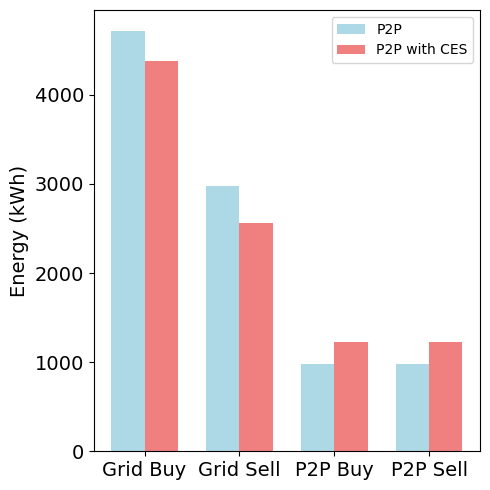

((4716.419999999994, 4385.3599999999915),
 (2978.67, 2560.300000000001),
 (977.0900000000004, 1230.7800000000002),
 (977.0500000000005, 1230.7900000000002))

In [17]:
# P2P trading amount breakdown
gbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\Grid_buy.csv"
gbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\subs v3\Grid_buy.csv"
gsell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\Grid_sell.csv"
gsell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\subs v3\Grid_sell.csv"
pbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\P2P_buy.csv"
pbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\subs v3\P2P_buy.csv"
psell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\P2P_sell.csv"
psell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\subs v3\P2P_sell.csv"
ces_lv_loc      = r"MOMSA_code\Benchmark\p2p_CES\subs v3\Battery_Level_CES.csv"

gbuy_p2p        = pd.read_csv(gbuy_loc, header=None).to_numpy()[:,:-1]
gbuy_p2p_CES    = pd.read_csv(gbuy_CES_loc, header=None).to_numpy()[:,:-1]
gsell_p2p       = pd.read_csv(gsell_loc, header=None).to_numpy()[:,:-1]
gsell_p2p_CES   = pd.read_csv(gsell_CES_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p        = pd.read_csv(pbuy_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p_CES    = pd.read_csv(pbuy_CES_loc, header=None).to_numpy()[:,:-1]
psell_p2p       = pd.read_csv(psell_loc, header=None).to_numpy()[:,:-1]
psell_p2p_CES   = pd.read_csv(psell_CES_loc, header=None).to_numpy()[:,:-1]
ces_lv_grid     = pd.read_csv(ces_lv_loc, header=None).to_numpy()[:,:-1]

# Calculate total amounts for each category
gbuy_total = np.sum(gbuy_p2p), np.sum(gbuy_p2p_CES)
gsell_total = np.sum(gsell_p2p), np.sum(gsell_p2p_CES)
pbuy_total = np.sum(pbuy_p2p), np.sum(pbuy_p2p_CES)
psell_total = np.sum(psell_p2p), np.sum(psell_p2p_CES)

# Set up the bar chart
fig, ax = plt.subplots(figsize=(5, 5))

# Set position of bar on X axis
x = np.arange(4)
width = 0.35

# Create bars
rects1 = ax.bar(x - width/2, [gbuy_total[0], gsell_total[0], pbuy_total[0], psell_total[0]], 
                width, label='P2P', color='lightblue')
rects2 = ax.bar(x + width/2, [gbuy_total[1], gsell_total[1], pbuy_total[1], psell_total[1]], 
                width, label='P2P with CES', color='lightcoral')

# Customize the plot
ax.set_ylabel('Energy (kWh)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Grid Buy', 'Grid Sell', 'P2P Buy', 'P2P Sell'], fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('p2p_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

gbuy_total, gsell_total, pbuy_total, psell_total

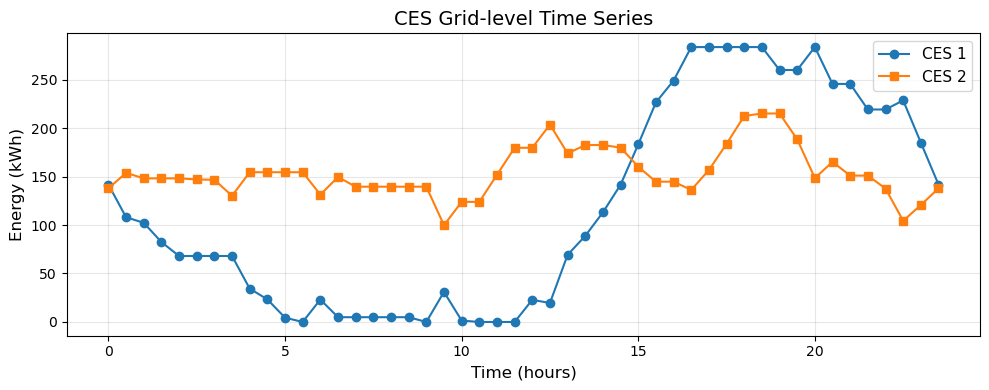

In [18]:
# Basic time axis (half-hour steps 0..47) or convert to hours with /2
t = np.arange(ces_lv_grid.shape[0])         # 0..47
t_hours = t / 2.0                           # optional: convert to hours

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_hours, ces_lv_grid[:, 0], marker='o', lw=1.5, label='CES 1', color='tab:blue')
ax.plot(t_hours, ces_lv_grid[:, 1], marker='s', lw=1.5, label='CES 2', color='tab:orange')

ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Energy (kWh)', fontsize=12)
ax.set_title('CES Grid-level Time Series', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ces_lv_grid_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

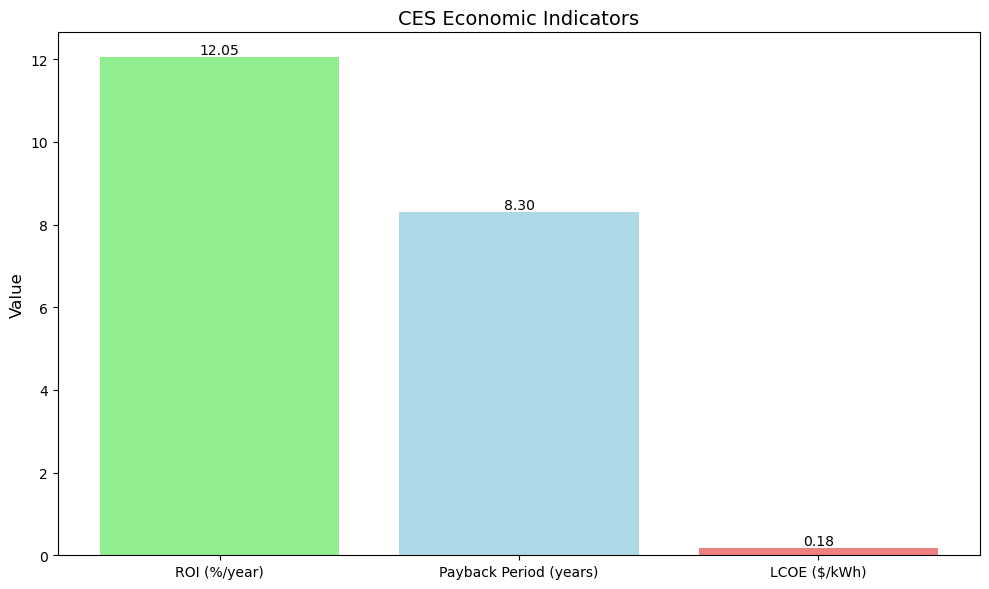


Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $67,370.94
ROI: 12.05%
ROI (Lifetime): 240.97%
Payback Period: 8.30 years
LCOE: $0.1823/kWh


In [19]:
# Economic Indicators
CES_capacity = 500  # kWh
CES_cost_per_kWh = 400  # $/kWh
CES_initial_cost = 559160.47

# Calculate annual values (assuming 48 half-hour periods = 1 day)
days_per_year = 365
annual_revenue = TNB_revenue_CES * days_per_year

# Calculate economic indicators
ROI = (annual_revenue / CES_initial_cost) * 100  # %
ROI_lifetime = (annual_revenue * 20 / CES_initial_cost) * 100  # %
payback_period = CES_initial_cost / annual_revenue  # years
LCOE = CES_initial_cost / (np.abs(np.sum(CESq[CESq < 0])) * days_per_year * 20)  # $ per kWh over 20 years

# Create figure for economic indicators
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['ROI (%/year)', 'Payback Period (years)', 'LCOE ($/kWh)']
values = [ROI, payback_period, LCOE]
colors = ['lightgreen', 'lightblue', 'lightcoral']

bars = ax.bar(metrics, values, color=colors)
ax.set_ylabel('Value', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_title('CES Economic Indicators', fontsize=14)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom')

plt.tight_layout()
plt.savefig('economic_indicators.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed results
print("\nEconomic Indicators:")
print(f"Initial Investment: ${CES_initial_cost:,.2f}")
print(f"Annual Revenue: ${annual_revenue:,.2f}")
print(f"ROI: {ROI:.2f}%")
print(f"ROI (Lifetime): {ROI_lifetime:.2f}%")
print(f"Payback Period: {payback_period:.2f} years")
print(f"LCOE: ${LCOE:.4f}/kWh")

# Subscription basis limited

In [3]:
result_loc = "momsa_full_log (subs unrank limit)4"
non_dom_result_loc = "MOMSA unrank limit subsc4"

position_df = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="all_X", header=None)
position_df_non_dom = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{non_dom_result_loc}.xlsx", sheet_name="Sheet1", header=None)

## (-TNB_revenue_CESs, EFCs, costP)
obj_df = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="all_F", header=None)   
obj_df_non_dom = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{non_dom_result_loc}.xlsx", sheet_name="Sheet2", header=None)

In [4]:
obj, position = obj_proc(obj_df, position_df)
obj_non_dom, position_non_dom = obj_proc(obj_df_non_dom, position_df_non_dom)

In [ ]:
## Ranges of prices (before, after filtering infeasible solutions)
[np.array(position_df)[:,0].min(), np.array(position_df)[:,0].max()], [np.array(position_df_non_dom)[:,0].min(), np.array(position_df_non_dom)[:,0].max()]

([0.010142023320835528, 9.991293378500629],
 [0.1788510574544336, 4.0332617247892415])

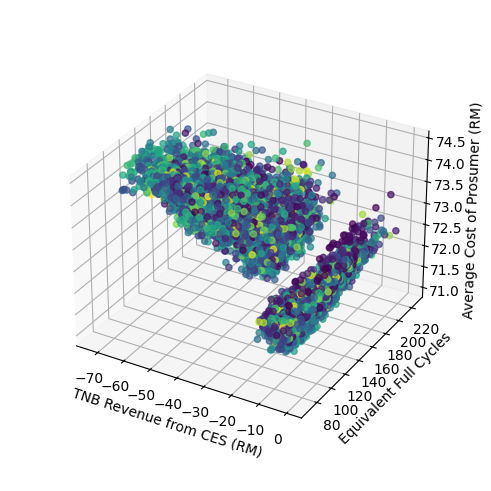

In [6]:
obj_array, position_array = obj_proc(obj_df, position_df, df=False)

from mpl_toolkits.mplot3d import Axes3D
fontttt = 10
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(obj_array[:,0], obj_array[:,1], obj_array[:,2], c=position_array[:,1], cmap='viridis', alpha=0.7)
ax.set_xlabel('TNB Revenue from CES (RM)', fontsize=fontttt)
ax.set_ylabel('Equivalent Full Cycles', fontsize=fontttt)
ax.set_zlabel('Average Cost of Prosumer (RM)', fontsize=fontttt)
# ax.set_title('Pareto Front in Objective Space', fontsize=14)
ax.set_box_aspect(aspect=None, zoom=0.85)
plt.savefig(f"test.png", format = "png", bbox_inches='tight', dpi = 300)
plt.show()



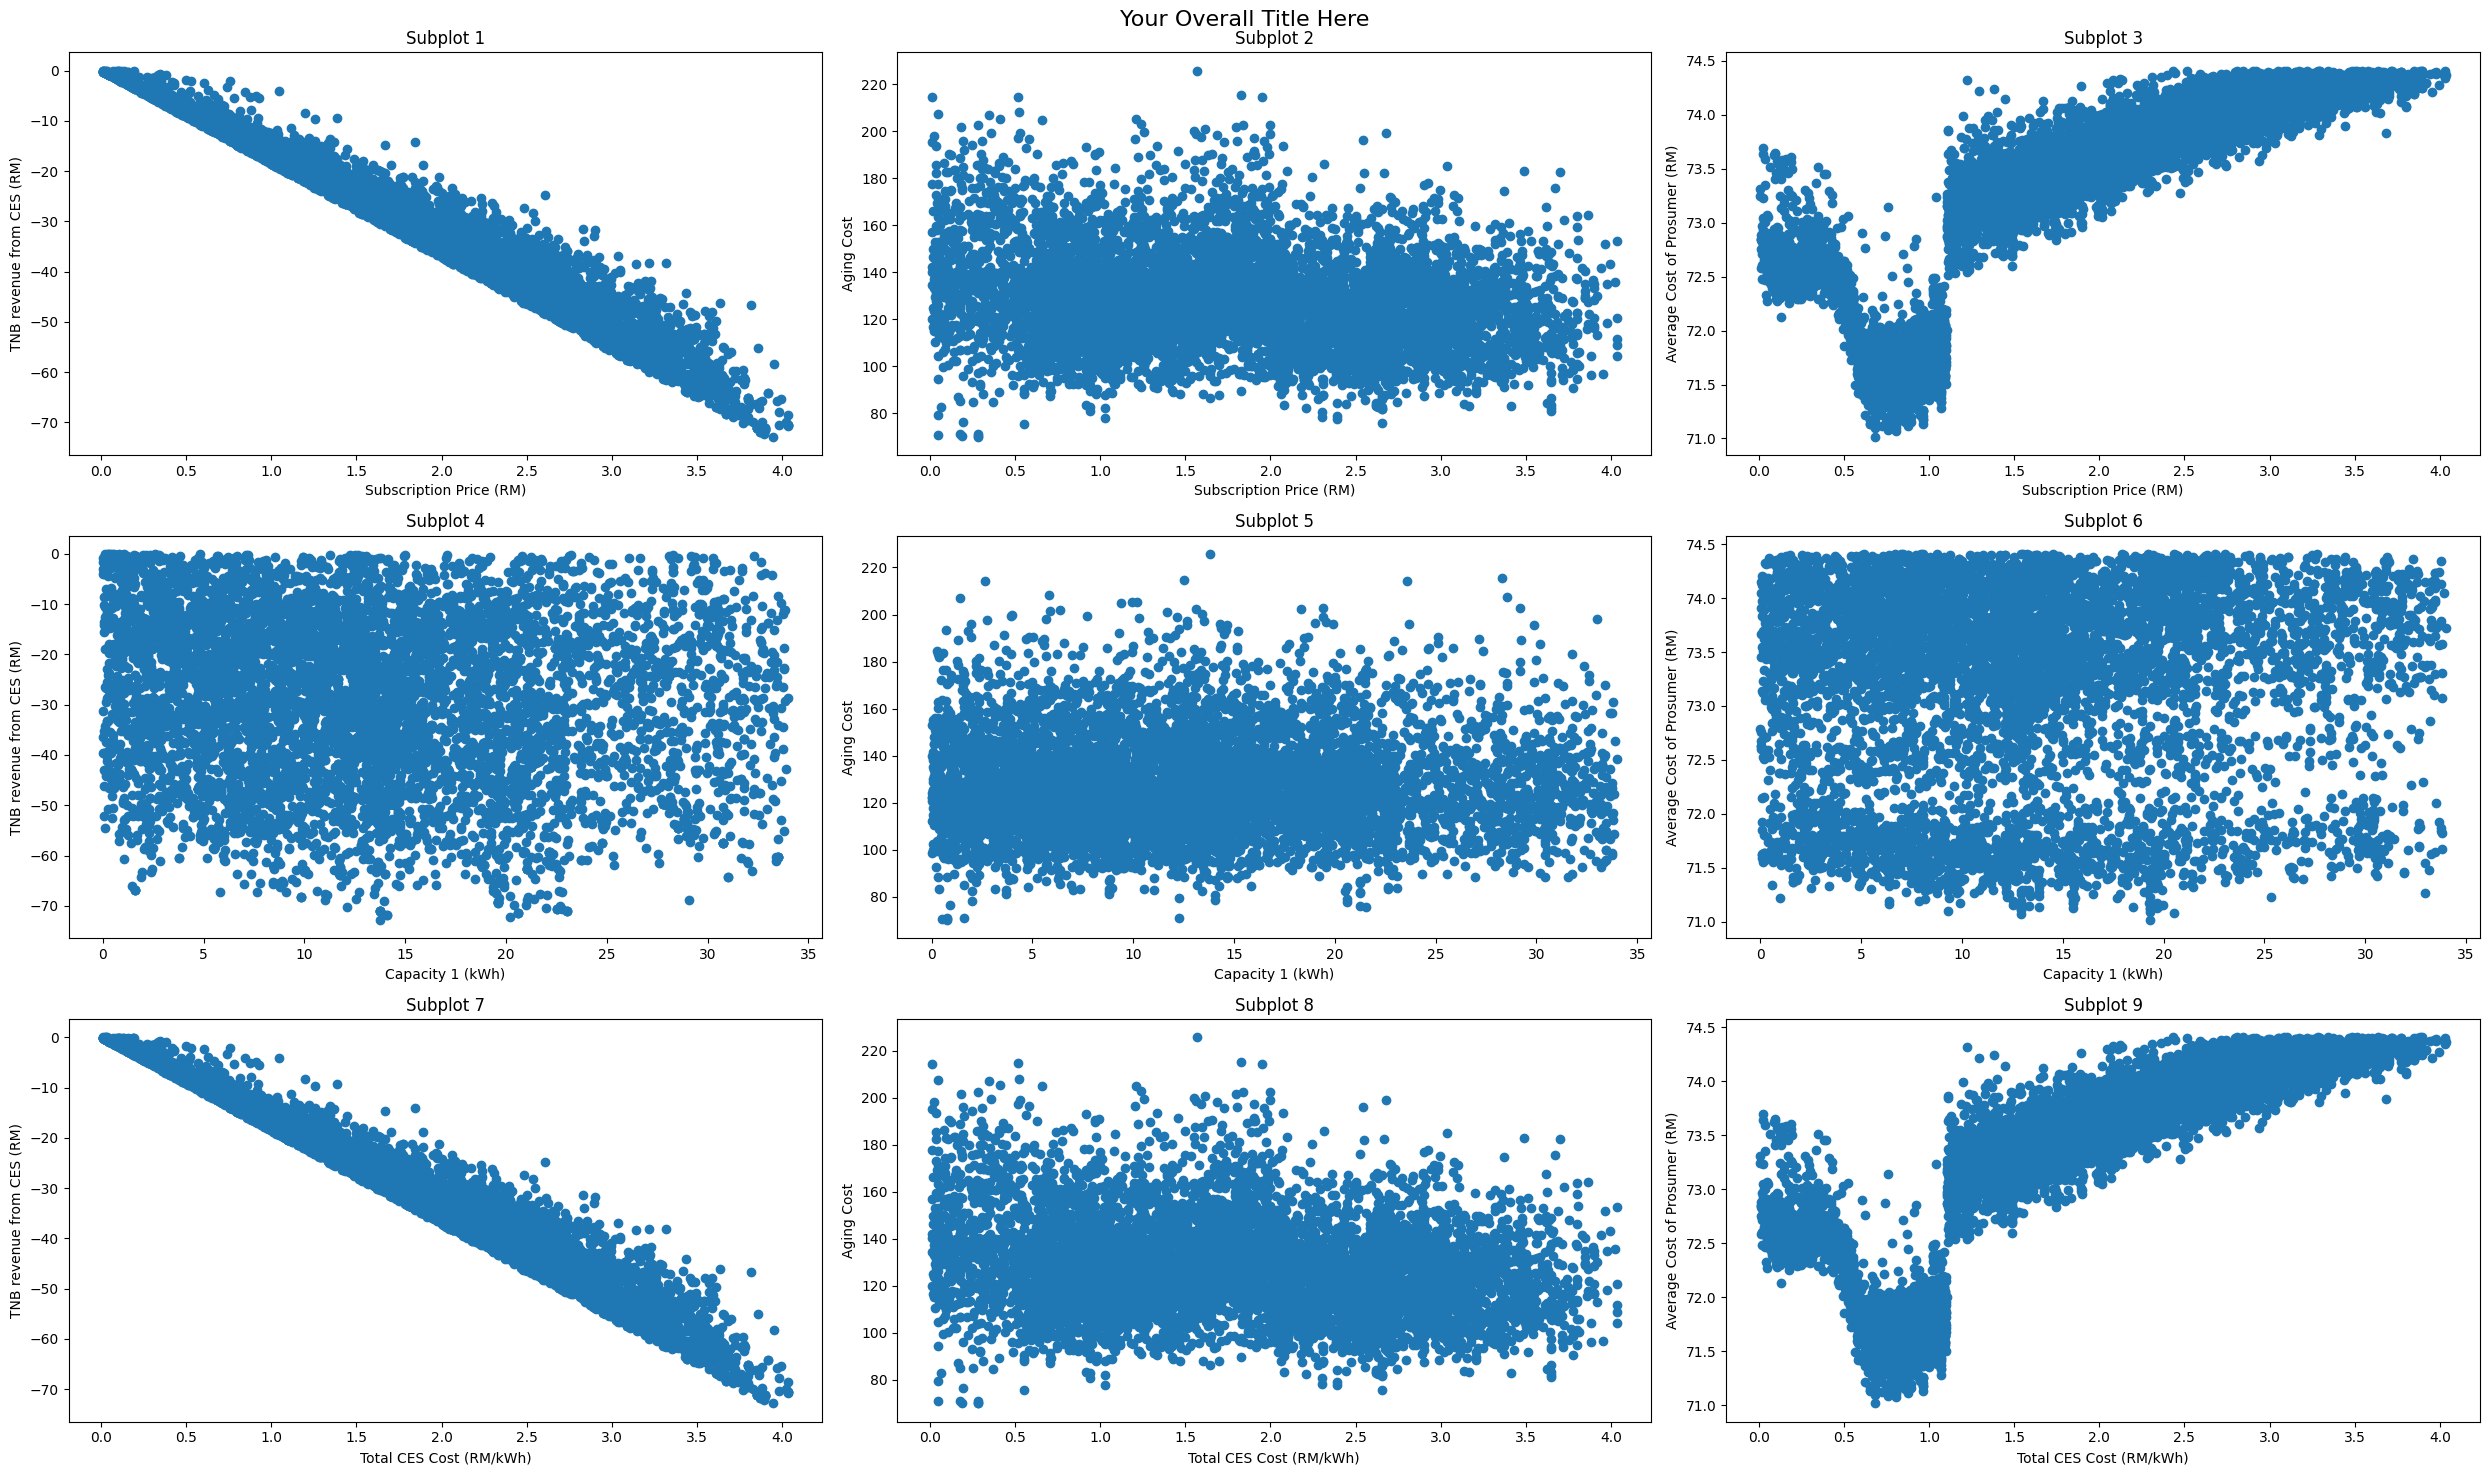

In [7]:
obj_non_dom_array, position_non_dom_array = obj_proc(obj_df, position_df, df=False)

# Create figure and subplots
fig, axs = plt.subplots(3, 3, figsize=(25, 15))
fig.suptitle('Your Overall Title Here', fontsize=16)

# Flatten axs array for easier iteration if needed
axs = axs.flatten()

# Example for each subplot
for i in range(9):
    if i < 6:
        # Here you can customize each subplot
        axs[i].set_xlabel(position_non_dom.columns[0 if i < 3 else 1])
        axs[i].set_ylabel(obj_non_dom.columns[i % 3])
        axs[i].set_title(f'Subplot {i+1}')
        
        # Add your plotting commands here for each subplot
        # Example: axs[i].plot(x, y)
        # Example: axs[i].scatter(x, y)
        axs[i].plot(position_non_dom_array[:, 0 if i < 3 else 1], obj_non_dom_array[:, i % 3], 'o')
    else:
        axs[i].set_xlabel('Total CES Cost (RM/kWh)')
        axs[i].set_ylabel(obj_non_dom.columns[(i - 6) % 3])
        axs[i].set_title(f'Subplot {i+1}')

        total_ces_cost = position_non_dom_array[:, 0]
        axs[i].plot(total_ces_cost, obj_non_dom_array[:, (i - 6) % 3], 'o')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

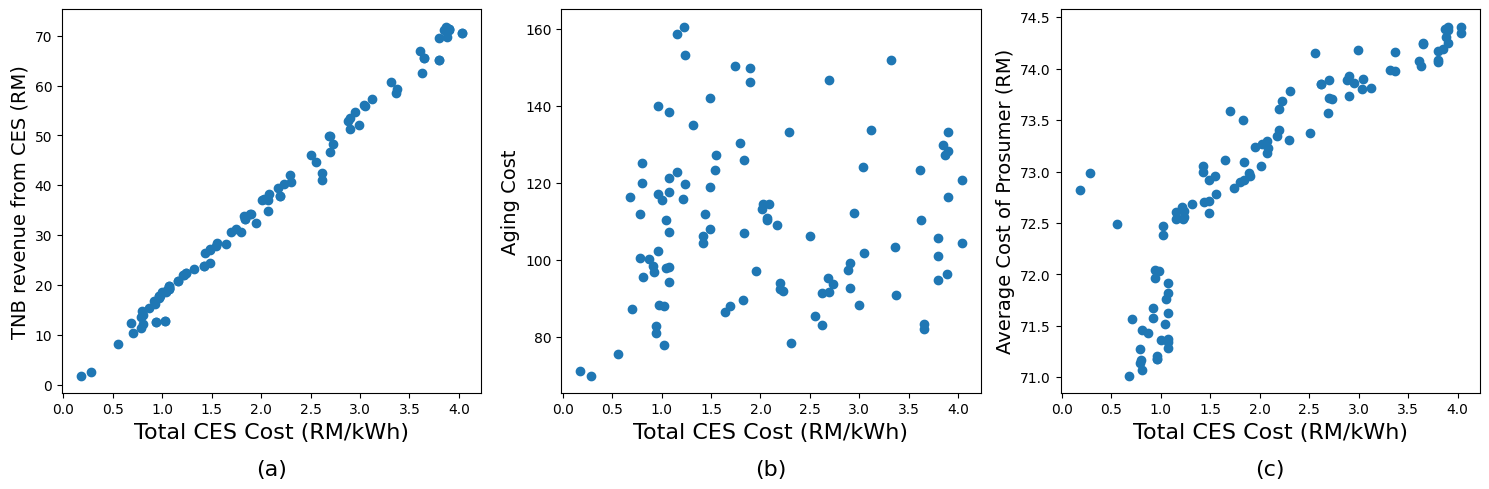

In [8]:
obj_non_dom_array, position_non_dom_array = obj_proc(obj_df_non_dom, position_df_non_dom, df=False)

# Create figure and subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
# fig.suptitle('Your Overall Title Here', fontsize=16)

# Flatten axs array for easier iteration if needed
axs = axs.flatten()
plot_title = ['(a)', '(b)', '(c)']

# Example for each subplot
for i in range(3):
    k = i
    # if i < 6:
    #     # Here you can customize each subplot
    #     axs[i].set_xlabel(position_non_dom.columns[0 if i < 3 else 1])
    #     axs[i].set_ylabel(obj_non_dom.columns[i % 3])
    #     axs[i].set_title(f'Subplot {i+1}')
        
    #     # Add your plotting commands here for each subplot
    #     # Example: axs[i].plot(x, y)
    #     # Example: axs[i].scatter(x, y)
    #     axs[i].plot(position_non_dom_array[:, 0 if i < 3 else 1], obj_non_dom_array[:, i % 3], 'o')
    # else:
        # k = i - 6
    axs[i].set_xlabel('Total CES Cost (RM/kWh)', fontsize =16)
    axs[i].set_ylabel(obj_non_dom.columns[(k) % 3], fontsize=14)
    axs[i].set_title(plot_title[i], y=-0.25, pad=10, fontsize=16)

    total_ces_cost = position_non_dom_array[:, 0]
    axs[i].plot(total_ces_cost, obj_non_dom_array[:, (k) % 3], 'o')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.savefig(f"ROI_dec_vs_obj.png", format = "png", bbox_inches='tight', dpi = 300)
plt.show()

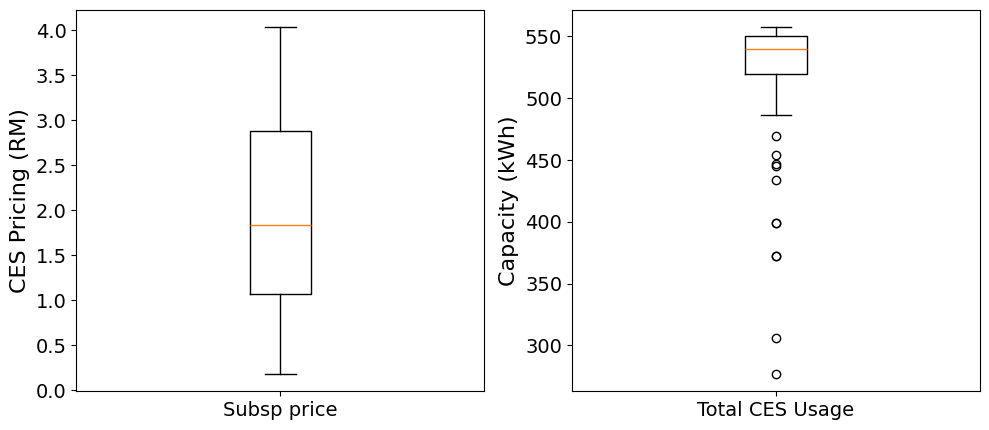

In [10]:
# Create the box plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Execution Time box plot
ax[0].boxplot([position_non_dom_array[:,0]], labels=['Subsp price'])
# ax.set_xlabel('CES Pricing (RM)', fontsize=16)
ax[0].set_ylabel('CES Pricing (RM)', fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=14)

# Execution Time box plot
ax[1].boxplot([np.sum(position_non_dom_array[:,1:], axis=1)], labels=['Total CES Usage'])
# ax.set_xlabel('CES Pricing (RM)', fontsize=16)
ax[1].set_ylabel('Capacity (kWh)', fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=14)

# Add overall title and display the plot
# fig.suptitle('Comparison of Performance Metrics for w/o AI vs w/ AI')
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust the title space
plt.savefig('ROI_price_box.png')  # Save the figure as a PNG
plt.show()

# Subscription basis unlimited v4

In [3]:
result_loc = "momsa_full_log (subs v4 unrank unlimit)1"
non_dom_result_loc = "MOMSA unrank unlimit subsc v4 1"

position_df = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="all_X", header=None)
position_df_non_dom = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{non_dom_result_loc}.xlsx", sheet_name="Sheet1", header=None)

## (-TNB_revenue_CESs, EFCs, costP)
obj_df = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{result_loc}.xlsx", sheet_name="all_F", header=None)   
obj_df_non_dom = pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\{non_dom_result_loc}.xlsx", sheet_name="Sheet2", header=None)

In [4]:
obj, position = obj_proc(obj_df, position_df, types=2)
obj_non_dom, position_non_dom = obj_proc(obj_df_non_dom, position_df_non_dom, types=2)

In [5]:
## Ranges of prices (before, after filtering infeasible solutions)
[np.array(position_df)[:,0].min(), np.array(position_df)[:,0].max()], [np.array(position_df_non_dom)[:,0].min(), np.array(position_df_non_dom)[:,0].max()]

([np.float64(0.011848565735008254), np.float64(9.999642132437536)],
 [np.float64(0.20157556541934885), np.float64(9.998570765454172)])

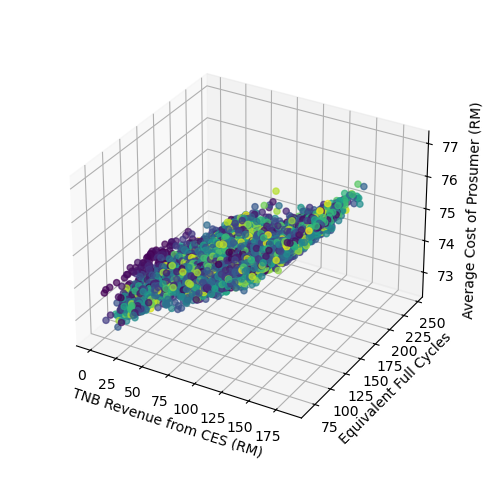

In [6]:
obj_array, position_array = obj_proc(obj_df, position_df, df=False)

from mpl_toolkits.mplot3d import Axes3D
fontttt = 10
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(obj_array[:,0], obj_array[:,1], obj_array[:,2], c=position_array[:,1], cmap='viridis', alpha=0.7)
ax.set_xlabel('TNB Revenue from CES (RM)', fontsize=fontttt)
ax.set_ylabel('Equivalent Full Cycles', fontsize=fontttt)
ax.set_zlabel('Average Cost of Prosumer (RM)', fontsize=fontttt)
# ax.set_title('Pareto Front in Objective Space', fontsize=14)
ax.set_box_aspect(aspect=None, zoom=0.85)
plt.savefig(f"test.png", format = "png", bbox_inches='tight', dpi = 300)
plt.show()



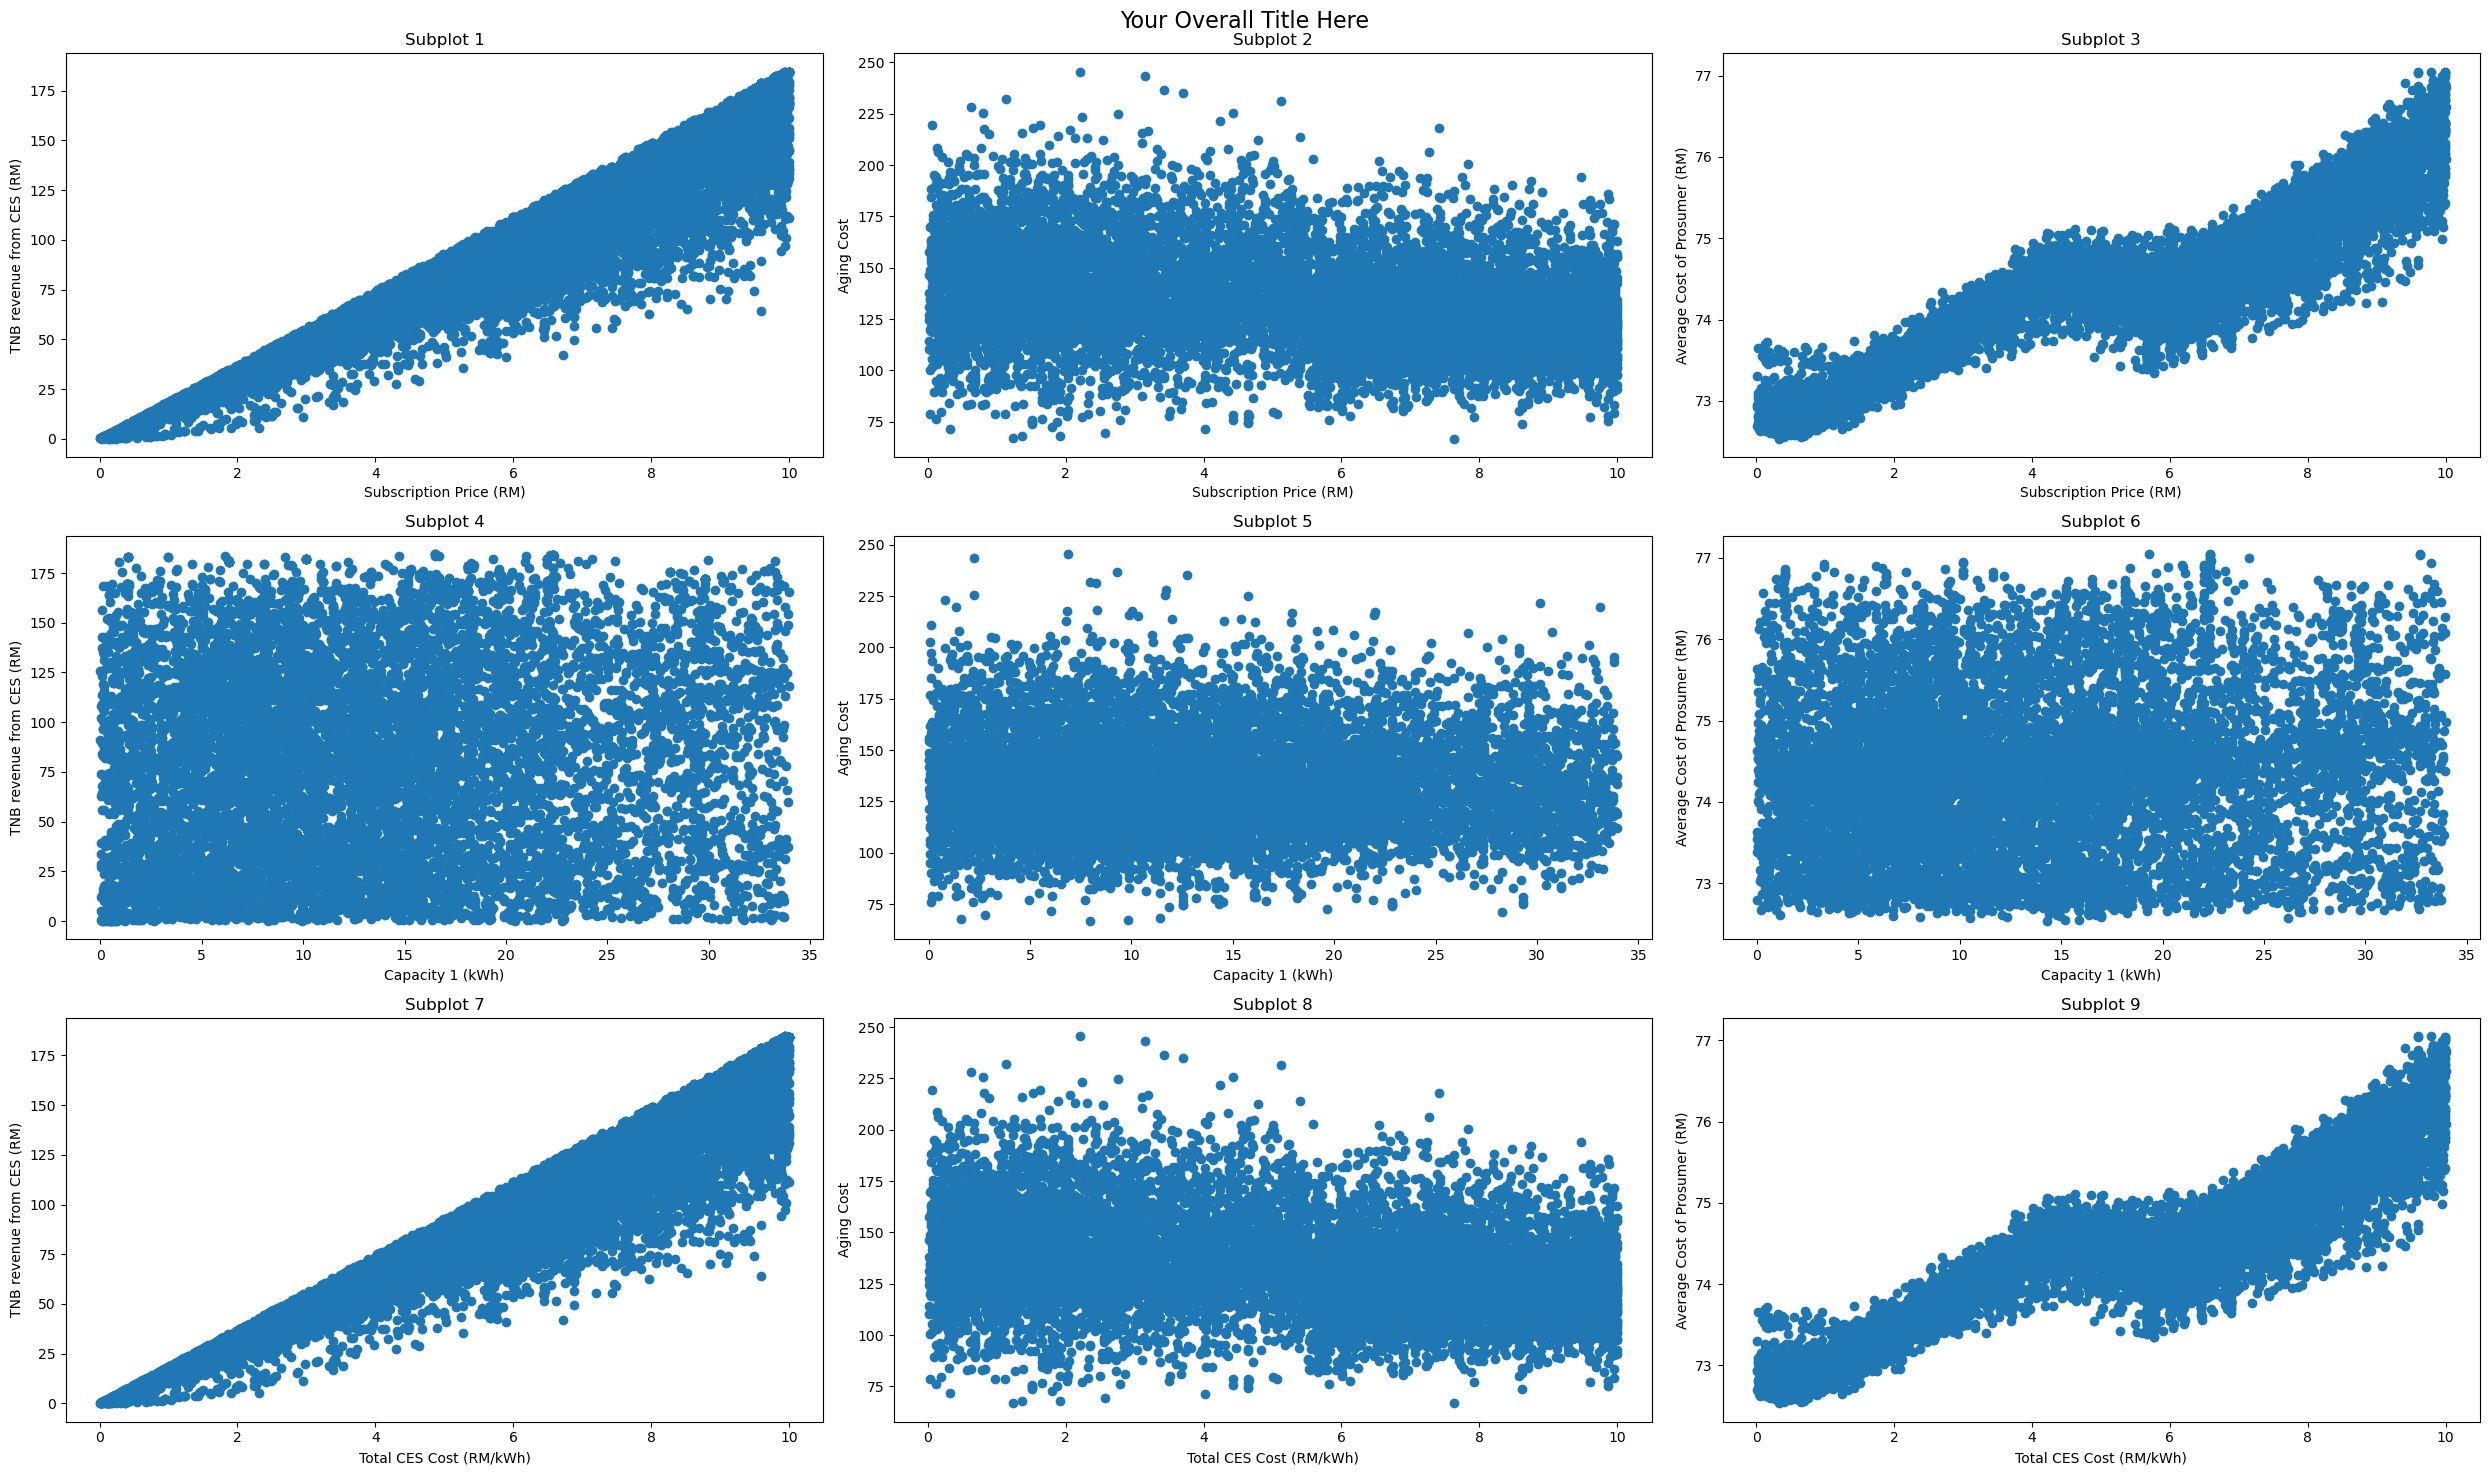

In [7]:
obj_non_dom_array, position_non_dom_array = obj_proc(obj_df, position_df, df=False)

# Create figure and subplots
fig, axs = plt.subplots(3, 3, figsize=(25, 15))
fig.suptitle('Your Overall Title Here', fontsize=16)

# Flatten axs array for easier iteration if needed
axs = axs.flatten()

# Example for each subplot
for i in range(9):
    if i < 6:
        # Here you can customize each subplot
        axs[i].set_xlabel(position_non_dom.columns[0 if i < 3 else 1])
        axs[i].set_ylabel(obj_non_dom.columns[i % 3])
        axs[i].set_title(f'Subplot {i+1}')
        
        # Add your plotting commands here for each subplot
        # Example: axs[i].plot(x, y)
        # Example: axs[i].scatter(x, y)
        axs[i].plot(position_non_dom_array[:, 0 if i < 3 else 1], obj_non_dom_array[:, i % 3], 'o')
    else:
        axs[i].set_xlabel('Total CES Cost (RM/kWh)')
        axs[i].set_ylabel(obj_non_dom.columns[(i - 6) % 3])
        axs[i].set_title(f'Subplot {i+1}')

        total_ces_cost = position_non_dom_array[:, 0]
        axs[i].plot(total_ces_cost, obj_non_dom_array[:, (i - 6) % 3], 'o')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

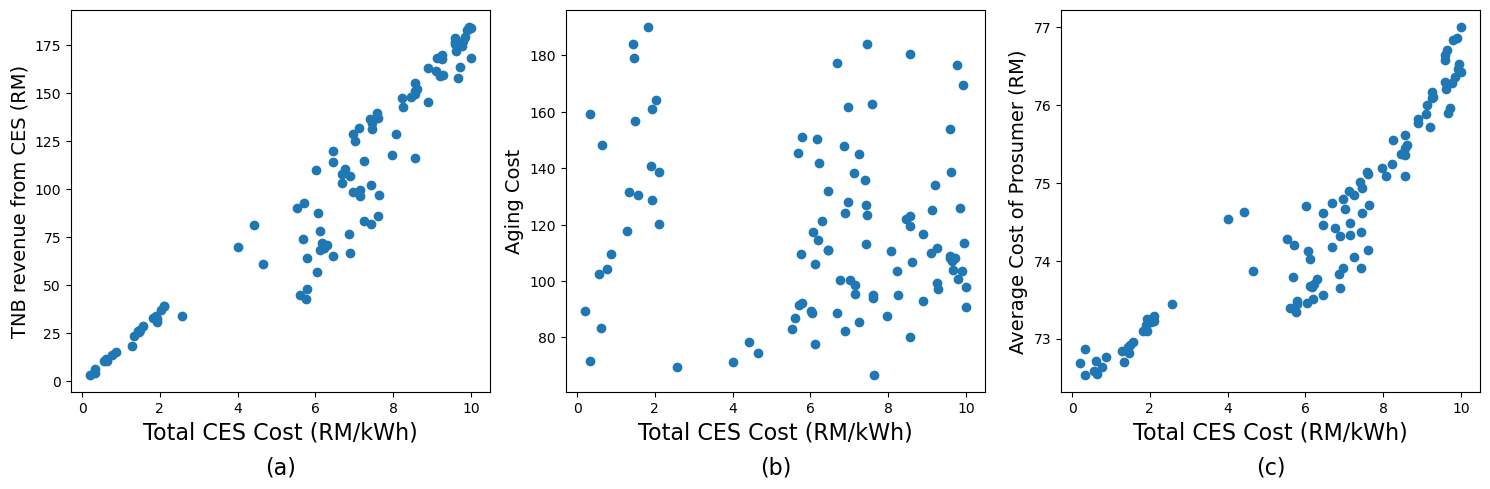

In [8]:
obj_non_dom_array, position_non_dom_array = obj_proc(obj_df_non_dom, position_df_non_dom, df=False)

# Create figure and subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
# fig.suptitle('Your Overall Title Here', fontsize=16)

# Flatten axs array for easier iteration if needed
axs = axs.flatten()
plot_title = ['(a)', '(b)', '(c)']

# Example for each subplot
for i in range(3):
    k = i
    # if i < 6:
    #     # Here you can customize each subplot
    #     axs[i].set_xlabel(position_non_dom.columns[0 if i < 3 else 1])
    #     axs[i].set_ylabel(obj_non_dom.columns[i % 3])
    #     axs[i].set_title(f'Subplot {i+1}')
        
    #     # Add your plotting commands here for each subplot
    #     # Example: axs[i].plot(x, y)
    #     # Example: axs[i].scatter(x, y)
    #     axs[i].plot(position_non_dom_array[:, 0 if i < 3 else 1], obj_non_dom_array[:, i % 3], 'o')
    # else:
        # k = i - 6
    axs[i].set_xlabel('Total CES Cost (RM/kWh)', fontsize =16)
    axs[i].set_ylabel(obj_non_dom.columns[(k) % 3], fontsize=14)
    axs[i].set_title(plot_title[i], y=-0.25, pad=10, fontsize=16)

    total_ces_cost = position_non_dom_array[:, 0]
    axs[i].plot(total_ces_cost, obj_non_dom_array[:, (k) % 3], 'o')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.savefig(f"ROI_dec_vs_obj.png", format = "png", bbox_inches='tight', dpi = 300)
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_22468\3895172192.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([position_non_dom_array[:,0]], labels=['Subsp price'])
C:\Users\PC\AppData\Local\Temp\ipykernel_22468\3895172192.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([np.sum(position_non_dom_array[:,1:], axis=1)], labels=['Total CES Usage'])


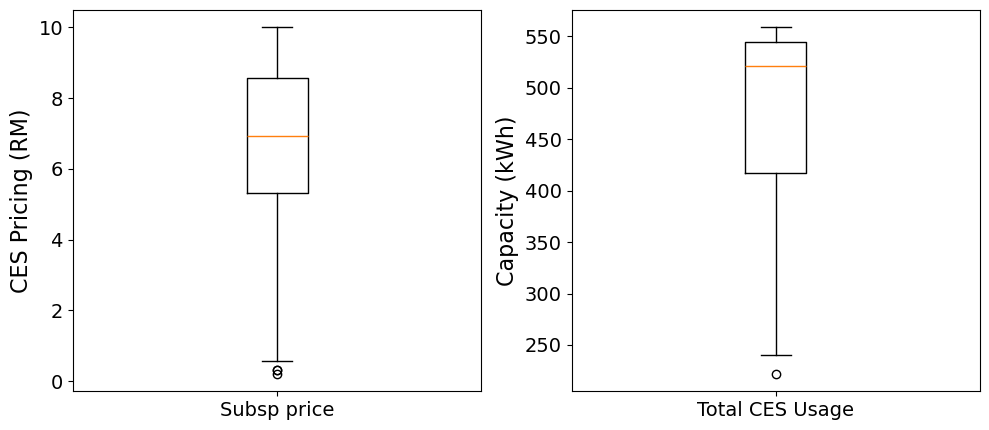

In [9]:
# Create the box plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Execution Time box plot
ax[0].boxplot([position_non_dom_array[:,0]], labels=['Subsp price'])
# ax.set_xlabel('CES Pricing (RM)', fontsize=16)
ax[0].set_ylabel('CES Pricing (RM)', fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=14)

# Execution Time box plot
ax[1].boxplot([np.sum(position_non_dom_array[:,1:], axis=1)], labels=['Total CES Usage'])
# ax.set_xlabel('CES Pricing (RM)', fontsize=16)
ax[1].set_ylabel('Capacity (kWh)', fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=14)

# Add overall title and display the plot
# fig.suptitle('Comparison of Performance Metrics for w/o AI vs w/ AI')
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust the title space
plt.savefig('ROI_price_box.png')  # Save the figure as a PNG
plt.show()

# Solcast one year evaluation

## Usage

In [3]:
cwd = os.getcwd()  # Gets test folder path
nwd = os.path.join(cwd, r'MOMSA_code/Benchmark/solcast/usage_v2')
os.chdir(nwd)
os.getcwd()

'd:\\Jacky\\MATLAB\\Battery_ROI\\MOMSA_code\\Benchmark\\solcast\\usage_v2'

In [4]:
cwd = os.getcwd()
for i in range(20):
    change = (i / 2 * 0.1) - 50 / 100
    folder_path = rf'D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\solcast\usage_v2\run_{change:.2f}'

    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    os.chdir(folder_path)

    #### Optimal Price Obtained ####
    result_loc = 'MOMSA ranked limit usage v2 1'
    result = np.array(pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\For paper\{result_loc}.xlsx", sheet_name="Sheet1", header=None))
    sol = 0

    exe_path = r"C:\Users\PC\source\repos\p2p_optimal placement\x64\Release\p2p_optimal placement.exe"

    L = result[sol,:]

    # for sensitivity analysis
    L[0] = L[0] * (1 + change)
    L[1] = L[1] * (1 + change)

    L[2] = L[0] * L[2]
    L[3] = L[1] * L[3]
    L[4] = L[0] * L[4]
    L[5] = L[1] * L[5]
    inputs = L / 0.57

    solcast_sce = 2

    # Final CMD command
    cmd = [exe_path] + [str(x) for x in inputs] + [str(solcast_sce)]

    # Print so you can copy-paste into terminal
    print(cmd)

    for sce in range(364):
        solcast_sce = 1 + sce

        # Final CMD command
        cmd = [exe_path] + [str(x) for x in inputs] + [str(solcast_sce)]

        result_proc = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            check=True
        )

        # Output from exe
        # print("STDOUT:")
        # print(result_proc.stdout)

        print("STDERR:")
        print(result_proc.stderr)

['C:\\Users\\PC\\source\\repos\\p2p_optimal placement\\x64\\Release\\p2p_optimal placement.exe', '0.09235909347806111', '0.3874784826653033', '0.043128554082235156', '0.559697183305609', '0.04822990103630724', '0.3928437046352052', '2']
STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

## Subscription

In [5]:
nwd = 'D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\solcast\subs_v3'
os.chdir(nwd)
os.getcwd()

<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:1: SyntaxWarning: invalid escape sequence '\J'
C:\Users\PC\AppData\Local\Temp\ipykernel_75436\870898593.py:1: SyntaxWarning: invalid escape sequence '\J'
  nwd = 'D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\solcast\subs_v3'


'D:\\Jacky\\MATLAB\\Battery_ROI\\MOMSA_code\\Benchmark\\solcast\\subs_v3'

In [6]:
cwd = os.getcwd()
for i in range(20):
    change = (i / 2 * 0.1) - 50 / 100
    folder_path = rf'D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\solcast\subs_v3\run_{change:.2f}'

    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    os.chdir(folder_path)
    #### Optimal Price Obtained ####
    result_loc = 'MOMSA ranked unlimit subsc v4 1'
    result = np.array(pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\For paper\{result_loc}.xlsx", sheet_name="Sheet1", header=None))
    sol = 0

    exe_path = r"D:\Jacky\Julia-vscode\(Cpp)ADMM_P2P\x64\Release\p2p.exe"

    inputs = result[sol,:]
    inputs[0] = inputs[0] * (1 + change)
    inputs[0] = 1 - inputs[0] / 10
    solcast_sce = 2

    # Final CMD command
    cmd = [exe_path] + [str(x) for x in inputs] + [str(solcast_sce)]

    # Print so you can copy-paste into terminal
    print(cmd)

    for sce in range(364):
        solcast_sce = 1 + sce

        # Final CMD command
        cmd = [exe_path] + [str(x) for x in inputs] + [str(solcast_sce)]

        result_proc = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            check=True
        )

        # Output from exe
        # print("STDOUT:")
        # print(result_proc.stdout)

        print("STDERR:")
        print(result_proc.stderr)

['D:\\Jacky\\Julia-vscode\\(Cpp)ADMM_P2P\\x64\\Release\\p2p.exe', '0.5041520051343102', '25.331745349582533', '28.074360183587935', '23.139081772570986', '16.04778672907373', '7.1798425264950065', '26.40449099609369', '10.168537194527161', '24.70952899915756', '12.730069842194675', '24.311886598429236', '2.2548822733954332', '26.976696622977283', '2.5708796243145904', '23.21243878576352', '9.002770047275055', '17.214139540814152', '21.435318965319265', '22.7308252505601', '15.720988605930692', '7.819139111119871', '23.179684958401335', '13.115989139992852', '25.913987615628397', '16.685532052238425', '22.405758191667175', '4.681224118541429', '18.351190094961993', '20.779175950776114', '19.357421499801355', '10.678144263864342', '8.45496705315865', '28.058001114449585', '2']
STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

STDERR:

# For Paper

## Statistical Performance

In [11]:
# Decision Stats
#====================== Techno ======================
MOMSA_techno = pd.read_excel(r"D:\Jacky\MATLAB\OptimalPlacement\Result\Data\CorrectScoreRank\MOMSA unrank.xlsx", sheet_name="Sheet1", header=None)
MOMSA_techno = MOMSA_techno.to_numpy()

no_CES = MOMSA_techno[:,0]
placement_CES = MOMSA_techno[:,1:5].flatten()
size_CES = np.sum(MOMSA_techno[:,5:], axis=1)

placement_CES = placement_CES[placement_CES != 0]
placement_mask = [1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 0, 1, 2, 3, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

distance_CES = []
for i in range(len(placement_CES)):
    idx = int(placement_CES[i]) - 1
    distance_CES.append(placement_mask[idx])

distance_CES = np.array(distance_CES)

# Statistics
stats_tab = PrettyTable()
stats_tab.field_names = ['', 'Mean', 'Std', 'Min', 'Max']
stats_tab.add_row(["---------------- Stage I -----------------", "", "", "", ""])
stats_tab.add_row(['CES Number', f'{np.mean(no_CES):.2f}', f'{np.std(no_CES):.2f}', f'{np.min(no_CES):.2f}', f'{np.max(no_CES):.2f}'])
stats_tab.add_row(['Distance to Congested Branch', f'{np.mean(distance_CES):.2f}', f'{np.std(distance_CES):.2f}', f'{np.min(distance_CES):.2f}', f'{np.max(distance_CES):.2f}'])
stats_tab.add_row(['CES Size (kWh)', f'{np.mean(size_CES):.2f}', f'{np.std(size_CES):.2f}', f'{np.min(size_CES):.2f}', f'{np.max(size_CES):.2f}'])

#====================== Eco ======================
MOMSA_eco_usage = pd.read_excel(r"D:\Jacky\Data Output\Battery ROI\For paper\MOMSA unrank limit usage v2 1.xlsx", sheet_name="Sheet1", header=None)
MOMSA_eco_usage = MOMSA_eco_usage.to_numpy()
MOMSA_eco_usage[:,2:] = MOMSA_eco_usage[:,2:] * 100  # convert to percentage

MOMSA_eco_subs = pd.read_excel(r"D:\Jacky\Data Output\Battery ROI\For paper\MOMSA unrank unlimit subsc v4 1.xlsx", sheet_name="Sheet1", header=None)
MOMSA_eco_subs = MOMSA_eco_subs.to_numpy()
MOMSA_eco_subs_size = np.mean(MOMSA_eco_subs[:,1:], axis=1)
MOMSA_eco_subs_size_tot = np.sum(MOMSA_eco_subs[:,1:], axis=1)

stats_tab.add_row(["------------ Stage II - Usage ------------", "", "", "", ""])
stats_tab.add_row(['Base CES Charge Price (RM/kWh)', f'{np.mean(MOMSA_eco_usage[:,0]):.2f}', f'{np.std(MOMSA_eco_usage[:,0]):.2f}', f'{np.min(MOMSA_eco_usage[:,0]):.2f}', f'{np.max(MOMSA_eco_usage[:,0]):.2f}'])
stats_tab.add_row(['Base CES Discharge Price (RM/kWh)', f'{np.mean(MOMSA_eco_usage[:,1]):.2f}', f'{np.std(MOMSA_eco_usage[:,1]):.2f}', f'{np.min(MOMSA_eco_usage[:,1]):.2f}', f'{np.max(MOMSA_eco_usage[:,1]):.2f}'])
stats_tab.add_row(['Charge Price Adjustment - P2P (%)', f'{np.mean(MOMSA_eco_usage[:,2]):.2f}', f'{np.std(MOMSA_eco_usage[:,2]):.2f}', f'{np.min(MOMSA_eco_usage[:,2]):.2f}', f'{np.max(MOMSA_eco_usage[:,2]):.2f}'])
stats_tab.add_row(['Discharge Price Adjustment - P2P (%)', f'{np.mean(MOMSA_eco_usage[:,3]):.2f}', f'{np.std(MOMSA_eco_usage[:,3]):.2f}', f'{np.min(MOMSA_eco_usage[:,3]):.2f}', f'{np.max(MOMSA_eco_usage[:,3]):.2f}'])
stats_tab.add_row(['Charge Price Adjustment - Close (%)', f'{np.mean(MOMSA_eco_usage[:,4]):.2f}', f'{np.std(MOMSA_eco_usage[:,4]):.2f}', f'{np.min(MOMSA_eco_usage[:,4]):.2f}', f'{np.max(MOMSA_eco_usage[:,4]):.2f}'])
stats_tab.add_row(['Discharge Price Adjustment - Close (%)', f'{np.mean(MOMSA_eco_usage[:,5]):.2f}', f'{np.std(MOMSA_eco_usage[:,5]):.2f}', f'{np.min(MOMSA_eco_usage[:,5]):.2f}', f'{np.max(MOMSA_eco_usage[:,5]):.2f}'])
stats_tab.add_row(["--------- Stage II - Subscription ---------", "", "", "", ""])
stats_tab.add_row(['CES Subscription Price (RM/kWh)', f'{np.mean(MOMSA_eco_subs[:,0]):.2f}', f'{np.std(MOMSA_eco_subs[:,0]):.2f}', f'{np.min(MOMSA_eco_subs[:,0]):.2f}', f'{np.max(MOMSA_eco_subs[:,0]):.2f}'])
stats_tab.add_row(['Average Subscribed Capacity (kWh/participants)', f'{np.mean(MOMSA_eco_subs_size):.2f}', f'{np.std(MOMSA_eco_subs_size):.2f}', f'{np.min(MOMSA_eco_subs_size):.2f}', f'{np.max(MOMSA_eco_subs_size):.2f}'])
stats_tab.add_row(['Total Subscribed Capacity (kWh)', f'{np.mean(MOMSA_eco_subs_size_tot):.2f}', f'{np.std(MOMSA_eco_subs_size_tot):.2f}', f'{np.min(MOMSA_eco_subs_size_tot):.2f}', f'{np.max(MOMSA_eco_subs_size_tot):.2f}'])

print(stats_tab)

CES_initial_cost = 559160.47
print("Total CES Capacity (kWh): ", f'{CES_initial_cost/1000:.2f}')


+------------------------------------------------+--------+--------+--------+--------+
|                                                |  Mean  |  Std   |  Min   |  Max   |
+------------------------------------------------+--------+--------+--------+--------+
|   ---------------- Stage I -----------------   |        |        |        |        |
|                   CES Number                   |  2.48  |  0.96  |  1.00  |  4.00  |
|          Distance to Congested Branch          |  4.72  |  4.80  |  0.00  | 16.00  |
|                 CES Size (kWh)                 | 528.06 | 198.71 | 189.98 | 893.10 |
|   ------------ Stage II - Usage ------------   |        |        |        |        |
|         Base CES Charge Price (RM/kWh)         |  0.27  |  0.16  |  0.10  |  0.57  |
|       Base CES Discharge Price (RM/kWh)        |  0.40  |  0.14  |  0.11  |  0.56  |
|       Charge Price Adjustment - P2P (%)        | 79.08  | 55.64  | 11.87  | 199.00 |
|      Discharge Price Adjustment - P2P (%)

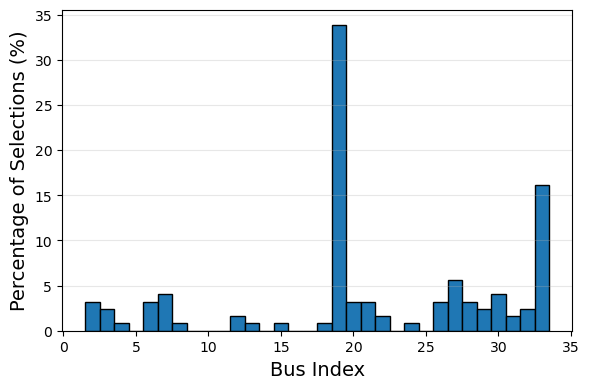

In [10]:
weights = np.ones_like(placement_CES) / len(placement_CES) * 100

plt.figure(figsize=(6, 4))

plt.hist(
    placement_CES,
    bins=np.arange(1.5, 34.5, 1),
    weights=weights,
    edgecolor='black'
)

plt.xlabel("Bus Index", fontsize=14)
plt.ylabel("Percentage of Selections (%)", fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('CES_placement_frequency.svg', dpi=300, bbox_inches='tight')
plt.show()

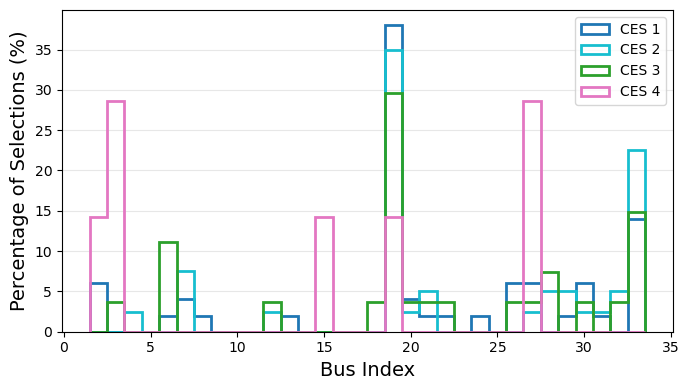

In [25]:
ces1 = MOMSA_techno[:, 1]
ces2 = MOMSA_techno[:, 2]
ces3 = MOMSA_techno[:, 3]
ces4 = MOMSA_techno[:, 4]

# Remove zeros (no CES)
ces1 = ces1[ces1 != 0]
ces2 = ces2[ces2 != 0]
ces3 = ces3[ces3 != 0]
ces4 = ces4[ces4 != 0]

def percent_weights(x):
    return np.ones_like(x) / len(x) * 100

bins = np.arange(1.5, 34.5, 1)
colors = ["#1f77b4", "#17becf", "#2ca02c", "#e377c2", "#7f7f7f"]

# plt.figure(figsize=(7, 4))

# plt.hist(ces1, bins=bins, weights=percent_weights(ces1), alpha=0.9, label='CES 1', color=colors[0])
# plt.hist(ces2, bins=bins, weights=percent_weights(ces2), alpha=0.9, label='CES 2', color=colors[1])
# plt.hist(ces3, bins=bins, weights=percent_weights(ces3), alpha=0.9, label='CES 3', color=colors[2])
# plt.hist(ces4, bins=bins, weights=percent_weights(ces4), alpha=0.9, label='CES 4', color=colors[3])

# plt.xlabel("Bus Index")
# plt.ylabel("Percentage of Selections (%)")
# plt.title("Percentage Distribution of CES Placement Across Pareto Solutions")
# plt.legend()
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(7, 4))

plt.hist(ces1, bins=bins, weights=percent_weights(ces1), histtype='step', linewidth=2, label='CES 1', color=colors[0])
plt.hist(ces2, bins=bins, weights=percent_weights(ces2), histtype='step', linewidth=2, label='CES 2', color=colors[1])
plt.hist(ces3, bins=bins, weights=percent_weights(ces3), histtype='step', linewidth=2, label='CES 3', color=colors[2])
plt.hist(ces4, bins=bins, weights=percent_weights(ces4), histtype='step', linewidth=2, label='CES 4', color=colors[3])

plt.xlabel("Bus Index", fontsize=14)
plt.ylabel("Percentage of Selections (%)", fontsize=14)
# plt.title("Percentage Distribution of CES Placement Across Pareto Solutions")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('CES_placement_frequency.svg', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Objective Stats
#====================== Techno ======================
MOMSA_techno = pd.read_excel(r"D:\Jacky\MATLAB\OptimalPlacement\Result\Data\CorrectScoreRank\MOMSA unrank.xlsx", sheet_name="Sheet2", header=None)
MOMSA_techno = MOMSA_techno.to_numpy()
MOMSA_techno[:,0] = MOMSA_techno[:,0] * 1000

# Statistics
stats_tab = PrettyTable()
stats_tab.field_names = ['', 'Mean', 'Std', 'Min', 'Max']
stats_tab.add_row(["Stage I", "", "", "", ""])
stats_tab.add_row(['Power Loss (kW)', f'{np.mean(MOMSA_techno[:,0]):.2f}', f'{np.std(MOMSA_techno[:,0]):.2f}', f'{np.min(MOMSA_techno[:,0]):.2f}', f'{np.max(MOMSA_techno[:,0]):.2f}'])
stats_tab.add_row(['CES Investment Cost (RM)', f'{np.mean(MOMSA_techno[:,1]):.2f}', f'{np.std(MOMSA_techno[:,1]):.2f}', f'{np.min(MOMSA_techno[:,1]):.2f}', f'{np.max(MOMSA_techno[:,1]):.2f}'])
stats_tab.add_row(['Average Cost of Participant (RM)', f'{np.mean(MOMSA_techno[:,2]):.2f}', f'{np.std(MOMSA_techno[:,2]):.2f}', f'{np.min(MOMSA_techno[:,2]):.2f}', f'{np.max(MOMSA_techno[:,2]):.2f}'])

# #====================== Eco ======================
MOMSA_eco_usage_prosCost = pd.read_csv(r"D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\p2p_CES\limit\ProsumerCost.csv", header=None)
MOMSA_eco_usage_prosCost = MOMSA_eco_usage_prosCost.to_numpy()

MOMSA_eco_usage = pd.read_excel(r"D:\Jacky\Data Output\Battery ROI\For paper\MOMSA unrank limit usage v2 1.xlsx", sheet_name="Sheet2", header=None)
MOMSA_eco_usage = MOMSA_eco_usage.to_numpy()
MOMSA_eco_usage[:,0] *= -1
MOMSA_eco_usage[:,2] = MOMSA_eco_usage[:,2] + np.mean(MOMSA_eco_usage_prosCost) 

MOMSA_eco_subs = pd.read_excel(r"D:\Jacky\Data Output\Battery ROI\For paper\MOMSA unrank unlimit subsc v4 1.xlsx", sheet_name="Sheet2", header=None)
MOMSA_eco_subs = MOMSA_eco_subs.to_numpy()
MOMSA_eco_subs[:,0] *= -1

stats_tab.add_row(["Stage II - Usage", "", "", "", ""])
stats_tab.add_row(['CES Operator Revenue (RM)', f'{np.mean(MOMSA_eco_usage[:,0]):.2f}', f'{np.std(MOMSA_eco_usage[:,0]):.2f}', f'{np.min(MOMSA_eco_usage[:,0]):.2f}', f'{np.max(MOMSA_eco_usage[:,0]):.2f}'])
stats_tab.add_row(['Battery Aging Cost', f'{np.mean(MOMSA_eco_usage[:,1]):.2f}', f'{np.std(MOMSA_eco_usage[:,1]):.2f}', f'{np.min(MOMSA_eco_usage[:,1]):.2f}', f'{np.max(MOMSA_eco_usage[:,1]):.2f}'])
stats_tab.add_row(['Average Cost of Participants with CES (RM)', f'{np.mean(MOMSA_eco_usage[:,2]):.2f}', f'{np.std(MOMSA_eco_usage[:,2]):.2f}', f'{np.min(MOMSA_eco_usage[:,2]):.2f}', f'{np.max(MOMSA_eco_usage[:,2]):.2f}'])
stats_tab.add_row(["Stage II - Subscription", "", "", "", ""])
stats_tab.add_row(['CES Operator Revenue (RM)', f'{np.mean(MOMSA_eco_subs[:,0]):.2f}', f'{np.std(MOMSA_eco_subs[:,0]):.2f}', f'{np.min(MOMSA_eco_subs[:,0]):.2f}', f'{np.max(MOMSA_eco_subs[:,0]):.2f}'])
stats_tab.add_row(['Battery Aging Cost', f'{np.mean(MOMSA_eco_subs[:,1]):.2f}', f'{np.std(MOMSA_eco_subs[:,1]):.2f}', f'{np.min(MOMSA_eco_subs[:,1]):.2f}', f'{np.max(MOMSA_eco_subs[:,1]):.2f}'])
stats_tab.add_row(['Average Cost of Participants with CES (RM)', f'{np.mean(MOMSA_eco_subs[:,2]):.2f}', f'{np.std(MOMSA_eco_subs[:,2]):.2f}', f'{np.min(MOMSA_eco_subs[:,2]):.2f}', f'{np.max(MOMSA_eco_subs[:,2]):.2f}'])

print(stats_tab)

# CES_initial_cost = 559160.47
# print("Total CES Capacity (kWh): ", f'{CES_initial_cost/1000:.2f}')


+--------------------------------------------+-----------+-----------+-----------+-----------+
|                                            |    Mean   |    Std    |    Min    |    Max    |
+--------------------------------------------+-----------+-----------+-----------+-----------+
|                  Stage I                   |           |           |           |           |
|              Power Loss (kW)               |    5.59   |    0.41   |    5.12   |    7.24   |
|          CES Investment Cost (RM)          | 528058.63 | 198713.33 | 189981.71 | 893103.03 |
|      Average Cost of Participant (RM)      |   72.06   |    1.44   |   70.64   |   74.93   |
|              Stage II - Usage              |           |           |           |           |
|         CES Operator Revenue (RM)          |   102.62  |   54.88   |    9.01   |   202.55  |
|             Battery Aging Cost             |   142.30  |   41.74   |   61.59   |   228.99  |
| Average Cost of Participants with CES (RM) |   7

In [40]:
# Composite Score Stats
#====================== Techno ======================
MOMSA_techno_score = pd.read_excel(r"D:\Jacky\MATLAB\OptimalPlacement\Result\Data\CorrectScoreRank\MOMSA ranked.xlsx", sheet_name="Sheet4", header=None)
MOMSA_techno_score = MOMSA_techno_score.to_numpy().flatten()

MOMSA_techno_sol = pd.read_excel(r"D:\Jacky\MATLAB\OptimalPlacement\Result\Data\CorrectScoreRank\MOMSA ranked.xlsx", sheet_name="Sheet1", header=None)
MOMSA_techno_sol = MOMSA_techno_sol.to_numpy()

idx = np.argsort(MOMSA_techno_score)
MOMSA_techno_score = MOMSA_techno_score[idx]
MOMSA_techno_sol = MOMSA_techno_sol[idx,:]
print('Stage I: ', MOMSA_techno_sol[-1,:], ' with score: ', f'{MOMSA_techno_score[-1]:.2e}')

# # Statistics
stats_tab = PrettyTable()
stats_tab.field_names = ['', 'Mean', 'Std', 'Min', 'Max']
stats_tab.add_row(['Stage I', f'{np.mean(MOMSA_techno_score):.2e}', f'{np.std(MOMSA_techno_score):.2e}', f'{np.min(MOMSA_techno_score):.2e}', f'{np.max(MOMSA_techno_score):.2e}'])

# #====================== Eco ======================
MOMSA_eco_usage = pd.read_excel(r"D:\Jacky\Data Output\Battery ROI\For paper\MOMSA ranked limit usage v2 1.xlsx", sheet_name="Sheet3", header=None)
MOMSA_eco_usage = MOMSA_eco_usage.to_numpy().flatten()

MOMSA_eco_usage_sol = pd.read_excel(r"D:\Jacky\Data Output\Battery ROI\For paper\MOMSA ranked limit usage v2 1.xlsx", sheet_name="Sheet1", header=None)
MOMSA_eco_usage_sol = MOMSA_eco_usage_sol.to_numpy()

MOMSA_eco_subs = pd.read_excel(r"D:\Jacky\Data Output\Battery ROI\For paper\MOMSA ranked unlimit subsc v4 1.xlsx", sheet_name="Sheet3", header=None)
MOMSA_eco_subs = MOMSA_eco_subs.to_numpy().flatten()

MOMSA_eco_subs_sol = pd.read_excel(r"D:\Jacky\Data Output\Battery ROI\For paper\MOMSA ranked unlimit subsc v4 1.xlsx", sheet_name="Sheet1", header=None)
MOMSA_eco_subs_sol = MOMSA_eco_subs_sol.to_numpy()

idx = np.argsort(MOMSA_eco_usage)
MOMSA_eco_usage = MOMSA_eco_usage[idx]
MOMSA_eco_usage_sol = MOMSA_eco_usage_sol[idx,:]
print('Stage II - Usage: ', MOMSA_eco_usage_sol[-1,:], ' with score: ', f'{MOMSA_eco_usage[-1]:.2e}')

idx = np.argsort(MOMSA_eco_subs)
MOMSA_eco_subs = MOMSA_eco_subs[idx]
MOMSA_eco_subs_sol = MOMSA_eco_subs_sol[idx,:]
print('Stage II - Subscription: ', MOMSA_eco_subs_sol[-1,:], ' with score: ', f'{MOMSA_eco_subs[-1]:.2e}')

stats_tab.add_row(['Stage II - Usage', f'{np.mean(MOMSA_eco_usage):.2e}', f'{np.std(MOMSA_eco_usage):.2e}', f'{np.min(MOMSA_eco_usage):.2e}', f'{np.max(MOMSA_eco_usage):.2e}'])
stats_tab.add_row(['Stage II - Subscription', f'{np.mean(MOMSA_eco_subs):.2e}', f'{np.std(MOMSA_eco_subs):.2e}', f'{np.min(MOMSA_eco_subs):.2e}', f'{np.max(MOMSA_eco_subs):.2e}'])

print(stats_tab)

Stage I:  [  2.          19.          33.           0.           0.
 283.51887919 275.64159138   0.           0.        ]  with score:  4.24e-02
Stage II - Usage:  [0.10528937 0.44172547 0.46696597 1.44446004 0.52219981 1.0138465 ]  with score:  2.22e-02
Stage II - Subscription:  [ 9.9169599  25.33174535 28.07436018 23.13908177 16.04778673  7.17984253
 26.404491   10.16853719 24.709529   12.73006984 24.3118866   2.25488227
 26.97669662  2.57087962 23.21243879  9.00277005 17.21413954 21.43531897
 22.73082525 15.72098861  7.81913911 23.17968496 13.11598914 25.91398762
 16.68553205 22.40575819  4.68122412 18.35119009 20.77917595 19.3574215
 10.67814426  8.45496705 28.05800111]  with score:  2.20e-02
+-------------------------+----------+----------+----------+----------+
|                         |   Mean   |   Std    |   Min    |   Max    |
+-------------------------+----------+----------+----------+----------+
|         Stage I         | 2.41e-02 | 4.56e-03 | 2.04e-02 | 4.24e-02 |
|     

In [41]:
# Convert PrettyTable to pandas DataFrame
df = pd.DataFrame(stats_tab.rows, columns=stats_tab.field_names)

# Save to Excel
df.to_excel("ces_statistics.xlsx", index=False)

## Post-Pareto Analysis

In [ ]:

MOMSA_eco_usage_score = pd.read_excel(r"D:\Jacky\Data Output\Battery ROI\For paper\MOMSA ranked limit usage v2 1.xlsx", sheet_name="Sheet3", header=None)
MOMSA_eco_usage_score = MOMSA_eco_usage_score.to_numpy()

MOMSA_eco_usage_best = pd.read_excel(r"D:\Jacky\Data Output\Battery ROI\For paper\MOMSA ranked limit usage v2 1.xlsx", sheet_name="Sheet1", header=None)
MOMSA_eco_usage_best = MOMSA_eco_usage_best.to_numpy()[0,:]

MOMSA_eco_subs_score = pd.read_excel(r"D:\Jacky\Data Output\Battery ROI\For paper\MOMSA ranked unlimit subsc v4 1.xlsx", sheet_name="Sheet3", header=None)
MOMSA_eco_subs_score = MOMSA_eco_subs_score.to_numpy()

MOMSA_eco_subs_best = pd.read_excel(r"D:\Jacky\Data Output\Battery ROI\For paper\MOMSA ranked unlimit subsc v4 1.xlsx", sheet_name="Sheet1", header=None)
MOMSA_eco_subs_best = MOMSA_eco_subs_best.to_numpy()[0,:]



(array([0.02222871]),
 array([0.10528937, 0.44172547, 0.46696597, 1.44446004, 0.52219981,
        1.0138465 ]),
 array([0.02196724]),
 array([ 9.9169599 , 25.33174535, 28.07436018, 23.13908177, 16.04778673,
         7.17984253, 26.404491  , 10.16853719, 24.709529  , 12.73006984,
        24.3118866 ,  2.25488227, 26.97669662,  2.57087962, 23.21243879,
         9.00277005, 17.21413954, 21.43531897, 22.73082525, 15.72098861,
         7.81913911, 23.17968496, 13.11598914, 25.91398762, 16.68553205,
        22.40575819,  4.68122412, 18.35119009, 20.77917595, 19.3574215 ,
        10.67814426,  8.45496705, 28.05800111]))

## Selected Solution Analysis

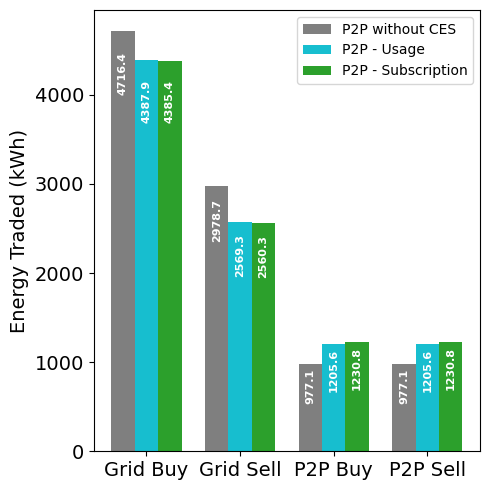

In [4]:
#====================== Usage ======================
# P2P trading amount breakdown
gbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\Grid_buy.csv"
gsell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\Grid_sell.csv"
pbuy_loc        = r"MOMSA_code\Benchmark\p2p_noCES\P2P_buy.csv"
psell_loc       = r"MOMSA_code\Benchmark\p2p_noCES\P2P_sell.csv"

gbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\usage v2\Grid_buy.csv"
gsell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\usage v2\Grid_sell.csv"
pbuy_CES_loc    = r"MOMSA_code\Benchmark\p2p_CES\usage v2\P2P_buy.csv"
psell_CES_loc   = r"MOMSA_code\Benchmark\p2p_CES\usage v2\P2P_sell.csv"
ces_lv_loc      = r"MOMSA_code\Benchmark\p2p_CES\usage v2\Battery_Level_CES.csv"
cd_loc          = r"MOMSA_code\Benchmark\p2p_CES\usage v2\Charge_Discharge.csv"

gbuy_CES_loc_subs    = r"MOMSA_code\Benchmark\p2p_CES\subs v3\Grid_buy.csv"
gsell_CES_loc_subs   = r"MOMSA_code\Benchmark\p2p_CES\subs v3\Grid_sell.csv"
pbuy_CES_loc_subs    = r"MOMSA_code\Benchmark\p2p_CES\subs v3\P2P_buy.csv"
psell_CES_loc_subs   = r"MOMSA_code\Benchmark\p2p_CES\subs v3\P2P_sell.csv"
ces_lv_loc_subs      = r"MOMSA_code\Benchmark\p2p_CES\subs v3\Battery_Level_CES.csv"
cd_loc_subs          = r"MOMSA_code\Benchmark\p2p_CES\subs v3\Charge_Discharge.csv"

gbuy_p2p        = pd.read_csv(gbuy_loc, header=None).to_numpy()[:,:-1]
gsell_p2p       = pd.read_csv(gsell_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p        = pd.read_csv(pbuy_loc, header=None).to_numpy()[:,:-1]
psell_p2p       = pd.read_csv(psell_loc, header=None).to_numpy()[:,:-1]

gbuy_p2p_usage      = pd.read_csv(gbuy_CES_loc, header=None).to_numpy()[:,:-1]
gsell_p2p_usage     = pd.read_csv(gsell_CES_loc, header=None).to_numpy()[:,:-1]
pbuy_p2p_usage      = pd.read_csv(pbuy_CES_loc, header=None).to_numpy()[:,:-1]
psell_p2p_usage     = pd.read_csv(psell_CES_loc, header=None).to_numpy()[:,:-1]
ces_lv_grid_usage   = pd.read_csv(ces_lv_loc, header=None).to_numpy()[:,:-1]
cd_usage            = pd.read_csv(cd_loc, header=None).to_numpy()[:,:-1]

gbuy_p2p_subs      = pd.read_csv(gbuy_CES_loc_subs, header=None).to_numpy()[:,:-1]
gsell_p2p_subs     = pd.read_csv(gsell_CES_loc_subs, header=None).to_numpy()[:,:-1]
pbuy_p2p_subs      = pd.read_csv(pbuy_CES_loc_subs, header=None).to_numpy()[:,:-1]
psell_p2p_subs     = pd.read_csv(psell_CES_loc_subs, header=None).to_numpy()[:,:-1]
ces_lv_grid_subs   = pd.read_csv(ces_lv_loc_subs, header=None).to_numpy()[:,:-1]
cd_subs            = pd.read_csv(cd_loc_subs, header=None).to_numpy()[:,:-1]

# Calculate total amounts for each category
gbuy_total = np.sum(gbuy_p2p), np.sum(gbuy_p2p_usage), np.sum(gbuy_p2p_subs)
gsell_total = np.sum(gsell_p2p), np.sum(gsell_p2p_usage), np.sum(gsell_p2p_subs)
pbuy_total = np.sum(pbuy_p2p), np.sum(pbuy_p2p_usage), np.sum(pbuy_p2p_subs)
psell_total = np.sum(psell_p2p), np.sum(psell_p2p_usage), np.sum(psell_p2p_subs)

# Set up the bar chart
fig, ax = plt.subplots(figsize=(5, 5))

# Set position of bar on X axis
x = np.arange(4)
width = 0.25
colors = ["#7f7f7f", "#17becf", "#2ca02c"]

rects1 = ax.bar(
    x - width,
    [gbuy_total[0], gsell_total[0], pbuy_total[0], psell_total[0]],
    width,
    label='P2P without CES',
    color=colors[0]
)

rects2 = ax.bar(
    x,
    [gbuy_total[1], gsell_total[1], pbuy_total[1], psell_total[1]],
    width,
    label='P2P - Usage',
    color=colors[1]
)

rects3 = ax.bar(
    x + width,
    [gbuy_total[2], gsell_total[2], pbuy_total[2], psell_total[2]],
    width,
    label='P2P - Subscription',
    color=colors[2]
)

def autolabel_inside(rects, ax, fmt="{:.1f}", fontsize=8):
    for rect in rects:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height * 0.95,          # slightly below the top
            fmt.format(height),
            ha="center",
            va="top",
            fontsize=fontsize,
            color="white",
            fontweight="bold",
            rotation=90
        )

autolabel_inside(rects1, ax)
autolabel_inside(rects2, ax)
autolabel_inside(rects3, ax)

# Customize the plot
ax.set_ylabel('Energy Traded (kWh)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Grid Buy', 'Grid Sell', 'P2P Buy', 'P2P Sell'], fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('p2p_comparison.svg', dpi=300, bbox_inches='tight')
plt.show()

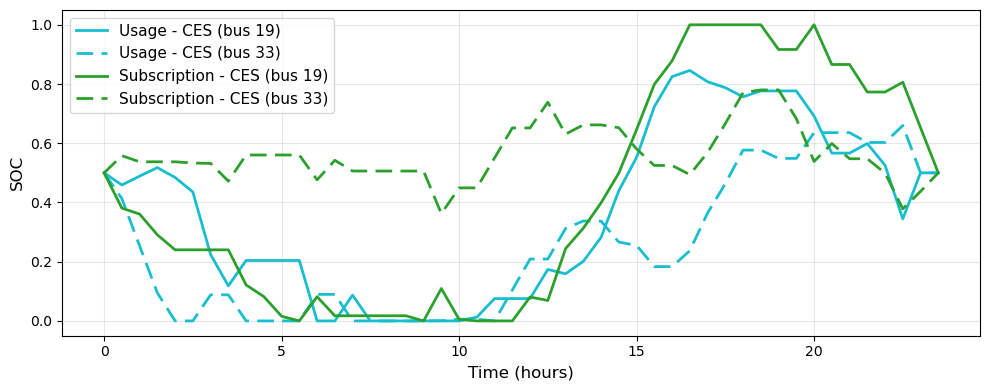

In [5]:
# Basic time axis (half-hour steps 0..47) or convert to hours with /2
t = np.arange(ces_lv_grid_usage.shape[0])         # 0..47
t_hours = t / 2.0                           # optional: convert to hours
colors = ["#7f7f7f", "#17becf", "#2ca02c"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_hours, ces_lv_grid_usage[:, 0] / 283.52, linestyle='-', lw=2, label='Usage - CES (bus 19)', color=colors[1])
ax.plot(t_hours, ces_lv_grid_usage[:, 1] / 275.64, linestyle=(0, (6, 3)), lw=2, label='Usage - CES (bus 33)', color=colors[1])
ax.plot(t_hours, ces_lv_grid_subs[:, 0] / 283.52, linestyle='-', lw=2, label='Subscription - CES (bus 19)', color=colors[2])
ax.plot(t_hours, ces_lv_grid_subs[:, 1] / 275.64, linestyle=(0, (6, 3)), lw=2, label='Subscription - CES (bus 33)', color=colors[2])

ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('SOC', fontsize=12)
# ax.set_title('CES Grid-level Time Series', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)


plt.tight_layout()
plt.savefig('ces_lv_grid_timeseries.svg', dpi=300, bbox_inches='tight')
plt.show()

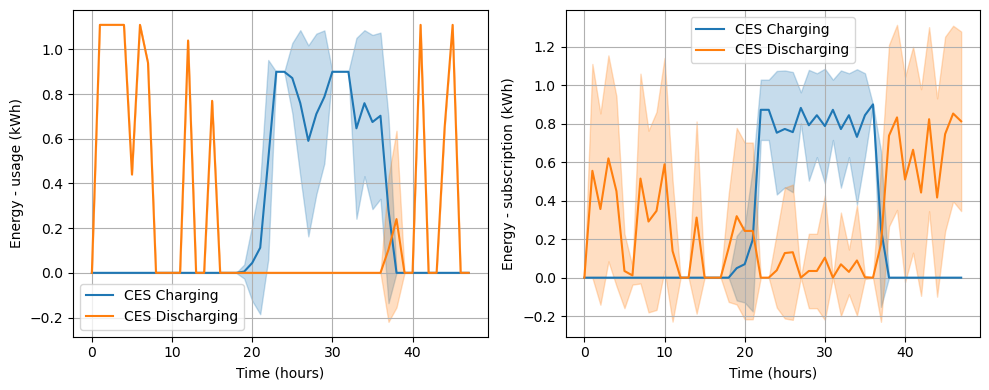

In [6]:
cd_usage = np.asarray(cd_usage, dtype=np.float64)
cd_subs = np.asarray(cd_subs, dtype=np.float64)
charge_usage, discharge_usage = np.clip(cd_usage, 0, None), np.clip(-cd_usage, 0, None)
charge_subs, discharge_subs = np.clip(cd_subs, 0, None), np.clip(-cd_subs, 0, None)

charge_stat_usage = np.mean(charge_usage, axis=1), np.std(charge_usage, axis=1)
discharge_stat_usage = np.mean(discharge_usage, axis=1), np.std(discharge_usage, axis=1)
charge_stat_subs = np.mean(charge_subs, axis=1), np.std(charge_subs, axis=1)
discharge_stat_subs = np.mean(discharge_subs, axis=1), np.std(discharge_subs, axis=1)

t = np.arange(cd_usage.shape[0])  # hours

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Charging
ax[0].plot(t, charge_stat_usage[0], label='CES Charging', color='tab:blue')
ax[0].fill_between(
    t,
    charge_stat_usage[0] - charge_stat_usage[1],
    charge_stat_usage[0] + charge_stat_usage[1],
    color='tab:blue',
    alpha=0.25
)

ax[1].plot(t, charge_stat_subs[0], label='CES Charging', color='tab:blue')
ax[1].fill_between(
    t,
    charge_stat_subs[0] - charge_stat_subs[1],
    charge_stat_subs[0] + charge_stat_subs[1],
    color='tab:blue',
    alpha=0.25
)

# Discharging
ax[0].plot(t, discharge_stat_usage[0], label='CES Discharging', color='tab:orange')
ax[0].fill_between(
    t,
    discharge_stat_usage[0] - discharge_stat_usage[1],
    discharge_stat_usage[0] + discharge_stat_usage[1],
    color='tab:orange',
    alpha=0.25
)

ax[1].plot(t, discharge_stat_subs[0], label='CES Discharging', color='tab:orange')
ax[1].fill_between(
    t,
    discharge_stat_subs[0] - discharge_stat_subs[1],
    discharge_stat_subs[0] + discharge_stat_subs[1],
    color='tab:orange',
    alpha=0.25
)

ax[0].set_xlabel('Time (hours)')
ax[0].set_ylabel('Energy - usage (kWh)')
ax[0].legend()
ax[0].grid(True)

ax[1].set_xlabel('Time (hours)')
ax[1].set_ylabel('Energy - subscription (kWh)')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.savefig('ces_charge_discharge_timeseries.svg', dpi=300, bbox_inches='tight')
plt.show()

<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:1: SyntaxWarning: invalid escape sequence '\J'
C:\Users\PC\AppData\Local\Temp\ipykernel_53708\3854668425.py:1: SyntaxWarning: invalid escape sequence '\J'
  branch_power_loc = "D:\Jacky\MATLAB\Battery_ROI\Result\BranchPowerAll_eco.xlsx"


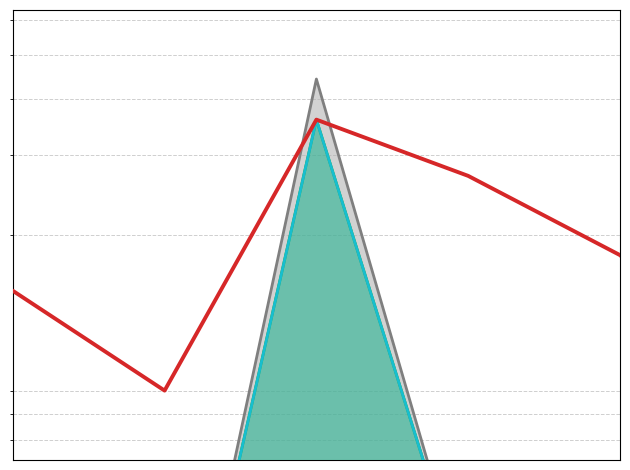

In [8]:
branch_power_loc = "D:\Jacky\MATLAB\Battery_ROI\Result\BranchPowerAll_eco.xlsx"
branch_power = pd.read_excel(branch_power_loc, header=None).to_numpy()
branch_power = branch_power[:, 1:]

category = ['P2P without CES', 'Usage - Based', 'Subscription - Based']

branch_idx = np.arange(1, branch_power.shape[1] + 1)
p_no_ces = branch_power[0, :]
p_usage = branch_power[1, :]
p_subs = branch_power[2, :]
branch_limit = branch_power[3, :]

colors = {
    "no_ces":   "#7f7f7f",  # blue
    "usage":    "#17becf",  # cyan
    "subs":     "#2ca02c",  # green
    "limit":    "#d62728"   # red
}

branch_idx   = np.asarray(branch_idx, dtype=float).ravel()
p_no_ces     = np.asarray(p_no_ces, dtype=float).ravel()
p_usage      = np.asarray(p_usage, dtype=float).ravel()
p_subs       = np.asarray(p_subs, dtype=float).ravel()
branch_limit = np.asarray(branch_limit, dtype=float).ravel()
plt.figure()
# No CES (bottom)
plt.fill_between(branch_idx, p_no_ces,
                 color=colors["no_ces"], alpha=0.35,
                 label=category[0], zorder=1)
plt.plot(branch_idx, p_no_ces,
         color=colors["no_ces"], linewidth=2, zorder=2)

# Usage (TOP)
plt.fill_between(branch_idx, p_usage,
                 color=colors["usage"], alpha=0.35,
                 label=category[1], zorder=5)
plt.plot(branch_idx, p_usage,
         color=colors["usage"], linewidth=2, zorder=6)

# Subscription (middle)
plt.fill_between(branch_idx, p_subs,
                 color=colors["subs"], alpha=0.35,
                 label=category[2], zorder=3)
plt.plot(branch_idx, p_subs,
         color=colors["subs"], linewidth=2, zorder=4)

# Branch limit (VERY TOP)
plt.plot(branch_idx, branch_limit,
         color=colors["limit"], linewidth=2.8,
         label='Branch Limit', zorder=10)
# ----------------------------
# Axis formatting
# ----------------------------
plt.yscale('log')
# plt.xlabel('Branch', fontsize=14)
# plt.ylabel('Log-scaled Power Flow (kW)', fontsize=14)
plt.xticks([])
plt.yticks([])
plt.xlim(left=16,right=20)
plt.ylim(bottom=10**1.8, top=10**2.8)
# plt.title('Power Exchange Profile ', fontsize=14)

plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.6)
# plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig("power_exchange_profile_zoom .svg", dpi=300, bbox_inches='tight')
plt.show()